# 📊 Analyse des Matchs Fixés - Phase de Championnat

Ce notebook permet d'analyser en détail les matchs ayant été effectués lors d'une phase du championnat.
Il utilise les données de la feuille `Matchs_Fixes` du fichier de configuration Excel.

## Structure des données analysées

### Colonnes principales de `Matchs_Fixes`:
- **Equipe_1 / Equipe_2**: Noms des équipes (format: Institution (numéro))
- **Genre**: F (féminin) ou M (masculin)
- **Poule**: Code de la poule du match
- **Semaine**: Numéro de semaine planifiée
- **Date**: Date réelle du match (DD/MM/YY)
- **Horaire**: Heure du match (HH:MM)
- **Gymnase**: Lieu du match
- **Score**: Résultat (format X-Y)
- **Type_Competition**: CFE, CFU, Acad, Autre
- **Remarques**: Annotations (forfait, annulé, entente, etc.)

### Sources de données:
- `Equipes`: Liste des équipes avec leur horaire préféré
- `Types_Poules`: Type de championnat (Classique / Aller-Retour)

## 1. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
import re
from datetime import datetime, timedelta
import warnings

# Configuration de l'affichage
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# ============================================================================
# 📁 CONFIGURATION DE L'EXPORT (MODIFIABLE PAR L'UTILISATEUR)
# ============================================================================

EXPORT_CONFIG = {
    # Dossier principal d'export (modifiez ce nom selon vos besoins)
    'export_folder': 'exports',
    
    # Sous-dossier pour les figures individuelles
    'figures_subfolder': 'figures',
    
    # Préfixe pour les fichiers de rapport PDF
    'pdf_prefix': 'rapport_analyse_matchs',
    
    # Résolution des images (DPI)
    'dpi': 300,
    
    # Inclure un timestamp dans les noms de fichiers PDF
    'include_timestamp': True,
    
    # Format de numérotation des figures
    'number_format': '{:02d}',
}

def get_export_paths():
    """Retourne les chemins d'export basés sur la configuration."""
    export_dir = Path(EXPORT_CONFIG['export_folder'])
    figures_dir = export_dir / EXPORT_CONFIG['figures_subfolder']
    return export_dir, figures_dir

# ============================================================================
# 🎨 SYSTÈME D'EXPORT AUTOMATIQUE DES GRAPHIQUES
# ============================================================================

# Dictionnaire global pour stocker toutes les figures exportées
EXPORTED_FIGURES = {}
_FIGURE_COUNTER = [0]  # Liste pour permettre la modification dans la closure

def auto_save_figure(fig, section_name="graphique"):
    """Sauvegarde automatiquement une figure avec un nom unique."""
    _FIGURE_COUNTER[0] += 1
    counter = _FIGURE_COUNTER[0]
    
    # Créer les dossiers si nécessaires
    _, figures_dir = get_export_paths()
    figures_dir.mkdir(parents=True, exist_ok=True)
    
    # Nettoyer le nom pour en faire un nom de fichier valide
    safe_name = section_name.replace(' ', '_').replace('/', '-').replace(':', '')
    safe_name = ''.join(c for c in safe_name if c.isalnum() or c in '_-')
    
    # Créer le nom du fichier
    number_str = EXPORT_CONFIG['number_format'].format(counter)
    filename = f"{number_str}_{safe_name}"
    filepath = figures_dir / f"{filename}.png"
    
    # Sauvegarder l'image
    fig.savefig(filepath, dpi=EXPORT_CONFIG['dpi'], bbox_inches='tight', facecolor='white')
    
    # Stocker les métadonnées
    EXPORTED_FIGURES[filename] = {
        'path': filepath,
        'section': section_name,
        'number': counter,
        'saved_at': datetime.now().isoformat()
    }
    
    return filepath

def smart_show(section_name="graphique"):
    """Affiche le graphique ET le sauvegarde automatiquement."""
    fig_nums = plt.get_fignums()
    
    if not fig_nums:
        plt.show()
        return
    
    for i, num in enumerate(fig_nums):
        fig = plt.figure(num)
        name = section_name if len(fig_nums) == 1 else f"{section_name}_part{i+1}"
        path = auto_save_figure(fig, name)
        print(f"   💾 Sauvegardé: {path.name}")
    
    plt.show()

def reset_export_counter():
    """Réinitialise le compteur de figures."""
    global EXPORTED_FIGURES
    _FIGURE_COUNTER[0] = 0
    EXPORTED_FIGURES = {}
    print("🔄 Compteur d'export réinitialisé")


def save_individual_subplots(fig, axes, base_name, titles=None):
    """
    Sauvegarde chaque sous-graphique d'une figure comme fichier PNG individuel.
    
    Args:
        fig: Figure matplotlib contenant les sous-graphiques
        axes: Array d'axes (peut être 1D ou 2D)
        base_name: Nom de base pour les fichiers (ex: "Forfaits")
        titles: Liste de titres pour chaque sous-graphique (optionnel)
    
    Returns:
        Liste des chemins de fichiers créés
    """
    import numpy as np
    from matplotlib.transforms import Bbox
    
    # Aplatir les axes si nécessaire
    if hasattr(axes, 'flatten'):
        axes_flat = axes.flatten()
    elif hasattr(axes, '__iter__'):
        axes_flat = list(axes)
    else:
        axes_flat = [axes]
    
    saved_files = []
    
    for i, ax in enumerate(axes_flat):
        # Ignorer les axes vides ou invisibles
        if not ax.get_visible():
            continue
        
        # Déterminer le titre
        if titles and i < len(titles):
            subplot_name = titles[i]
        elif ax.get_title():
            subplot_name = ax.get_title()
        else:
            subplot_name = f"subplot_{i+1}"
        
        # Nettoyer le nom
        safe_subplot_name = subplot_name.replace(' ', '_').replace('/', '-').replace(':', '').replace('(', '').replace(')', '')
        safe_subplot_name = ''.join(c for c in safe_subplot_name if c.isalnum() or c in '_-')
        
        full_name = f"{base_name}_{safe_subplot_name}"
        
        # Créer une nouvelle figure pour ce sous-graphique
        new_fig = plt.figure(figsize=(10, 7))
        new_ax = new_fig.add_subplot(111)
        
        # Copier le contenu de l'axe original
        # On utilise une approche différente: sauvegarder l'extent de l'axe
        extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
        
        # Sauvegarder directement cette partie de la figure originale
        _FIGURE_COUNTER[0] += 1
        counter = _FIGURE_COUNTER[0]
        
        _, figures_dir = get_export_paths()
        figures_dir.mkdir(parents=True, exist_ok=True)
        
        number_str = EXPORT_CONFIG['number_format'].format(counter)
        filename = f"{number_str}_{full_name}"
        filepath = figures_dir / f"{filename}.png"
        
        # Élargir légèrement la bounding box pour inclure les labels
        extent_expanded = extent.expanded(1.3, 1.3)
        
        fig.savefig(filepath, dpi=EXPORT_CONFIG['dpi'], bbox_inches=extent_expanded, 
                   facecolor='white', edgecolor='none')
        
        EXPORTED_FIGURES[filename] = {
            'path': filepath,
            'section': full_name,
            'number': counter,
            'saved_at': datetime.now().isoformat()
        }
        
        saved_files.append(filepath)
        print(f"   💾 Sauvegardé: {filename}.png")
        
        plt.close(new_fig)
    
    return saved_files


def smart_show_individual(base_name="graphique"):
    """
    Affiche les graphiques ET sauvegarde chaque sous-graphique individuellement.
    
    Pour les figures avec plusieurs sous-graphiques (subplots), chaque graphique
    est sauvegardé dans un fichier séparé.
    """
    fig_nums = plt.get_fignums()
    
    if not fig_nums:
        plt.show()
        return
    
    for num in fig_nums:
        fig = plt.figure(num)
        axes = fig.get_axes()
        
        if len(axes) == 1:
            # Un seul graphique - sauvegarde normale
            path = auto_save_figure(fig, base_name)
            print(f"   💾 Sauvegardé: {path.name}")
        else:
            # Plusieurs sous-graphiques - sauvegarde individuelle
            save_individual_subplots(fig, axes, base_name)
    
    plt.show()


# ============================================================================
# CONFIGURATION GRAPHIQUE COHÉRENTE
# ============================================================================

# Style de base
plt.style.use('seaborn-v0_8-whitegrid')

# Palette de couleurs cohérente pour tout le notebook
COLORS = {
    # Couleurs des statuts
    'joué': '#27ae60',
    'forfait': '#c0392b',
    'annulé': '#7f8c8d',
    'reporté': '#d35400',
    'entente': '#2980b9',
    'score_manquant': '#8e44ad',
    'planifié': '#16a085',
    
    # Couleurs générales
    'primary': '#2c3e50',
    'secondary': '#34495e',
    'accent': '#3498db',
    'success': '#27ae60',
    'warning': '#f39c12',
    'danger': '#e74c3c',
    'info': '#17a2b8',
    
    # Couleurs genres
    'Féminin': '#e91e63',
    'Masculin': '#2196f3',
}

# Palette pour les graphiques multi-catégories
PALETTE_MAIN = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']

# Horaires standards autorisés (définis ici pour être accessibles partout)
HORAIRES_STANDARDS = [14, 16, 18, 20]  # heures

# Paramètres de figure par défaut
plt.rcParams.update({
    'figure.figsize': [14, 7],
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.2,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'medium',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#cccccc',
    'font.family': 'sans-serif',
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

# Fonctions utilitaires pour les graphiques
def style_axis(ax, xlabel=None, ylabel=None, title=None, integer_y=False, integer_x=False):
    """Applique un style cohérent à un axe."""
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=12, fontweight='medium')
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12, fontweight='medium')
    
    # Forcer les entiers sur les axes si demandé
    if integer_y:
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    if integer_x:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    ax.tick_params(axis='both', which='major', labelsize=10)
    return ax


def _safe_format_value(value, fmt):
    """Formate une valeur même si le formatage personnalisé échoue."""
    try:
        return fmt.format(value)
    except (ValueError, TypeError):
        try:
            return f"{value}"
        except Exception:
            return str(value)


def add_value_labels_generic(ax, bars, orientation='vertical', fmt='{:.0f}', offset=0.5, fontsize=9, fontweight='bold'):
    """Ajoute des labels de valeur avec une gestion robuste du formatage."""
    orientation = orientation.lower()
    if orientation not in {'vertical', 'horizontal'}:
        raise ValueError("orientation doit être 'vertical' ou 'horizontal'")
    
    for bar in bars:
        if orientation == 'vertical':
            value = bar.get_height()
            if value and value > 0:
                label = _safe_format_value(value, fmt)
                ax.annotate(label,
                            xy=(bar.get_x() + bar.get_width() / 2, value),
                            xytext=(0, offset * 10),
                            textcoords="offset points",
                            ha='center', va='bottom',
                            fontsize=fontsize, fontweight=fontweight)
        else:
            value = bar.get_width()
            if value and value > 0:
                label = _safe_format_value(value, fmt)
                ax.annotate(label,
                            xy=(value, bar.get_y() + bar.get_height() / 2),
                            xytext=(offset * 15, 0),
                            textcoords="offset points",
                            ha='left', va='center',
                            fontsize=fontsize, fontweight=fontweight)


def add_value_labels(ax, bars, fmt='{:.0f}', offset=0.5, fontsize=9, fontweight='bold'):
    """Ajoute des labels de valeur sur les barres verticales."""
    add_value_labels_generic(ax, bars, orientation='vertical', fmt=fmt, offset=offset, fontsize=fontsize, fontweight=fontweight)


def add_value_labels_h(ax, bars, fmt='{:.0f}', offset=0.3, fontsize=9, fontweight='bold'):
    """Ajoute des labels de valeur sur les barres horizontales."""
    add_value_labels_generic(ax, bars, orientation='horizontal', fmt=fmt, offset=offset, fontsize=fontsize, fontweight=fontweight)


def get_equipe_key(equipe, genre=None):
    """
    Crée une clé unique pour une équipe incluant le genre.
    Utilisé pour les statistiques par équipe.
    """
    if pd.isna(equipe) or str(equipe).strip() == '':
        return None
    
    equipe_str = str(equipe).strip()
    
    # Ajouter le genre si présent
    if genre and pd.notna(genre):
        genre_str = str(genre).strip().upper()
        if genre_str in ['F', 'M', 'FEMININ', 'MASCULIN']:
            genre_char = genre_str[0]
            return f"{equipe_str} [{genre_char}]"
    
    return equipe_str


print("✅ Bibliothèques et système d'export importés avec succès")
print(f"   📁 Dossier d'export: {EXPORT_CONFIG['export_folder']}/{EXPORT_CONFIG['figures_subfolder']}/")
print(f"   🎨 Horaires standards: {HORAIRES_STANDARDS}")
print(f"   💡 Utilisez smart_show('nom_graphique') pour sauvegarder automatiquement")

✅ Bibliothèques et système d'export importés avec succès
   📁 Dossier d'export: exports/figures/
   🎨 Horaires standards: [14, 16, 18, 20]
   💡 Utilisez smart_show('nom_graphique') pour sauvegarder automatiquement


## 2. Chargement et exploration des données

Chargement du fichier de configuration Excel et des différentes feuilles nécessaires à l'analyse.

In [2]:
# ============================================================================
# CONFIGURATION - Modifier le chemin du fichier Excel ici
# ============================================================================
CONFIG_FILE = "data/volleyball/config_volley.xlsx"
# ============================================================================

# Résolution du chemin
project_root = Path.cwd()
config_path = project_root / CONFIG_FILE

print(f"📂 Fichier de configuration: {config_path}")
print(f"   Existe: {'✅' if config_path.exists() else '❌'}")

# Chargement des feuilles
try:
    # Feuille principale: Matchs Fixés
    df_matchs_fixes = pd.read_excel(config_path, sheet_name='Matchs_Fixes')
    df_matchs_fixes['Source'] = 'Fixé'
    print(f"\n📋 Matchs_Fixes: {len(df_matchs_fixes)} lignes, {len(df_matchs_fixes.columns)} colonnes")
    
    # Feuille Matchs Annulés (pour analyse qualitative uniquement)
    try:
        df_matchs_annules = pd.read_excel(config_path, sheet_name='Matchs_Annules')
        print(f"📋 Matchs_Annules: {len(df_matchs_annules)} lignes (analyse qualitative uniquement)")
    except:
        df_matchs_annules = pd.DataFrame()
        print("⚠️ Matchs_Annules non trouvée ou vide")
    
    # IMPORTANT: On ne fusionne PAS les matchs annulés avec les matchs fixés
    # Les matchs fixés sont la seule source pour les statistiques
    # Les matchs annulés servent uniquement à comprendre les raisons d'annulation
    df_matchs = df_matchs_fixes.copy()  # Uniquement les matchs fixés
    
    print(f"\n📊 MATCHS POUR STATISTIQUES: {len(df_matchs)} matchs (depuis Matchs_Fixes)")
    print(f"\n📝 MATCHS POUR ANALYSE QUALITATIVE: {len(df_matchs_annules)} matchs annulés")
    print(f"   ⚠️ Les matchs annulés ne sont PAS comptés dans les statistiques")
    
    # Feuille Équipes (championnat académique)
    df_equipes = pd.read_excel(config_path, sheet_name='Equipes')
    print(f"\n📋 Equipes: {len(df_equipes)} lignes")
    
    # Feuille Types_Poules (pour identifier Aller-Retour)
    try:
        df_types_poules = pd.read_excel(config_path, sheet_name='Types_Poules')
        print(f"📋 Types_Poules: {len(df_types_poules)} lignes")
    except:
        df_types_poules = pd.DataFrame()
        print("⚠️ Types_Poules non trouvée")
    
    # Vérification de la nouvelle colonne Arbitres
    if 'Arbitres' in df_matchs.columns:
        nb_avec_arbitre = df_matchs['Arbitres'].notna().sum()
        print(f"\n📋 Arbitres: {nb_avec_arbitre}/{len(df_matchs)} matchs ont un arbitre assigné")
    else:
        print("\n⚠️ Colonne Arbitres non présente")
    
    print("\n✅ Données chargées avec succès!")
    
except FileNotFoundError:
    print(f"❌ Fichier non trouvé: {config_path}")
    print("   Vérifiez le chemin CONFIG_FILE en haut de cette cellule")
except Exception as e:
    print(f"❌ Erreur: {e}")

📂 Fichier de configuration: /home/vincheetah/Documents/Travail/FFSU/PyCalendarClean/PyCalendar/data/volleyball/config_volley.xlsx
   Existe: ✅

📋 Matchs_Fixes: 261 lignes, 13 colonnes
📋 Matchs_Annules: 25 lignes (analyse qualitative uniquement)

📊 MATCHS POUR STATISTIQUES: 261 matchs (depuis Matchs_Fixes)

📝 MATCHS POUR ANALYSE QUALITATIVE: 25 matchs annulés
   ⚠️ Les matchs annulés ne sont PAS comptés dans les statistiques

📋 Equipes: 126 lignes

📋 Matchs_Fixes: 261 lignes, 13 colonnes
📋 Matchs_Annules: 25 lignes (analyse qualitative uniquement)

📊 MATCHS POUR STATISTIQUES: 261 matchs (depuis Matchs_Fixes)

📝 MATCHS POUR ANALYSE QUALITATIVE: 25 matchs annulés
   ⚠️ Les matchs annulés ne sont PAS comptés dans les statistiques

📋 Equipes: 126 lignes
📋 Types_Poules: 30 lignes

📋 Arbitres: 215/261 matchs ont un arbitre assigné

✅ Données chargées avec succès!
📋 Types_Poules: 30 lignes

📋 Arbitres: 215/261 matchs ont un arbitre assigné

✅ Données chargées avec succès!


In [3]:
# Exploration de la structure des données
print("=" * 70)
print("📊 STRUCTURE DES DONNÉES - MATCHS FIXÉS")
print("=" * 70)

print("\n📌 Colonnes disponibles:")
for i, col in enumerate(df_matchs.columns, 1):
    dtype = df_matchs[col].dtype
    non_null = df_matchs[col].notna().sum()
    pct_filled = (non_null / len(df_matchs)) * 100 if len(df_matchs) > 0 else 0
    print(f"   {i:2d}. {col:<20} | Type: {str(dtype):<10} | Rempli: {pct_filled:5.1f}% ({non_null}/{len(df_matchs)})")

# Résumé des types de compétition
print("\n🏆 RÉPARTITION PAR TYPE DE COMPÉTITION:")
type_counts = df_matchs['Type_Competition'].value_counts(dropna=False)
for type_comp, count in type_counts.items():
    pct = (count / len(df_matchs)) * 100
    print(f"   • {type_comp if pd.notna(type_comp) else 'Non spécifié'}: {count} ({pct:.1f}%)")

# Aperçu des matchs annulés (analyse qualitative séparée)
if len(df_matchs_annules) > 0:
    print(f"\n📝 MATCHS ANNULÉS ({len(df_matchs_annules)} matchs - analyse qualitative):")
    print("   ⚠️ Ces matchs ne sont PAS inclus dans les statistiques ci-dessous")
    cols_annules = ['Equipe_1', 'Equipe_2', 'Genre', 'Poule', 'Remarques']
    cols_available = [c for c in cols_annules if c in df_matchs_annules.columns]
    if cols_available:
        display(df_matchs_annules[cols_available].head(5))
else:
    print("\n✅ Aucun match annulé dans la feuille Matchs_Annules")

print("\n📋 Aperçu des premières lignes (matchs fixés uniquement):")
display(df_matchs.head(10))

📊 STRUCTURE DES DONNÉES - MATCHS FIXÉS

📌 Colonnes disponibles:
    1. Equipe_1             | Type: object     | Rempli: 100.0% (261/261)
    2. Equipe_2             | Type: object     | Rempli: 100.0% (261/261)
    3. Genre                | Type: object     | Rempli: 100.0% (261/261)
    4. Poule                | Type: object     | Rempli:  89.3% (233/261)
    5. Semaine              | Type: int64      | Rempli: 100.0% (261/261)
    6. Date                 | Type: object     | Rempli: 100.0% (261/261)
    7. Horaire              | Type: object     | Rempli:  93.1% (243/261)
    8. Gymnase              | Type: object     | Rempli: 100.0% (261/261)
    9. Score                | Type: object     | Rempli:  85.8% (224/261)
   10. Type_Competition     | Type: object     | Rempli: 100.0% (261/261)
   11. Remarques            | Type: object     | Rempli:  99.6% (260/261)
   12. Arbitres             | Type: object     | Rempli:  82.4% (215/261)
   13. Source               | Type: object     |

,Equipe_1,Equipe_2,Genre,Poule,Remarques
0,SANTE (1),LYON 2 (IEP) (4),F,VBFA2PB,Erreur programmation | Importé J1 | J1.xlsx
1,ENTPE (2),LYON 1 (8),F,VBFA3PA,MATCH ANNULE le 15/10 le 11h02 | Importé J1 |...
2,ENTPE (2),ENS (2),F,VBFA3PA,MATCH annule le 15/10 à 20H | Importé J1 | J1....
3,ESSCA (1),LYON 2 (8),F,VBFA4PB,MATCH ANNULE le 15/10 à 14h03 | Importé J1 | J...
4,INSA (1),LYON 1 (2),M,VBMA1PA,MATCH ANNULE le 16 oct à 11H | Importé J1 | J1...



📋 Aperçu des premières lignes (matchs fixés uniquement):


,Equipe_1,Equipe_2,Genre,Poule,Semaine,Date,Horaire,Gymnase,Score,Type_Competition,Remarques,Arbitres,Source
0,LYON 2 (1),LYON 3 (1),F,VBFA1PB,14,12/01/26,18:20,LAENNEC,NaN,Acad,NaN,NaN,Fixé
1,INSA (1),LYON 1 (11),F,VBFA1PA,1,16/10/25,16:00,BESSON,3-0,Acad,Importé J1 | J1.xlsx,SION,Fixé
2,EML (1),LYON 3 (1),F,VBFA1PB,1,16/10/25,20:00,LAENNEC,1-3,Acad,CHANGEMENT HORAIRE modif le 13/10 à 15h57 | Im...,NaN,Fixé
3,LYON 1 (4),INSA (3),F,VBFA2PA,1,16/10/25,18:00,BESSON,3-0,Acad,Importé J1 | J1.xlsx,MOMO,Fixé
4,LYON 1 (2),ENS (1),F,VBFA2PB,1,16/10/25,18:00,BESSON,3-1,Acad,CHANGEMENT LIEU modif le 14/10 à 9h27 | Import...,PIERARD,Fixé
5,LYON 1 (9),ECAM (1),F,VBFA3PA,1,16/10/25,16:00,LAENNEC,0-3,Acad,Importé J1 | J1.xlsx,GOUBET,Fixé
6,LYON 2 (5),LYON 2 (6),F,VBFA3PA,1,16/10/25,18:00,LYON 2 HC,0-3,Acad,Importé J1 | J1.xlsx,FEUGAS,Fixé
7,SANTE (4),LYON 1 (6),F,VBFA3PB,1,16/10/25,20:00,BESSON,3-0,Acad,Importé J1 | J1.xlsx,MOMO,Fixé
8,CATHO (1),LYON 2 (7),F,VBFA3PC,1,16/10/25,20:00,LYON 2 HC,2-3,Acad,Importé J1 | J1.xlsx,FEUGAS,Fixé
9,ECL (2),LYON 1 (12),F,VBFA4PA,1,16/10/25,14:00,ECL,1-3,Acad,Importé J1 | J1.xlsx,LE GALL,Fixé


## 📋 Méthodologie de classification des matchs

Cette section explique les critères utilisés pour classifier chaque match dans une catégorie spécifique.

---

### 📁 **Sources des données**

Les matchs proviennent de **deux feuilles distinctes** :

| Source | Description | Utilisation |
|--------|-------------|-------------|
| **Matchs_Fixes** | Matchs planifiés, joués ou à jouer | ✅ **Toutes les statistiques** (scores, forfaits, ententes, etc.) |
| **Matchs_Annules** | Matchs définitivement annulés | 📝 **Analyse qualitative uniquement** (raisons d'annulation) |

⚠️ **IMPORTANT** : Les matchs de la feuille `Matchs_Annules` ne sont **PAS comptés** dans les statistiques de la phase. Ils sont analysés séparément pour comprendre les raisons des annulations.

---

### 🏐 **Statuts des matchs (Matchs_Fixes)**

| Statut | Critères de détection | Description |
|--------|----------------------|-------------|
| **✅ Joué** | Score valide (format X-Y avec X ou Y = 3) | Match disputé normalement |
| **🚫 Forfait** | Mot "FORFAIT" dans remarques **OU** score atypique (0-1, 1-0, 2-1, 1-2) | Une équipe absente ou n'a pas pu jouer |
| **❌ Annulé** | Mot "annulé" ou "cancel" dans remarques | Match définitivement annulé |
| **📅 Reporté** | Mot "reporté" dans remarques | Match reprogrammé à une autre date |
| **🤝 Entente** | Gymnase = "ENTENTE" **OU** jour ≠ jeudi **OU** mot "entente" dans remarques | Match hors calendrier standard |
| **❓ Score manquant** | Aucun score enregistré, pas d'autre statut détecté | Match planifié mais résultat non renseigné |

---

### 🤝 **Détection des ententes (IMPORTANT)**

Les matchs sont considérés comme des **ententes** si l'une des conditions suivantes est vraie :

1. **Gymnase = "ENTENTE"** : Match sans lieu/horaire précis, à organiser par les équipes
2. **Jour ≠ Jeudi** : Tout match programmé un lundi, mardi, mercredi, vendredi, samedi ou dimanche est considéré comme une entente (car le calendrier officiel ne prévoit des matchs que le jeudi, à partir du 16/10/25)
3. **Mot "entente" dans remarques** : Indication explicite

*Les matchs en entente représentent des arrangements particuliers entre équipes, en dehors du calendrier standard du jeudi.*

---

### 🎯 **Détection des forfaits**

Les forfaits sont identifiés de **deux manières** :

1. **Via les remarques** : Recherche du mot "FORFAIT" (insensible à la casse)
2. **Via les scores atypiques** : En volleyball, les scores normaux sont 3-0, 3-1, 3-2, 0-3, 1-3, 2-3. Les scores suivants indiquent probablement un forfait :
   - `0-1` ou `1-0` : Forfait avec 1 set joué
   - `2-1` ou `1-2` : Score invalide en volley (pas de vainqueur à 3 sets)

---

### ⏰ **Normalisation des horaires**

Les horaires sont normalisés vers le **créneau standard le plus proche** parmi :
- **14h** (14:00)
- **16h** (16:00)
- **18h** (18:00)
- **20h** (20:00)

**Règle de normalisation** : Arrondi vers le créneau le plus proche. Si l'horaire est exactement au milieu de deux créneaux (15h, 17h, 19h), on prend le créneau supérieur.

---

### 🏆 **Normalisation des scores**

Les scores sont normalisés pour être **indépendants de l'ordre** :
- Un score `3-1` est comptabilisé de la même façon qu'un `1-3`
- Format normalisé : (score_max, score_min), donc toujours `3-1`, `3-0`, ou `3-2`

---

### 👨‍⚖️ **Analyse des arbitres**

La colonne `Arbitres` permet de suivre :
- Le **taux de couverture** : pourcentage de matchs avec un arbitre désigné
- La **charge par arbitre** : nombre de matchs arbitrés par personne
- L'**équilibre** de la répartition des matchs entre arbitres

---

### 📊 **Statistiques des équipes**

Les statistiques par équipe sont calculées sur **TOUS les matchs** de l'équipe, pas seulement ceux avec un score. Cela inclut :
- Matchs joués (avec score)
- Matchs à jouer (sans score)
- Forfaits et annulations
- Ententes

---

### 🔄 **Matchs Aller-Retour**

Identifiés via la feuille `Types_Poules` :
- Les poules de type "Aller-Retour" ont chaque paire d'équipes qui se rencontre **deux fois**
- L'écart entre les deux rencontres est analysé

## 3. Préparation et nettoyage des données

Création de fonctions d'analyse pour extraire le sens des données et classifier les matchs.

In [4]:
# ============================================================================
# FONCTIONS D'ANALYSE DES REMARQUES ET STATUTS
# ============================================================================

# Horaires standards autorisés
HORAIRES_STANDARDS = [14, 16, 18, 20]  # heures

def normaliser_horaire(horaire_minutes):
    """
    Normalise un horaire vers l'horaire standard le plus proche.
    Les horaires standards sont: 14h, 16h, 18h, 20h.
    Si l'horaire est exactement au milieu de deux standards, prend le supérieur.
    
    Ex: 14h30 -> 14h (plus proche de 14h que de 16h)
        15h00 -> 16h (exactement au milieu -> supérieur)
        17h00 -> 18h (exactement au milieu -> supérieur)
        17h30 -> 18h (plus proche de 18h)
        19h30 -> 20h (plus proche de 20h)
    """
    if pd.isna(horaire_minutes):
        return None
    
    heure = horaire_minutes / 60
    
    # Trouver l'horaire standard le plus proche
    best_horaire = HORAIRES_STANDARDS[0]
    best_distance = abs(heure - best_horaire)
    
    for h_std in HORAIRES_STANDARDS:
        distance = abs(heure - h_std)
        # Si distance égale, on garde le supérieur (ne pas mettre à jour)
        if distance < best_distance:
            best_horaire = h_std
            best_distance = distance
    
    # Cas spécial : exactement au milieu -> prendre le supérieur
    # Les milieux sont 15h, 17h, 19h
    milieux = [15, 17, 19]
    if heure in milieux:
        idx = milieux.index(heure)
        best_horaire = HORAIRES_STANDARDS[idx + 1]  # 15->16, 17->18, 19->20
    
    return best_horaire * 60  # Retourne en minutes


def analyser_remarques(remarques):
    """
    Analyse le champ Remarques pour extraire des indicateurs.
    
    Retourne un dictionnaire avec les flags détectés.
    """
    if pd.isna(remarques) or str(remarques).strip() == '':
        return {
            'forfait': False,
            'annule': False,
            'entente': False,
            'reporte': False,
            'compte_double': False,
            'importé': False,
            'changement_horaire': False,
            'changement_lieu': False,
            'changement_poule': False,
            'match_rajoute': False,
            'finale': False,
            'a_faire': False,
            'remarque_text': ''
        }
    
    text = str(remarques).lower().strip()
    
    return {
        'forfait': bool(re.search(r'forfait', text)),
        'annule': bool(re.search(r'annul[eé]|cancel', text)),
        'entente': bool(re.search(r'entente', text)),
        'reporte': bool(re.search(r'report[eé]', text)),
        'compte_double': bool(re.search(r'compte\s*double|double\s*comptage', text)),
        'importé': bool(re.search(r'import[eé]|J\d+', text)),
        'changement_horaire': bool(re.search(r'changement\s*(horaire|heure)', text)),
        'changement_lieu': bool(re.search(r'changement\s*lieu|lieu\s*modifi', text)),
        'changement_poule': bool(re.search(r'changement\s*(de\s*)?poule|ancienne\s*poule', text)),
        'match_rajoute': bool(re.search(r'match\s*rajout[eé]', text)),
        'finale': bool(re.search(r'finale|1/2\s*finale|petite\s*finale', text)),
        'a_faire': bool(re.search(r'a\s*faire\s*avant', text)),
        'remarque_text': str(remarques).strip()
    }


def is_score_forfait(score):
    """
    Détecte si un score indique un forfait.
    En volley, les scores normaux sont 3-0, 3-1, 3-2, 0-3, 1-3, 2-3.
    Les scores comme 0-1, 1-0, 2-1, 1-2 sont atypiques et indiquent souvent un forfait.
    """
    if pd.isna(score) or str(score).strip() == '':
        return False
    
    score_str = str(score).strip().lower()
    
    # Forfait explicite dans le texte
    if 'forfait' in score_str or score_str in ['ff', 'f', 'forfait']:
        return True
    
    # Scores atypiques en volley (0-1, 1-0, 2-1, 1-2)
    atypiques = ['0-1', '1-0', '2-1', '1-2', '0 - 1', '1 - 0', '2 - 1', '1 - 2']
    if score_str in atypiques:
        return True
    
    return False


def is_jour_entente(date_val):
    """
    Détecte si une date correspond à un jour d'entente (= pas un jeudi).
    Les matchs qui n'ont pas lieu le jeudi sont considérés comme des ententes.
    """
    if pd.isna(date_val):
        return False
    
    try:
        # Le jeudi = 3 en Python (lundi=0, mardi=1, mercredi=2, jeudi=3, etc.)
        return date_val.dayofweek != 3
    except:
        return False


def is_match_entente(row, date_parsed=None):
    """
    Détecte si un match est en entente.
    Critères:
    - Gymnase = "ENTENTE"
    - OU jour différent du jeudi (jour habituel des matchs)
    """
    gymnase = row.get('Gymnase', '')
    if pd.notna(gymnase) and str(gymnase).strip().upper() == 'ENTENTE':
        return True
    
    # Vérifier si le match n'est pas un jeudi
    if date_parsed is not None:
        return is_jour_entente(date_parsed)
    
    return False


def classifier_match(row, date_parsed=None):
    """
    Classifie un match selon son statut.
    
    Statuts possibles:
    - 'joué': Match avec score valide
    - 'forfait': Match forfait (une équipe absente)
    - 'annulé': Match annulé
    - 'reporté': Match reporté à une autre date
    - 'entente': Match en entente (à organiser entre équipes OU pas un jeudi)
    - 'score_manquant': Match planifié mais sans score
    - 'planifié': Match planifié (futur ou en attente)
    """
    remarques_info = analyser_remarques(row.get('Remarques', ''))
    score = row.get('Score', '')
    has_score = pd.notna(score) and str(score).strip() != ''
    
    # Priorité des statuts
    if remarques_info['annule']:
        return 'annulé'
    
    # Forfait détecté via remarques OU via score atypique
    if remarques_info['forfait'] or is_score_forfait(score):
        return 'forfait'
    
    if remarques_info['reporte']:
        return 'reporté'
    
    # Entente détectée via remarques OU via gymnase ENTENTE OU via jour non-jeudi
    if remarques_info['entente'] or is_match_entente(row, date_parsed):
        if has_score:
            return 'joué'  # Entente jouée
        return 'entente'
    
    if has_score:
        return 'joué'
    
    # Pas de score et pas de statut spécial
    return 'score_manquant'


def parser_score(score):
    """
    Parse un score et retourne (score_eq1, score_eq2) ou (None, None).
    """
    if pd.isna(score) or str(score).strip() == '':
        return None, None
    
    score_str = str(score).strip()
    
    # Formats: "3-1", "3 - 1", "3/1"
    match = re.match(r'^(\d+)\s*[-/]\s*(\d+)', score_str)
    if match:
        return int(match.group(1)), int(match.group(2))
    
    return None, None


def normaliser_score(s1, s2):
    """
    Normalise un score pour qu'il soit indépendant de l'ordre (gagnant-perdant).
    Retourne toujours le score dans l'ordre (max, min).
    """
    if s1 is None or s2 is None:
        return None, None
    return max(s1, s2), min(s1, s2)


def parser_horaire(horaire):
    """
    Parse un horaire en minutes depuis minuit.
    """
    if pd.isna(horaire):
        return None
    
    horaire_str = str(horaire).strip()
    
    # Format HH:MM ou HH:MM:SS
    match = re.match(r'^(\d{1,2}):(\d{2})', horaire_str)
    if match:
        return int(match.group(1)) * 60 + int(match.group(2))
    
    # Format décimal (ex: 0.75 pour 18:00)
    try:
        val = float(horaire_str)
        if 0 <= val <= 1:
            total_minutes = int(val * 24 * 60)
            return total_minutes
    except:
        pass
    
    return None


def minutes_to_time_str(minutes):
    """Convertit des minutes en chaîne HH:MM."""
    if pd.isna(minutes):
        return None
    h = int(minutes) // 60
    m = int(minutes) % 60
    return f"{h:02d}:{m:02d}"


print("✅ Fonctions d'analyse définies")
print("   • Détection ententes: gymnase 'ENTENTE' OU matchs non-jeudi")
print("   • Normalisation horaires: vers 14h, 16h, 18h ou 20h (le plus proche, supérieur si milieu)")
print("   • Normalisation scores: indépendant de l'ordre (gagnant-perdant)")

✅ Fonctions d'analyse définies
   • Détection ententes: gymnase 'ENTENTE' OU matchs non-jeudi
   • Normalisation horaires: vers 14h, 16h, 18h ou 20h (le plus proche, supérieur si milieu)
   • Normalisation scores: indépendant de l'ordre (gagnant-perdant)


In [5]:
# ============================================================================
# APPLICATION DES CLASSIFICATIONS
# ============================================================================

# Copie de travail avec enrichissement (uniquement matchs fixés)
df = df_matchs.copy()

# Parse des dates et identification des jours
df['Date_parsed'] = pd.to_datetime(df['Date'], format='%d/%m/%y', errors='coerce')
df['jour_semaine'] = df['Date_parsed'].dt.dayofweek  # 0=Lundi, 3=Jeudi, 4=Vendredi...
df['jour_nom'] = df['Date_parsed'].dt.day_name()
df['is_jeudi'] = df['jour_semaine'] == 3

# Détection des ententes par gymnase
df['is_gymnase_entente'] = df['Gymnase'].astype(str).str.upper().str.strip() == 'ENTENTE'

# === NOUVELLE RÈGLE: Les matchs non-jeudi sont des ententes ===
df['is_jour_entente'] = (df['jour_semaine'].notna()) & (df['jour_semaine'] != 3)
df['is_entente_auto'] = df['is_gymnase_entente'] | df['is_jour_entente']

# Classification de chaque match (uniquement matchs fixés)
df['statut'] = df.apply(lambda row: classifier_match(row, row['Date_parsed']), axis=1)

# Extraction des infos de remarques
remarques_analysis = df['Remarques'].apply(analyser_remarques)
df['is_forfait_remarques'] = remarques_analysis.apply(lambda x: x['forfait'])
df['is_forfait_score'] = df['Score'].apply(is_score_forfait)
df['is_forfait'] = df['is_forfait_remarques'] | df['is_forfait_score']
df['is_annule'] = remarques_analysis.apply(lambda x: x['annule'])  # Annulé via remarques dans Matchs_Fixes
df['is_entente'] = remarques_analysis.apply(lambda x: x['entente']) | df['is_entente_auto']
df['is_reporte'] = remarques_analysis.apply(lambda x: x['reporte'])
df['is_compte_double'] = remarques_analysis.apply(lambda x: x['compte_double'])

# Nouveaux flags pour analyse des remarques
df['is_changement_horaire'] = remarques_analysis.apply(lambda x: x['changement_horaire'])
df['is_changement_lieu'] = remarques_analysis.apply(lambda x: x['changement_lieu'])
df['is_changement_poule'] = remarques_analysis.apply(lambda x: x['changement_poule'])
df['is_match_rajoute'] = remarques_analysis.apply(lambda x: x['match_rajoute'])
df['is_finale'] = remarques_analysis.apply(lambda x: x['finale'])
df['is_a_faire'] = remarques_analysis.apply(lambda x: x['a_faire'])

# Parse des scores
scores_parsed = df['Score'].apply(parser_score)
df['score_eq1'] = scores_parsed.apply(lambda x: x[0])
df['score_eq2'] = scores_parsed.apply(lambda x: x[1])
df['has_score'] = df['score_eq1'].notna()

# Scores normalisés (indépendants de l'ordre: gagnant-perdant)
scores_normalises = df.apply(lambda r: normaliser_score(r['score_eq1'], r['score_eq2']), axis=1)
df['score_gagnant'] = scores_normalises.apply(lambda x: x[0])
df['score_perdant'] = scores_normalises.apply(lambda x: x[1])
df['score_normalise'] = df.apply(
    lambda r: f"{int(r['score_gagnant'])}-{int(r['score_perdant'])}" 
    if pd.notna(r['score_gagnant']) else None, axis=1
)

# Parse des horaires
df['horaire_minutes'] = df['Horaire'].apply(parser_horaire)

# === NORMALISATION DES HORAIRES vers 14h, 16h, 18h ou 20h ===
df['horaire_normalise'] = df['horaire_minutes'].apply(normaliser_horaire)
df['horaire_normalise_h'] = df['horaire_normalise'] / 60  # En heures

# Identification des poules Aller-Retour
poules_aller_retour = set()
if len(df_types_poules) > 0 and 'Poule' in df_types_poules.columns and 'Type' in df_types_poules.columns:
    mask_ar = df_types_poules['Type'].astype(str).str.lower().str.contains('aller.*retour|retour', regex=True, na=False)
    poules_aller_retour = set(df_types_poules.loc[mask_ar, 'Poule'].dropna().astype(str))
    
df['is_aller_retour'] = df['Poule'].astype(str).isin(poules_aller_retour)

# === df_fixes = df (car df ne contient que les matchs fixés) ===
# Créer df_fixes comme alias pour cohérence avec le reste du code
df_fixes = df.copy()

# === df_annules : préparer les matchs annulés pour l'analyse qualitative ===
# IMPORTANT: Ces matchs ne sont PAS inclus dans les statistiques
if len(df_matchs_annules) > 0:
    df_annules = df_matchs_annules.copy()
    # Parser les dates si disponibles
    if 'Date' in df_annules.columns:
        df_annules['Date_parsed'] = pd.to_datetime(df_annules['Date'], format='%d/%m/%y', errors='coerce')
    # Analyser les remarques pour comprendre les raisons d'annulation
    if 'Remarques' in df_annules.columns:
        df_annules['remarques_analysis'] = df_annules['Remarques'].apply(
            lambda x: analyser_remarques(x) if pd.notna(x) else {}
        )
else:
    df_annules = pd.DataFrame()

# Affichage du résumé des classifications
print("=" * 70)
print("📊 CLASSIFICATION DES MATCHS FIXÉS")
print("=" * 70)

# Résumé
print(f"\n📋 MATCHS ANALYSÉS (depuis Matchs_Fixes): {len(df_fixes)}")
if len(df_annules) > 0:
    print(f"📝 Matchs annulés (analyse qualitative séparée): {len(df_annules)}")
    print("   ⚠️ Les matchs annulés ne sont PAS inclus dans les statistiques ci-dessous")

# Statuts des matchs fixés
statut_counts = df_fixes['statut'].value_counts()
print("\n📌 Distribution des statuts:")
for statut, count in statut_counts.items():
    pct = (count / len(df_fixes)) * 100
    emoji = {'joué': '✅', 'forfait': '🚫', 'annulé': '❌', 'reporté': '📅', 
             'entente': '🤝', 'score_manquant': '❓', 'planifié': '📋'}.get(statut, '•')
    print(f"   {emoji} {statut:<15}: {count:4d} ({pct:5.1f}%)")

# Détails sur les ententes
print(f"\n🤝 MATCHS EN ENTENTE (= matchs non-jeudi ou gymnase 'ENTENTE'):")
print(f"   • Via gymnase 'ENTENTE': {df_fixes['is_gymnase_entente'].sum()}")
print(f"   • Via jour ≠ jeudi: {df_fixes['is_jour_entente'].sum()}")
print(f"   • Total ententes automatiques: {df_fixes['is_entente_auto'].sum()}")

if df_fixes['is_jour_entente'].sum() > 0:
    jours_entente = df_fixes[df_fixes['is_jour_entente']]['jour_nom'].value_counts()
    print("   Jours des matchs non-jeudi:")
    for jour, count in jours_entente.items():
        print(f"      - {jour}: {count}")

# Détails forfaits
print(f"\n🚫 FORFAITS DÉTECTÉS (Matchs Fixés):")
print(f"   • Via remarques: {df_fixes['is_forfait_remarques'].sum()}")
print(f"   • Via scores atypiques: {df_fixes['is_forfait_score'].sum()}")
print(f"   • Total: {df_fixes['is_forfait'].sum()}")

# Analyse des arbitres
if 'Arbitres' in df.columns:
    print(f"\n👨‍⚖️ ARBITRES:")
    nb_avec_arbitre = df_fixes['Arbitres'].notna().sum()
    nb_total = len(df_fixes)
    taux_couverture = (nb_avec_arbitre / nb_total) * 100 if nb_total > 0 else 0
    print(f"   • Matchs avec arbitre: {nb_avec_arbitre}/{nb_total} ({taux_couverture:.1f}%)")
    
    # Nombre d'arbitres uniques
    arbitres_uniques = df_fixes['Arbitres'].dropna().unique()
    print(f"   • Arbitres uniques: {len(arbitres_uniques)}")

# Horaires normalisés
print(f"\n⏰ NORMALISATION DES HORAIRES:")
horaires_avant = df_fixes['horaire_minutes'].dropna() / 60
horaires_apres = df_fixes['horaire_normalise_h'].dropna()
print(f"   Horaires originaux uniques: {sorted(horaires_avant.unique())}")
print(f"   Horaires normalisés uniques: {sorted(horaires_apres.unique())}")

# Poules aller-retour
print(f"\n📋 Poules Aller-Retour détectées: {len(poules_aller_retour)}")
if poules_aller_retour:
    print(f"   {', '.join(sorted(poules_aller_retour)[:10])}{'...' if len(poules_aller_retour) > 10 else ''}")

📊 CLASSIFICATION DES MATCHS FIXÉS

📋 MATCHS ANALYSÉS (depuis Matchs_Fixes): 261
📝 Matchs annulés (analyse qualitative séparée): 25
   ⚠️ Les matchs annulés ne sont PAS inclus dans les statistiques ci-dessous

📌 Distribution des statuts:
   ✅ joué           :  218 ( 83.5%)
   ❓ score_manquant :   30 ( 11.5%)
   🤝 entente        :    7 (  2.7%)
   🚫 forfait        :    4 (  1.5%)
   ❌ annulé         :    2 (  0.8%)

🤝 MATCHS EN ENTENTE (= matchs non-jeudi ou gymnase 'ENTENTE'):
   • Via gymnase 'ENTENTE': 18
   • Via jour ≠ jeudi: 11
   • Total ententes automatiques: 29
   Jours des matchs non-jeudi:
      - Monday: 5
      - Tuesday: 4
      - Wednesday: 2

🚫 FORFAITS DÉTECTÉS (Matchs Fixés):
   • Via remarques: 4
   • Via scores atypiques: 6
   • Total: 6

👨‍⚖️ ARBITRES:
   • Matchs avec arbitre: 215/261 (82.4%)
   • Arbitres uniques: 55

⏰ NORMALISATION DES HORAIRES:
   Horaires originaux uniques: [np.float64(14.0), np.float64(14.5), np.float64(15.0), np.float64(15.5), np.float64(16.0

## 3.1. Analyse des Arbitres

Statistiques sur la couverture et la répartition des arbitres pour les matchs.

👨‍⚖️ ANALYSE DES ARBITRES

📊 COUVERTURE GLOBALE:
   • Matchs avec arbitre désigné: 215/261 (82.4%)
   • Matchs sans arbitre: 46

👥 RÉPARTITION PAR ARBITRE (55 arbitres uniques):
   • Moyenne de matchs/arbitre: 3.9
   • Maximum: 25 matchs
   • Minimum: 1 matchs

🏆 COUVERTURE PAR TYPE DE COMPÉTITION:
   • Acad: 192/233 (82.4%)
   • Autre: 2/3 (66.7%)
   • CFE: 16/20 (80.0%)
   • CFU: 5/5 (100.0%)

👥 COUVERTURE PAR GENRE:
   • Féminin: 89/109 (81.7%)
   • Masculin: 126/152 (82.9%)
   💾 Sauvegardé: 01_Analyse_arbitres_Top_15_Arbitres_par_nombre_de_matchs.png
   💾 Sauvegardé: 02_Analyse_arbitres_Distribution_de_la_charge_des_arbitres.png
   💾 Sauvegardé: 01_Analyse_arbitres_Top_15_Arbitres_par_nombre_de_matchs.png
   💾 Sauvegardé: 02_Analyse_arbitres_Distribution_de_la_charge_des_arbitres.png


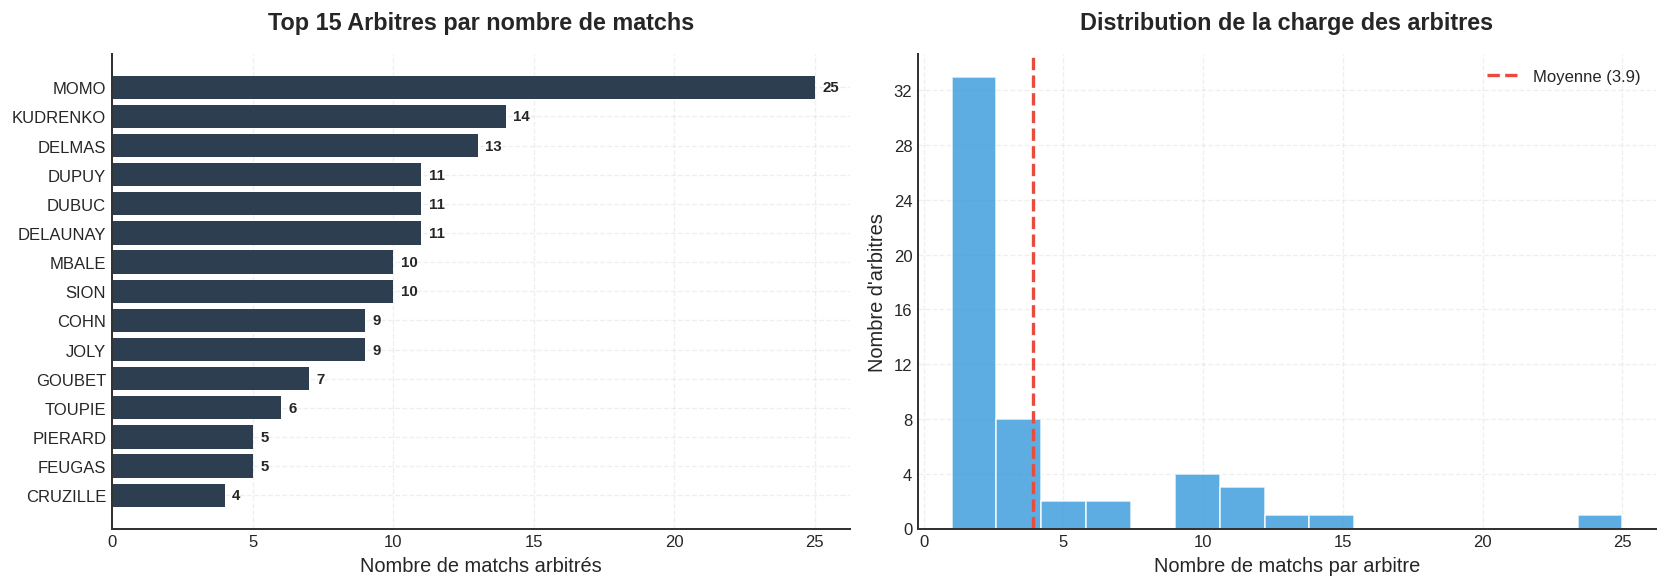


📋 TOP 20 ARBITRES:


,Arbitre,Nb_Matchs
0,MOMO,25
1,KUDRENKO,14
2,DELMAS,13
3,DUPUY,11
4,DUBUC,11
5,DELAUNAY,11
6,MBALE,10
7,SION,10
8,COHN,9
9,JOLY,9


In [6]:
# ============================================================================
# ANALYSE DES ARBITRES
# ============================================================================

print("=" * 70)
print("👨‍⚖️ ANALYSE DES ARBITRES")
print("=" * 70)

if 'Arbitres' in df_fixes.columns:
    # Statistiques de couverture
    matchs_avec_arbitre = df_fixes['Arbitres'].notna().sum()
    matchs_sans_arbitre = df_fixes['Arbitres'].isna().sum()
    total_matchs = len(df_fixes)
    taux_couverture = (matchs_avec_arbitre / total_matchs) * 100 if total_matchs > 0 else 0
    
    print(f"\n📊 COUVERTURE GLOBALE:")
    print(f"   • Matchs avec arbitre désigné: {matchs_avec_arbitre}/{total_matchs} ({taux_couverture:.1f}%)")
    print(f"   • Matchs sans arbitre: {matchs_sans_arbitre}")
    
    # Liste des arbitres et nombre de matchs
    arbitres_counts = df_fixes['Arbitres'].value_counts().reset_index()
    arbitres_counts.columns = ['Arbitre', 'Nb_Matchs']
    
    print(f"\n👥 RÉPARTITION PAR ARBITRE ({len(arbitres_counts)} arbitres uniques):")
    
    # Statistiques sur la charge
    if len(arbitres_counts) > 0:
        moy_matchs = arbitres_counts['Nb_Matchs'].mean()
        max_matchs = arbitres_counts['Nb_Matchs'].max()
        min_matchs = arbitres_counts['Nb_Matchs'].min()
        print(f"   • Moyenne de matchs/arbitre: {moy_matchs:.1f}")
        print(f"   • Maximum: {max_matchs} matchs")
        print(f"   • Minimum: {min_matchs} matchs")
    
    # Couverture par type de compétition
    print(f"\n🏆 COUVERTURE PAR TYPE DE COMPÉTITION:")
    for type_comp in df_fixes['Type_Competition'].dropna().unique():
        df_type = df_fixes[df_fixes['Type_Competition'] == type_comp]
        avec_arb = df_type['Arbitres'].notna().sum()
        total_type = len(df_type)
        taux = (avec_arb / total_type) * 100 if total_type > 0 else 0
        print(f"   • {type_comp}: {avec_arb}/{total_type} ({taux:.1f}%)")
    
    # Couverture par genre
    print(f"\n👥 COUVERTURE PAR GENRE:")
    for genre in ['F', 'M']:
        df_genre = df_fixes[df_fixes['Genre'] == genre]
        avec_arb = df_genre['Arbitres'].notna().sum()
        total_genre = len(df_genre)
        taux = (avec_arb / total_genre) * 100 if total_genre > 0 else 0
        genre_nom = 'Féminin' if genre == 'F' else 'Masculin'
        print(f"   • {genre_nom}: {avec_arb}/{total_genre} ({taux:.1f}%)")
    
    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Graphique 1: Top 15 arbitres par nombre de matchs
    ax1 = axes[0]
    top_arbitres = arbitres_counts.head(15)
    bars1 = ax1.barh(range(len(top_arbitres)), top_arbitres['Nb_Matchs'], color=COLORS['primary'])
    ax1.set_yticks(range(len(top_arbitres)))
    ax1.set_yticklabels(top_arbitres['Arbitre'])
    ax1.invert_yaxis()
    style_axis(ax1, xlabel='Nombre de matchs arbitrés', title='Top 15 Arbitres par nombre de matchs')
    add_value_labels_h(ax1, bars1)
    
    # Graphique 2: Distribution de la charge par arbitre
    ax2 = axes[1]
    ax2.hist(arbitres_counts['Nb_Matchs'], bins=15, color=COLORS['accent'], edgecolor='white', alpha=0.8)
    ax2.axvline(moy_matchs, color=COLORS['danger'], linestyle='--', linewidth=2, label=f'Moyenne ({moy_matchs:.1f})')
    style_axis(ax2, xlabel='Nombre de matchs par arbitre', ylabel='Nombre d\'arbitres', 
               title='Distribution de la charge des arbitres', integer_y=True)
    ax2.legend()
    
    plt.tight_layout()
    smart_show_individual("Analyse_arbitres")
    
    # Tableau des arbitres
    print("\n📋 TOP 20 ARBITRES:")
    display(arbitres_counts.head(20))
    
else:
    print("⚠️ La colonne 'Arbitres' n'est pas présente dans les données.")

## 3.2. Analyse Qualitative des Matchs Annulés

Cette section analyse les matchs présents dans la feuille `Matchs_Annules` pour **comprendre les raisons des annulations**.

⚠️ **IMPORTANT** : Ces matchs ne sont **PAS comptés** dans les statistiques de la phase (scores, forfaits, etc.). Cette analyse est purement qualitative.

📝 ANALYSE QUALITATIVE DES MATCHS ANNULÉS

⚠️  Ces matchs ne sont PAS inclus dans les statistiques de la phase.
    Cette section analyse uniquement les RAISONS des annulations.

📊 Nombre de matchs annulés à analyser: 25

──────────────────────────────────────────────────
📝 RAISONS DES ANNULATIONS
──────────────────────────────────────────────────

   🔸 Problème logistique: 3 match(s)
      • MATCH ANNULE - SALLE INDISPO - le 05/12 à 11h31 | Importé J9 | J9.xlsx
      • MATCH ANNULE - SALLE INDISPO - le 05/12 à 11h31 | Importé J9 | J9.xlsx
      • MATCH ANNULE - SALLE INDISPO - le 05/12 à 11h31 | Importé J9 | J9.xlsx

   🔸 Autre / Non précisé: 22 match(s)
      • Erreur programmation | Importé J1 | J1.xlsx
      • MATCH ANNULE  le 15/10 le 11h02 | Importé J1 | J1.xlsx
      • MATCH annule le 15/10 à 20H | Importé J1 | J1.xlsx
      ... et 19 autre(s)

──────────────────────────────────────────────────
📋 CONTEXTE DES ANNULATIONS
──────────────────────────────────────────────────

   Par 

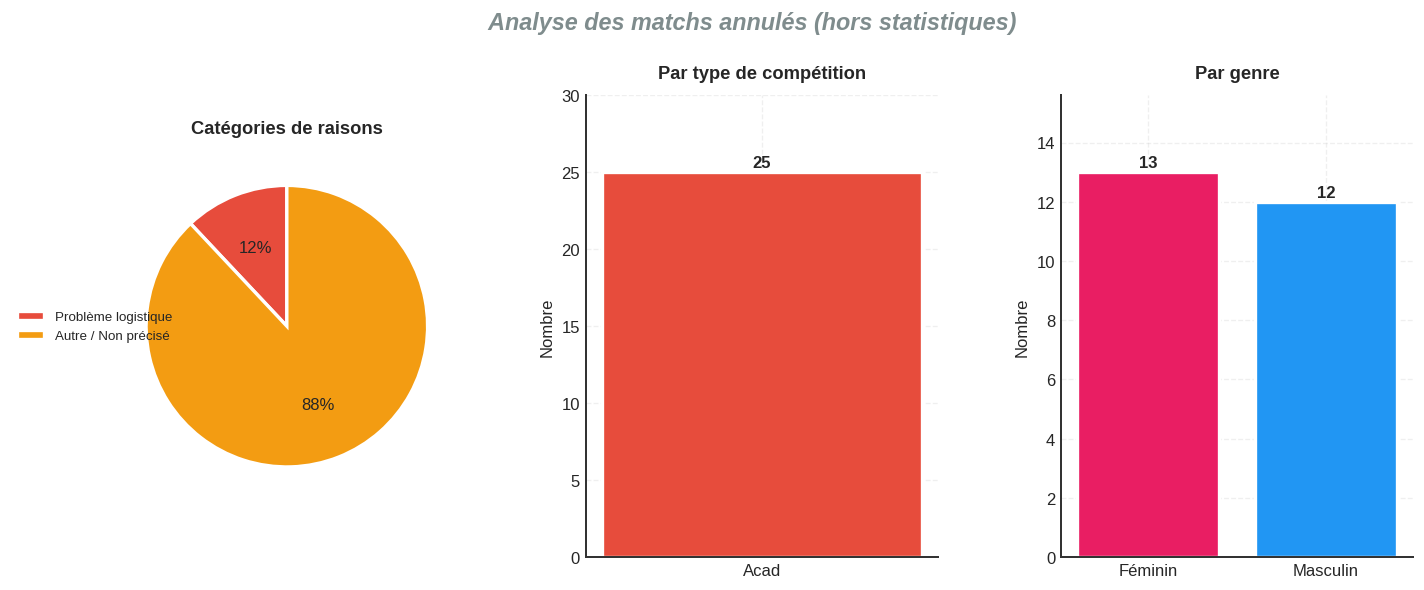


──────────────────────────────────────────────────
📋 DÉTAIL DES MATCHS ANNULÉS
──────────────────────────────────────────────────


,Equipe_1,Equipe_2,Genre,Poule,Semaine,Remarques
0,SANTE (1),LYON 2 (IEP) (4),F,VBFA2PB,1,Erreur programmation | Importé J1 | J1.xlsx
1,ENTPE (2),LYON 1 (8),F,VBFA3PA,1,MATCH ANNULE le 15/10 le 11h02 | Importé J1 |...
2,ENTPE (2),ENS (2),F,VBFA3PA,1,MATCH annule le 15/10 à 20H | Importé J1 | J1....
3,ESSCA (1),LYON 2 (8),F,VBFA4PB,1,MATCH ANNULE le 15/10 à 14h03 | Importé J1 | J...
4,INSA (1),LYON 1 (2),M,VBMA1PA,1,MATCH ANNULE le 16 oct à 11H | Importé J1 | J1...
5,INSA (4),LYON 1 (5),M,VBMA2PA,1,MATCH ANNULE le 15/10 le 11h02 | Importé J1 |...
6,ECL (2),ISARA (1),M,VBMA2PB,1,MATCH ANNULE le 14/10 à 14h42 | Importé J1 | J...
7,LYON 1 (11),INSA (5),M,VBMA3PA,1,ERREUR PROGRAMMATION MATCH NON JOUE | Importé ...
8,LYON 1 (18),ESME (2),M,VBMA4PA,1,MATCH ANNULE LE 15/10 à 11h02 | Importé J1 | J...
9,SANTE (1),LYON 1 (2),F,VBFA2PB,2,MATCH ANNULE 19/10 à 11h | Importé J2 | J2.xlsx


In [7]:
# ============================================================================
# ANALYSE QUALITATIVE DES MATCHS ANNULÉS
# Objectif: Comprendre les raisons des annulations (pas de comptage statistique)
# ============================================================================

print("=" * 70)
print("📝 ANALYSE QUALITATIVE DES MATCHS ANNULÉS")
print("=" * 70)
print("\n⚠️  Ces matchs ne sont PAS inclus dans les statistiques de la phase.")
print("    Cette section analyse uniquement les RAISONS des annulations.\n")

if len(df_annules) > 0:
    print(f"📊 Nombre de matchs annulés à analyser: {len(df_annules)}")
    
    # === ANALYSE DES RAISONS D'ANNULATION ===
    print("\n" + "─" * 50)
    print("📝 RAISONS DES ANNULATIONS")
    print("─" * 50)
    
    # Extraire et catégoriser les raisons depuis les remarques
    if 'Remarques' in df_annules.columns:
        remarques = df_annules['Remarques'].dropna()
        
        # Catégorisation des raisons
        raisons_categories = {
            'Forfait équipe': [],
            'Problème logistique': [],
            'Indisponibilité': [],
            'Report demandé': [],
            'Autre / Non précisé': []
        }
        
        for idx, rem in remarques.items():
            rem_lower = str(rem).lower()
            if 'forfait' in rem_lower or 'absente' in rem_lower or 'pas venue' in rem_lower:
                raisons_categories['Forfait équipe'].append((idx, rem))
            elif 'salle' in rem_lower or 'gymnase' in rem_lower or 'lieu' in rem_lower:
                raisons_categories['Problème logistique'].append((idx, rem))
            elif 'indispo' in rem_lower or 'examen' in rem_lower or 'stage' in rem_lower:
                raisons_categories['Indisponibilité'].append((idx, rem))
            elif 'report' in rem_lower or 'décalé' in rem_lower:
                raisons_categories['Report demandé'].append((idx, rem))
            else:
                raisons_categories['Autre / Non précisé'].append((idx, rem))
        
        # Afficher les raisons par catégorie
        for categorie, matchs in raisons_categories.items():
            if matchs:
                print(f"\n   🔸 {categorie}: {len(matchs)} match(s)")
                for idx, rem in matchs[:3]:  # Max 3 exemples par catégorie
                    print(f"      • {str(rem)[:70]}{'...' if len(str(rem)) > 70 else ''}")
                if len(matchs) > 3:
                    print(f"      ... et {len(matchs) - 3} autre(s)")
    
    # === CONTEXTE DES ANNULATIONS ===
    print("\n" + "─" * 50)
    print("📋 CONTEXTE DES ANNULATIONS")
    print("─" * 50)
    
    # Par type de compétition
    if 'Type_Competition' in df_annules.columns:
        annules_par_type = df_annules['Type_Competition'].value_counts()
        print("\n   Par type de compétition:")
        for type_comp, count in annules_par_type.items():
            print(f"      • {type_comp}: {count}")
    
    # Par poule
    if 'Poule' in df_annules.columns:
        annules_par_poule = df_annules['Poule'].value_counts()
        print("\n   Par poule (top 5):")
        for poule, count in annules_par_poule.head(5).items():
            print(f"      • {poule}: {count}")
    
    # Par semaine
    if 'Semaine' in df_annules.columns:
        annules_par_semaine = df_annules['Semaine'].dropna().value_counts().sort_index()
        if len(annules_par_semaine) > 0:
            print("\n   Par semaine:")
            for semaine, count in annules_par_semaine.items():
                print(f"      • Semaine {int(semaine)}: {count}")
    
    # === ÉQUIPES CONCERNÉES ===
    print("\n" + "─" * 50)
    print("🏐 ÉQUIPES CONCERNÉES PAR LES ANNULATIONS")
    print("─" * 50)
    
    equipes_touchees = []
    for _, row in df_annules.iterrows():
        for eq_col in ['Equipe_1', 'Equipe_2']:
            if eq_col in row and pd.notna(row[eq_col]):
                equipe = str(row[eq_col]).strip()
                genre = row.get('Genre', '')
                equipes_touchees.append(f"{equipe} [{genre}]" if genre else equipe)
    
    if equipes_touchees:
        from collections import Counter
        equipes_counts = Counter(equipes_touchees)
        print("\n   Équipes les plus touchées:")
        for equipe, count in equipes_counts.most_common(8):
            print(f"      • {equipe}: {count} match(s) annulé(s)")
    
    # === VISUALISATION ===
    if len(df_annules) >= 2:
        # Créer une visualisation synthétique
        fig = plt.figure(figsize=(14, 5))
        fig.suptitle("📝 Analyse des matchs annulés (hors statistiques)", 
                     fontsize=14, fontweight='bold', y=1.02,
                     color='#7f8c8d', style='italic')
        
        gs = fig.add_gridspec(1, 3, wspace=0.35)
        
        # Graphique 1: Raisons catégorisées
        ax1 = fig.add_subplot(gs[0, 0])
        raisons_counts = {k: len(v) for k, v in raisons_categories.items() if len(v) > 0}
        if raisons_counts:
            colors_raisons = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#95a5a6']
            wedges, texts, autotexts = ax1.pie(
                raisons_counts.values(), 
                labels=None,
                autopct=lambda pct: f'{pct:.0f}%' if pct > 10 else '',
                colors=colors_raisons[:len(raisons_counts)],
                startangle=90,
                wedgeprops={'edgecolor': 'white', 'linewidth': 2}
            )
            ax1.legend(raisons_counts.keys(), loc='center left', bbox_to_anchor=(-0.3, 0.5), fontsize=8)
            ax1.set_title('Catégories de raisons', fontsize=11, fontweight='bold', pad=10)
        
        # Graphique 2: Par type de compétition
        ax2 = fig.add_subplot(gs[0, 1])
        if 'Type_Competition' in df_annules.columns:
            types = df_annules['Type_Competition'].value_counts()
            colors_types = ['#e74c3c', '#f39c12', '#3498db'][:len(types)]
            bars = ax2.bar(types.index, types.values, color=colors_types, 
                          edgecolor='white', linewidth=2)
            ax2.set_ylabel('Nombre', fontsize=10)
            ax2.set_title('Par type de compétition', fontsize=11, fontweight='bold', pad=10)
            ax2.tick_params(axis='x', rotation=0)
            for bar in bars:
                height = bar.get_height()
                ax2.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                           xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
            ax2.set_ylim(0, types.max() * 1.2)
            ax2.spines['top'].set_visible(False)
            ax2.spines['right'].set_visible(False)
        
        # Graphique 3: Par genre
        ax3 = fig.add_subplot(gs[0, 2])
        if 'Genre' in df_annules.columns:
            genres = df_annules['Genre'].value_counts()
            genre_labels = ['Féminin' if g == 'F' else 'Masculin' for g in genres.index]
            colors_genre = [COLORS.get('Féminin', '#e91e63'), COLORS.get('Masculin', '#2196f3')][:len(genres)]
            bars = ax3.bar(genre_labels, genres.values, color=colors_genre,
                          edgecolor='white', linewidth=2)
            ax3.set_ylabel('Nombre', fontsize=10)
            ax3.set_title('Par genre', fontsize=11, fontweight='bold', pad=10)
            for bar in bars:
                height = bar.get_height()
                ax3.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                           xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
            ax3.set_ylim(0, genres.max() * 1.2)
            ax3.spines['top'].set_visible(False)
            ax3.spines['right'].set_visible(False)
        
        plt.tight_layout()
        smart_show_individual("Matchs_annules")
    
    # === TABLEAU DÉTAILLÉ ===
    print("\n" + "─" * 50)
    print("📋 DÉTAIL DES MATCHS ANNULÉS")
    print("─" * 50)
    
    cols_display = ['Equipe_1', 'Equipe_2', 'Genre', 'Poule', 'Semaine', 'Remarques']
    cols_available = [c for c in cols_display if c in df_annules.columns]
    
    # Formater le tableau pour une meilleure lisibilité
    df_display = df_annules[cols_available].copy()
    if 'Remarques' in df_display.columns:
        df_display['Remarques'] = df_display['Remarques'].apply(
            lambda x: str(x)[:50] + '...' if pd.notna(x) and len(str(x)) > 50 else x
        )
    display(df_display)

else:
    print("\n✅ Aucun match annulé dans la feuille 'Matchs_Annules'.")
    print("\n💡 Lorsque des matchs seront ajoutés à cette feuille,")
    print("   cette section analysera automatiquement les raisons d'annulation.")
    print("\n📊 Note: Les statistiques de la phase concernent uniquement")
    print("   les matchs de la feuille 'Matchs_Fixes'.")

## 4. Calcul des horaires préférés des équipes

Pour chaque match, l'horaire effectif est considéré comme le maximum des horaires préférés des deux équipes.

In [8]:
# ============================================================================
# CRÉATION DU MAPPING DES HORAIRES PRÉFÉRÉS PAR ÉQUIPE
# ============================================================================

# Créer un dictionnaire équipe -> horaire préféré (en minutes)
horaires_preferes = {}

if 'Horaire_Prefere' in df_equipes.columns:
    for _, row in df_equipes.iterrows():
        equipe = row.get('Equipe', '')
        poule = row.get('Poule', '')
        horaire = row.get('Horaire_Prefere')
        
        if pd.notna(equipe) and pd.notna(horaire):
            equipe_str = str(equipe).strip()
            horaire_min = parser_horaire(horaire)
            if horaire_min is not None:
                # Stocker avec le genre si présent dans la poule
                genre = ''
                if pd.notna(poule) and len(str(poule)) > 2:
                    genre_char = str(poule)[2] if len(str(poule)) > 2 else ''
                    if genre_char in ['F', 'M']:
                        genre = genre_char
                
                # Clé: équipe avec et sans genre
                horaires_preferes[equipe_str] = horaire_min
                if genre:
                    horaires_preferes[f"{equipe_str} [{genre}]"] = horaire_min

print(f"📋 Horaires préférés chargés pour {len(horaires_preferes)} équipes")

# Fonction pour obtenir l'horaire préféré d'une équipe
def get_horaire_prefere(equipe, genre=None):
    """Retourne l'horaire préféré d'une équipe (en minutes depuis minuit)."""
    if pd.isna(equipe):
        return None
    
    equipe_str = str(equipe).strip()
    
    # Essayer avec le genre
    if genre:
        key_with_genre = f"{equipe_str} [{genre}]"
        if key_with_genre in horaires_preferes:
            return horaires_preferes[key_with_genre]
    
    # Essayer sans le genre
    if equipe_str in horaires_preferes:
        return horaires_preferes[equipe_str]
    
    return None


def minutes_to_time_str(minutes):
    """Convertit des minutes en chaîne HH:MM."""
    if minutes is None or pd.isna(minutes):
        return None
    # Convertir en entier pour gérer les floats
    minutes_int = int(minutes)
    h = minutes_int // 60
    m = minutes_int % 60
    return f"{h:02d}:{m:02d}"


# Calcul de l'horaire théorique de chaque match (max des deux horaires préférés)
def calculer_horaire_theorique(row):
    h1 = get_horaire_prefere(row.get('Equipe_1'), row.get('Genre'))
    h2 = get_horaire_prefere(row.get('Equipe_2'), row.get('Genre'))
    
    if h1 is None and h2 is None:
        return None
    if h1 is None:
        return h2
    if h2 is None:
        return h1
    return max(h1, h2)

df['horaire_theorique_min'] = df.apply(calculer_horaire_theorique, axis=1)
df['horaire_theorique'] = df['horaire_theorique_min'].apply(minutes_to_time_str)

# Propager vers df_fixes (df_fixes est une copie de df, donc les valeurs sont déjà là)
df_fixes['horaire_theorique_min'] = df['horaire_theorique_min'].values
df_fixes['horaire_theorique'] = df['horaire_theorique'].values

# Statistiques sur les horaires théoriques
horaires_valides = df['horaire_theorique_min'].dropna()
print(f"\n📊 Horaires théoriques calculés:")
print(f"   Matchs avec horaire théorique: {len(horaires_valides)}/{len(df)}")
if len(horaires_valides) > 0:
    print(f"   Horaire min: {minutes_to_time_str(horaires_valides.min())}")
    print(f"   Horaire max: {minutes_to_time_str(horaires_valides.max())}")
    print(f"   Horaire médian: {minutes_to_time_str(horaires_valides.median())}")

📋 Horaires préférés chargés pour 204 équipes

📊 Horaires théoriques calculés:
   Matchs avec horaire théorique: 258/261
   Horaire min: 14:00
   Horaire max: 20:00
   Horaire médian: 18:00


## 5. 📊 Statistiques globales et tableau de synthèse

📊 STATISTIQUES GLOBALES DE LA PHASE
   ⚠️ Basées uniquement sur la feuille Matchs_Fixes

📌 COMPTAGES PRINCIPAUX:
   • Matchs théoriques (Acad):       266 (calculé: équipes × poules)
   • Matchs fixés:                   261
   • Matchs non planifiés:            33 (théoriques - fixés)
   • Taux de complétion global:    98.1%

🏆 RÉPARTITION PAR TYPE DE COMPÉTITION:
   • Acad (Championnat Académique):   233
   • CFE (Coupe de France Écoles):    20
   • CFU (Coupe de France Université):     5
   • Autre:                            3
   ─────────────────────────────────────
   • Total:                          261

   📈 Taux de complétion Acad:      87.6% (233/266)

📋 DÉTAIL DES MATCHS JOUÉS:
   ✅ Avec score enregistré:         224 (85.8%)
   ❓ Sans score (mais joués):        37

⚠️ PROBLÈMES DÉTECTÉS (dans Matchs_Fixes):
   🚫 Forfaits:                        6 (2.3%)
      (détectés via remarques + scores atypiques comme 1-0, 2-1)
   ❌ Annulés (via remarques):         2
   📅 Reportés:     

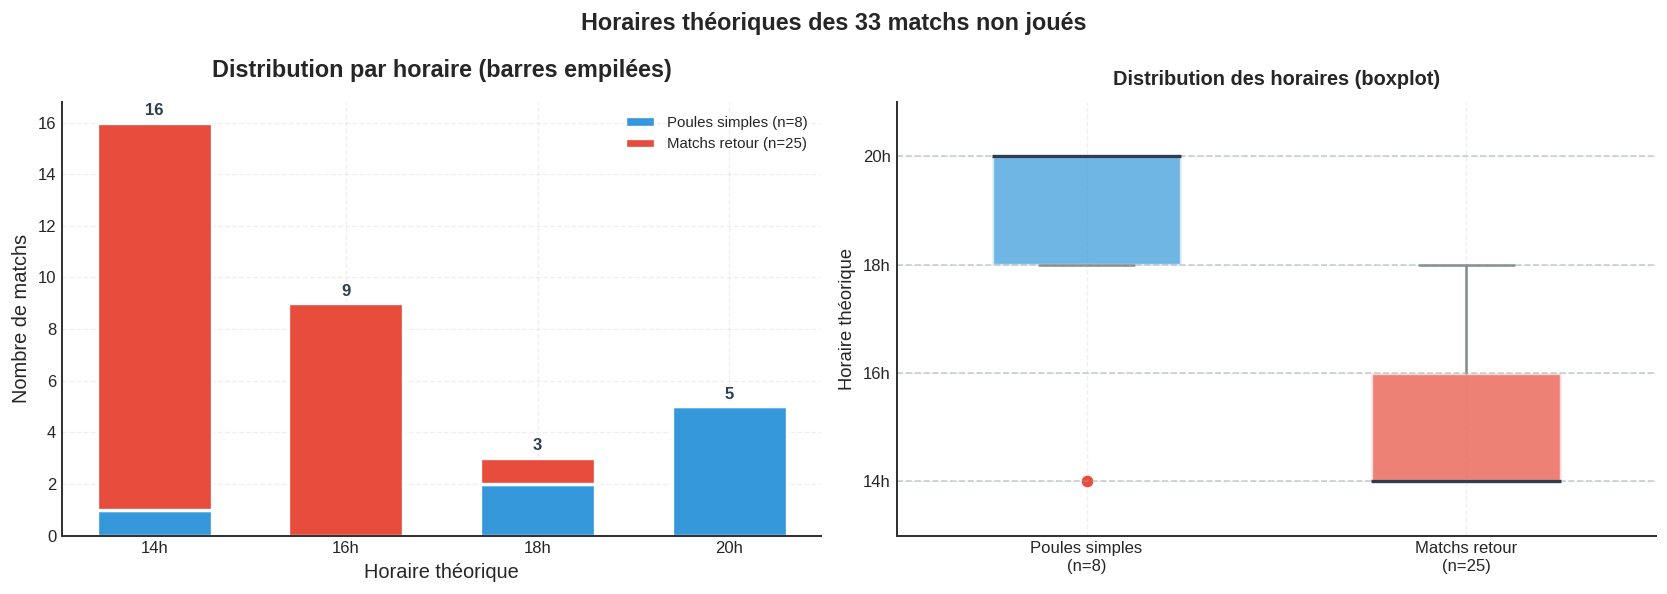

In [9]:
# ============================================================================
# STATISTIQUES GLOBALES
# ============================================================================

# Calcul du nombre théorique de matchs par poule (en fonction du type de poule)
def calculer_matchs_theoriques_poule(n_equipes, is_aller_retour=False):
    """Calcule le nombre de matchs théoriques pour une poule.
    - Poule simple: n*(n-1)/2 matchs
    - Poule aller-retour: n*(n-1) matchs
    """
    if n_equipes < 2:
        return 0
    matchs_simples = n_equipes * (n_equipes - 1) // 2
    return matchs_simples * 2 if is_aller_retour else matchs_simples

# Compter les équipes par poule depuis la feuille Equipes
equipes_par_poule = df_equipes.groupby('Poule').size().to_dict() if 'Poule' in df_equipes.columns else {}

# Calculer le nombre théorique total (matchs Acad uniquement)
matchs_theoriques_total = 0
matchs_theoriques_detail = {}
for poule, n_equipes in equipes_par_poule.items():
    is_ar = str(poule) in poules_aller_retour
    nb_matchs = calculer_matchs_theoriques_poule(n_equipes, is_ar)
    matchs_theoriques_total += nb_matchs
    matchs_theoriques_detail[poule] = {
        'n_equipes': n_equipes,
        'is_aller_retour': is_ar,
        'matchs_theoriques': nb_matchs
    }

# Compter les matchs dans Matchs_Fixes par poule (utiliser df_fixes uniquement)
matchs_fixes_par_poule = df_fixes.groupby('Poule').size().to_dict()

# Identifier les matchs non planifiés (théoriques - présents dans Matchs_Fixes)
matchs_non_planifies = {}
matchs_non_planifies_total = 0
for poule, detail in matchs_theoriques_detail.items():
    fixes = matchs_fixes_par_poule.get(poule, 0)
    non_planifies = detail['matchs_theoriques'] - fixes
    if non_planifies > 0:
        matchs_non_planifies[poule] = {
            'manquants': non_planifies,
            'theoriques': detail['matchs_theoriques'],
            'fixes': fixes,
            'is_aller_retour': detail['is_aller_retour']
        }
        matchs_non_planifies_total += non_planifies

# Statistiques sur les matchs non planifiés
non_planif_ar = {p: d for p, d in matchs_non_planifies.items() if d['is_aller_retour']}
non_planif_simple = {p: d for p, d in matchs_non_planifies.items() if not d['is_aller_retour']}
total_manquants_ar = sum(d['manquants'] for d in non_planif_ar.values())
total_manquants_simple = sum(d['manquants'] for d in non_planif_simple.values())

# === STATISTIQUES PAR TYPE DE COMPÉTITION ===
# Compter les matchs par type de compétition
type_col = None
for col in ['Type_Competition', 'Type_Championnat', 'Type']:
    if col in df_fixes.columns:
        type_col = col
        break

if type_col:
    # Nettoyer les valeurs
    df_fixes['Type_Competition'] = df_fixes[type_col].fillna('Non spécifié').astype(str).str.strip()
    df_fixes.loc[df_fixes['Type_Competition'] == '', 'Type_Competition'] = 'Non spécifié'
    
    matchs_acad = len(df_fixes[df_fixes['Type_Competition'].str.contains('Acad', case=False, na=False)])
    matchs_cfe = len(df_fixes[df_fixes['Type_Competition'].str.contains('CFE', case=False, na=False)])
    matchs_cfu = len(df_fixes[df_fixes['Type_Competition'].str.contains('CFU', case=False, na=False)])
    matchs_autre = len(df_fixes) - matchs_acad - matchs_cfe - matchs_cfu
    
    # Matchs Acad joués (avec score)
    matchs_acad_joues = len(df_fixes[(df_fixes['Type_Competition'].str.contains('Acad', case=False, na=False)) & df_fixes['has_score']])
    taux_completion_acad = (matchs_acad / matchs_theoriques_total * 100) if matchs_theoriques_total > 0 else 0
else:
    matchs_acad = len(df_fixes)
    matchs_cfe = 0
    matchs_cfu = 0
    matchs_autre = 0
    matchs_acad_joues = df_fixes['has_score'].sum()
    taux_completion_acad = (matchs_acad / matchs_theoriques_total * 100) if matchs_theoriques_total > 0 else 0

# === STATISTIQUES SUR LES ARBITRES ===
if 'Arbitres' in df_fixes.columns:
    matchs_avec_arbitre = df_fixes['Arbitres'].notna().sum()
    matchs_sans_arbitre = df_fixes['Arbitres'].isna().sum()
    arbitres_uniques = df_fixes['Arbitres'].dropna().unique()
    nb_arbitres_uniques = len(arbitres_uniques)
    taux_couverture_arbitres = (matchs_avec_arbitre / len(df_fixes) * 100) if len(df_fixes) > 0 else 0
else:
    matchs_avec_arbitre = 0
    matchs_sans_arbitre = len(df_fixes)
    nb_arbitres_uniques = 0
    taux_couverture_arbitres = 0

# === CALCUL DES ENTENTES CORRECTES (basé sur is_entente_auto) ===
# is_entente_auto = True si gymnase ENTENTE OU jour ≠ jeudi
matchs_ententes_correct = df_fixes['is_entente_auto'].sum() if 'is_entente_auto' in df_fixes.columns else 0

# Dictionnaire principal des statistiques
stats = {
    'total_matchs_theoriques': matchs_theoriques_total,
    'total_matchs_fixes': len(df_fixes),
    'total_matchs_annules': len(df_annules) if len(df_annules) > 0 else 0,
    'matchs_avec_score': len(df_fixes[df_fixes['has_score']]),
    'matchs_sans_score': len(df_fixes[~df_fixes['has_score']]),
    'matchs_non_planifies': matchs_non_planifies_total,  # Théoriques - Fixés
    'matchs_forfaits': len(df_fixes[df_fixes['is_forfait']]),  # CORRECTION: utiliser is_forfait au lieu de statut
    'matchs_annules_remarques': len(df_fixes[df_fixes['statut'] == 'annulé']),  # Annulés dans Matchs_Fixes (via remarques)
    'matchs_reportes': len(df_fixes[df_fixes['statut'] == 'reporté']),
    'matchs_ententes': matchs_ententes_correct,  # Calcul correct (is_entente_auto)
    'matchs_score_manquant': len(df_fixes[df_fixes['statut'] == 'score_manquant']),
    'matchs_aller_retour': len(df_fixes[df_fixes['is_aller_retour']]),
    'matchs_compte_double': len(df_fixes[df_fixes['is_compte_double']]),
    'nb_poules': df_fixes['Poule'].nunique(),
    'nb_equipes': len(set(df_fixes['Equipe_1'].dropna()) | set(df_fixes['Equipe_2'].dropna())),
    'nb_gymnases': df_fixes['Gymnase'].nunique(),
    'nb_semaines': df_fixes['Semaine'].nunique(),
    # Champs par type de compétition
    'matchs_acad': matchs_acad,
    'matchs_cfe': matchs_cfe,
    'matchs_cfu': matchs_cfu,
    'matchs_autre': matchs_autre,
    'taux_completion_acad': taux_completion_acad,
    # Arbitres
    'matchs_avec_arbitre': matchs_avec_arbitre,
    'matchs_sans_arbitre': matchs_sans_arbitre,
    'nb_arbitres': nb_arbitres_uniques,
    'taux_couverture_arbitres': taux_couverture_arbitres,
}

# Calcul des taux
stats['taux_scores'] = (stats['matchs_avec_score'] / stats['total_matchs_fixes'] * 100) if stats['total_matchs_fixes'] > 0 else 0
stats['taux_fixes_vs_theoriques'] = (stats['total_matchs_fixes'] / stats['total_matchs_theoriques'] * 100) if stats['total_matchs_theoriques'] > 0 else 0
stats['taux_forfaits'] = (stats['matchs_forfaits'] / stats['total_matchs_fixes'] * 100) if stats['total_matchs_fixes'] > 0 else 0

# Affichage du résumé
print("=" * 70)
print("📊 STATISTIQUES GLOBALES DE LA PHASE")
print("=" * 70)
print("   ⚠️ Basées uniquement sur la feuille Matchs_Fixes")

print("\n📌 COMPTAGES PRINCIPAUX:")
print(f"   • Matchs théoriques (Acad):     {stats['total_matchs_theoriques']:>5} (calculé: équipes × poules)")
print(f"   • Matchs fixés:                 {stats['total_matchs_fixes']:>5}")
print(f"   • Matchs non planifiés:         {stats['matchs_non_planifies']:>5} (théoriques - fixés)")
print(f"   • Taux de complétion global:   {stats['taux_fixes_vs_theoriques']:>5.1f}%")

print("\n🏆 RÉPARTITION PAR TYPE DE COMPÉTITION:")
print(f"   • Acad (Championnat Académique): {stats['matchs_acad']:>5}")
print(f"   • CFE (Coupe de France Écoles): {stats['matchs_cfe']:>5}")
print(f"   • CFU (Coupe de France Université): {stats['matchs_cfu']:>5}")
print(f"   • Autre:                        {stats['matchs_autre']:>5}")
print(f"   ─────────────────────────────────────")
print(f"   • Total:                        {stats['total_matchs_fixes']:>5}")
print(f"\n   📈 Taux de complétion Acad:     {stats['taux_completion_acad']:>5.1f}% ({stats['matchs_acad']}/{stats['total_matchs_theoriques']})")

print("\n📋 DÉTAIL DES MATCHS JOUÉS:")
print(f"   ✅ Avec score enregistré:       {stats['matchs_avec_score']:>5} ({stats['taux_scores']:.1f}%)")
print(f"   ❓ Sans score (mais joués):     {stats['matchs_sans_score']:>5}")

print("\n⚠️ PROBLÈMES DÉTECTÉS (dans Matchs_Fixes):")
print(f"   🚫 Forfaits:                    {stats['matchs_forfaits']:>5} ({stats['taux_forfaits']:.1f}%)")
print("      (détectés via remarques + scores atypiques comme 1-0, 2-1)")
print(f"   ❌ Annulés (via remarques):     {stats['matchs_annules_remarques']:>5}")
print(f"   📅 Reportés:                    {stats['matchs_reportes']:>5}")

if stats['total_matchs_annules'] > 0:
    print(f"\n📝 MATCHS ANNULÉS (feuille Matchs_Annules): {stats['total_matchs_annules']}")
    print("   → Ces matchs ne sont PAS inclus dans les statistiques ci-dessus")
    print("   → Voir la section 'Analyse Qualitative des Matchs Annulés' pour les détails")

print("\n👨‍⚖️ ARBITRAGE:")
print(f"   • Matchs avec arbitre:  {stats['matchs_avec_arbitre']:>5} ({stats['taux_couverture_arbitres']:.1f}%)")
print(f"   • Matchs sans arbitre:  {stats['matchs_sans_arbitre']:>5}")
print(f"   • Nombre d'arbitres:    {stats['nb_arbitres']:>5}")

print("\n📋 CATÉGORIES SPÉCIALES:")
print(f"   🤝 Ententes (non-jeudi ou gym ENTENTE): {stats['matchs_ententes']:>5}")
print(f"   🔄 Poules Aller-Retour:  {stats['matchs_aller_retour']:>5}")
print(f"   ✌️ Compte double:        {stats['matchs_compte_double']:>5}")

print("\n🏟️ STRUCTURE:")
print(f"   • Nombre de poules:   {stats['nb_poules']:>5}")
print(f"   • Nombre d'équipes:   {stats['nb_equipes']:>5}")
print(f"   • Nombre de gymnases: {stats['nb_gymnases']:>5}")
print(f"   • Nombre de semaines: {stats['nb_semaines']:>5}")

# Debug: Afficher les valeurs uniques du type de compétition
if type_col:
    print(f"\n🔍 DEBUG - Valeurs uniques de {type_col}:")
    type_values = df_fixes[type_col].value_counts()
    for val, cnt in type_values.items():
        print(f"   • '{val}': {cnt}")

# Analyse des matchs non joués (potentiels matchs retour)
if matchs_non_planifies:
    print("\n" + "=" * 70)
    print("🔍 ANALYSE DES MATCHS NON PLANIFIÉS (potentiels matchs retour)")
    print("=" * 70)
    
    print(f"\n📊 RÉSUMÉ:")
    print(f"   • Total matchs manquants: {matchs_non_planifies_total}")
    print(f"   • Dans poules Aller-Retour: {total_manquants_ar} matchs (probablement matchs retour)")
    print(f"   • Dans poules simples: {total_manquants_simple} matchs")
    
    # Détail par poule (top 10)
    if matchs_non_planifies:
        print(f"\n📋 TOP 10 POULES AVEC MATCHS MANQUANTS:")
        sorted_poules = sorted(matchs_non_planifies.items(), key=lambda x: -x[1]['manquants'])[:10]
        for poule, info in sorted_poules:
            type_str = "Aller-Retour" if info['is_aller_retour'] else "Simple"
            print(f"   • {poule} ({type_str}): {info['manquants']}/{info['theoriques']} matchs manquants")
    
    # Graphique de distribution
    print("\n📊 VISUALISATION DES HORAIRES DES MATCHS NON JOUÉS:")
    
    # Analyser les horaires théoriques des matchs non joués par poule
    horaires_non_joues = {'simple': [], 'retour': []}
    
    for poule, d in matchs_non_planifies.items():
        matchs_poule = df_fixes[df_fixes['Poule'] == poule]
        horaires_poule = matchs_poule['horaire_theorique_min'].dropna().values
        
        if len(horaires_poule) > 0:
            nb_manquants = d['manquants']
            # Prendre les horaires les plus fréquents comme représentatifs
            horaire_median = int(np.median(horaires_poule))
            
            # Ajouter les horaires pour les matchs manquants
            for _ in range(nb_manquants):
                if d['is_aller_retour']:
                    horaires_non_joues['retour'].append(horaire_median)
                else:
                    horaires_non_joues['simple'].append(horaire_median)
    
    # Créer le graphique
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Horaires théoriques des {matchs_non_planifies_total} matchs non joués', 
                 fontsize=14, fontweight='bold')
    
    # Graphique 1: Distribution par horaire (barres empilées)
    all_horaires_heures = horaires_non_joues['simple'] + horaires_non_joues['retour']
    if all_horaires_heures:
        horaires_importants = [14, 16, 18, 20]
        bins_heures = [h - 0.5 for h in horaires_importants] + [20.5]
        
        # Convertir en heures
        horaires_simple_h = [h/60 for h in horaires_non_joues['simple']]
        horaires_retour_h = [h/60 for h in horaires_non_joues['retour']]
        
        # Compter les matchs par horaire
        counts_simple = {}
        counts_retour = {}
        for h in horaires_importants:
            counts_simple[h] = sum(1 for x in horaires_simple_h if abs(x - h) < 1)
            counts_retour[h] = sum(1 for x in horaires_retour_h if abs(x - h) < 1)
        
        # Barres empilées
        x_pos = np.arange(len(horaires_importants))
        vals_simple = [counts_simple[h] for h in horaires_importants]
        vals_retour = [counts_retour[h] for h in horaires_importants]
        
        bars1 = ax1.bar(x_pos, vals_simple, width=0.6, label=f'Poules simples (n={len(horaires_non_joues["simple"])})', 
                       color='#3498db', edgecolor='white', linewidth=2)
        bars2 = ax1.bar(x_pos, vals_retour, width=0.6, bottom=vals_simple,
                       label=f'Matchs retour (n={len(horaires_non_joues["retour"])})', 
                       color='#e74c3c', edgecolor='white', linewidth=2)
        
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels([f'{h}h' for h in horaires_importants])
        ax1.legend(loc='upper right', fontsize=9)
        ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
        style_axis(ax1, 'Horaire théorique', 'Nombre de matchs', 
                   'Distribution par horaire (barres empilées)', integer_y=True)
        
        # Ajouter les totaux
        for i, (s, r) in enumerate(zip(vals_simple, vals_retour)):
            total = s + r
            if total > 0:
                ax1.text(i, total + 0.3, str(total), ha='center', 
                        fontsize=10, fontweight='bold', color='#2c3e50')
    
    # Graphique 2: Boxplot pour voir la distribution
    data_boxplot = []
    labels_box = []
    colors_box = []
    
    if horaires_non_joues['simple']:
        data_boxplot.append([h/60 for h in horaires_non_joues['simple']])
        labels_box.append(f"Poules simples\n(n={len(horaires_non_joues['simple'])})")
        colors_box.append('#3498db')
    
    if horaires_non_joues['retour']:
        data_boxplot.append([h/60 for h in horaires_non_joues['retour']])
        labels_box.append(f"Matchs retour\n(n={len(horaires_non_joues['retour'])})")
        colors_box.append('#e74c3c')
    
    if data_boxplot:
        bp = ax2.boxplot(data_boxplot, labels=labels_box, patch_artist=True, widths=0.5)
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
            patch.set_edgecolor('white')
            patch.set_linewidth(2)
        for median in bp['medians']:
            median.set_color('#2c3e50')
            median.set_linewidth(2)
        for whisker in bp['whiskers']:
            whisker.set_color('#7f8c8d')
            whisker.set_linewidth(1.5)
        for cap in bp['caps']:
            cap.set_color('#7f8c8d')
            cap.set_linewidth(1.5)
        for flier in bp['fliers']:
            flier.set_markerfacecolor('#e74c3c')
            flier.set_markeredgecolor('white')
            flier.set_markersize(8)
        
        # Ajouter les lignes horizontales pour les horaires standards
        for h in horaires_importants:
            ax2.axhline(y=h, color='#95a5a6', linestyle='--', linewidth=1, alpha=0.5)
        
        ax2.set_ylim(13, 21)
        ax2.set_yticks(horaires_importants)
        ax2.set_yticklabels([f'{h}h' for h in horaires_importants])
        ax2.set_title('Distribution des horaires (boxplot)', fontsize=12, fontweight='bold', pad=10)
        ax2.set_ylabel('Horaire théorique', fontsize=11)
        ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()


## 6. 📈 Graphiques de distribution des statuts

   💾 Sauvegardé: 06_Distribution_statuts_Répartition_des_matchsfixés__joués_non_planifiés__à_jouer.png
   💾 Sauvegardé: 07_Distribution_statuts_Nombre_de_matchs_par_catégorie.png


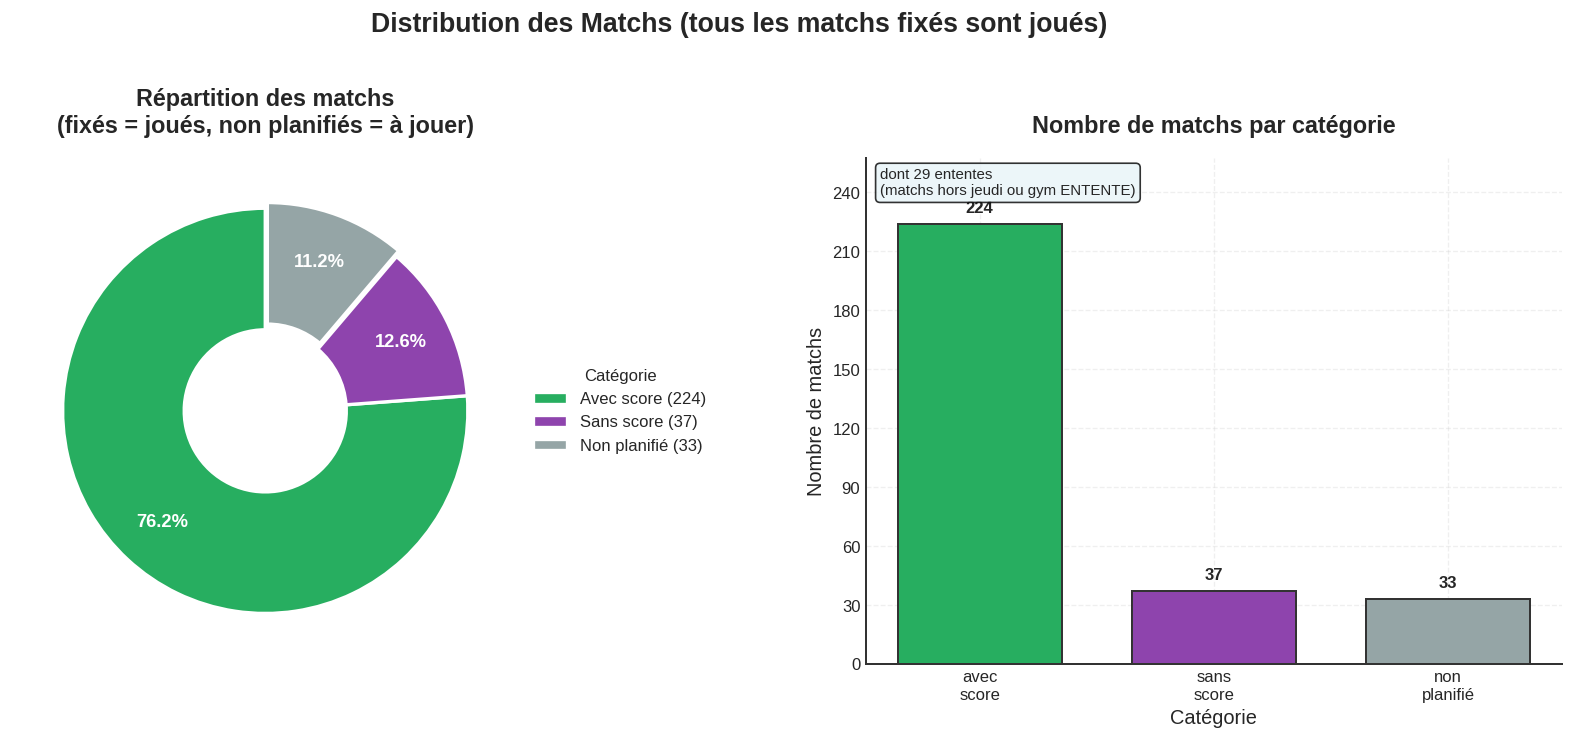

In [10]:
# ============================================================================
# GRAPHIQUES DE DISTRIBUTION DES STATUTS
# Note: TOUS les matchs dans Matchs_Fixes sont JOUÉS (certains avec score, d'autres sans)
# Inclure les matchs non planifiés dans la visualisation
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribution des Matchs (tous les matchs fixés sont joués)', fontsize=16, fontweight='bold', y=1.02)

# Créer une distribution basée sur les concepts clairs :
# - Joué avec score
# - Joué sans score
# - Entente (is_entente_auto = gymnase ENTENTE ou jour ≠ jeudi)
# - Non planifié

# Compter les matchs selon les critères précis
matchs_avec_score = len(df[df['has_score'] & ~df['is_entente_auto']])
matchs_sans_score = len(df[~df['has_score'] & ~df['is_entente_auto']])
matchs_entente_avec_score = len(df[df['has_score'] & df['is_entente_auto']])
matchs_entente_sans_score = len(df[~df['has_score'] & df['is_entente_auto']])
total_ententes = df['is_entente_auto'].sum()

# Distribution simplifiée pour le graphique
distribution = pd.Series({
    'avec_score': matchs_avec_score + matchs_entente_avec_score,  # Tous les matchs avec score
    'sans_score': matchs_sans_score + matchs_entente_sans_score,  # Matchs joués mais sans score
    'non_planifié': stats['matchs_non_planifies']
}, name='count')

# Supprimer les catégories vides
distribution = distribution[distribution > 0]

# Définir les couleurs
COLORS_DISTRIB = {
    'avec_score': COLORS['joué'],
    'sans_score': COLORS['score_manquant'],
    'non_planifié': '#95a5a6'
}

pie_colors = [COLORS_DISTRIB.get(s, '#bdc3c7') for s in distribution.index]

# ─── Graphique 1: Pie chart ───
labels_pie = [s.replace('_', ' ').capitalize() for s in distribution.index]
wedges, texts, autotexts = axes[0].pie(
    distribution.values, 
    labels=None,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',
    colors=pie_colors,
    explode=[0.03 if s == 'non_planifié' else 0 for s in distribution.index],
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2)
)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Légende avec détails
legend_labels = [f'{s.replace("_", " ").capitalize()} ({c})' for s, c in zip(distribution.index, distribution.values)]
axes[0].legend(wedges, legend_labels, title='Catégorie', loc='center left', 
               bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)
style_axis(axes[0], title='Répartition des matchs\n(fixés = joués, non planifiés = à jouer)')

# ─── Graphique 2: Bar chart ───
x_pos = np.arange(len(distribution))
bars = axes[1].bar(x_pos, distribution.values, color=pie_colors, 
                   edgecolor='#333333', linewidth=1.2, width=0.7)

axes[1].set_xticks(x_pos)
labels_formatted = [s.replace('_', '\n') for s in distribution.index]
axes[1].set_xticklabels(labels_formatted, rotation=0, ha='center', fontsize=9)

add_value_labels(axes[1], bars, fmt='{:.0f}', fontsize=10)
style_axis(axes[1], title='Nombre de matchs par catégorie', 
           xlabel='Catégorie', ylabel='Nombre de matchs', integer_y=True)
axes[1].set_ylim(0, distribution.max() * 1.15)

# Ajouter une annotation pour les ententes
axes[1].annotate(f'dont {total_ententes} ententes\n(matchs hors jeudi ou gym ENTENTE)', 
                 xy=(0.02, 0.98), xycoords='axes fraction',
                 fontsize=9, va='top', ha='left',
                 bbox=dict(boxstyle='round', facecolor='#e8f4f8', alpha=0.8))

plt.tight_layout()
smart_show_individual("Distribution_statuts")

## 7. ⏰ Distribution des horaires des matchs

   💾 Sauvegardé: 08_Distribution_horaires_Horaires_réels_enregistrés.png
   💾 Sauvegardé: 09_Distribution_horaires_Horaires_théoriques_max_des_préférés.png
   💾 Sauvegardé: 09_Distribution_horaires_Horaires_théoriques_max_des_préférés.png
   💾 Sauvegardé: 10_Distribution_horaires_Horaires_des_matchs_sans_score_37_matchs.png
   💾 Sauvegardé: 10_Distribution_horaires_Horaires_des_matchs_sans_score_37_matchs.png
   💾 Sauvegardé: 11_Distribution_horaires_Comparaison_des_horaires_théoriques.png
   💾 Sauvegardé: 11_Distribution_horaires_Comparaison_des_horaires_théoriques.png


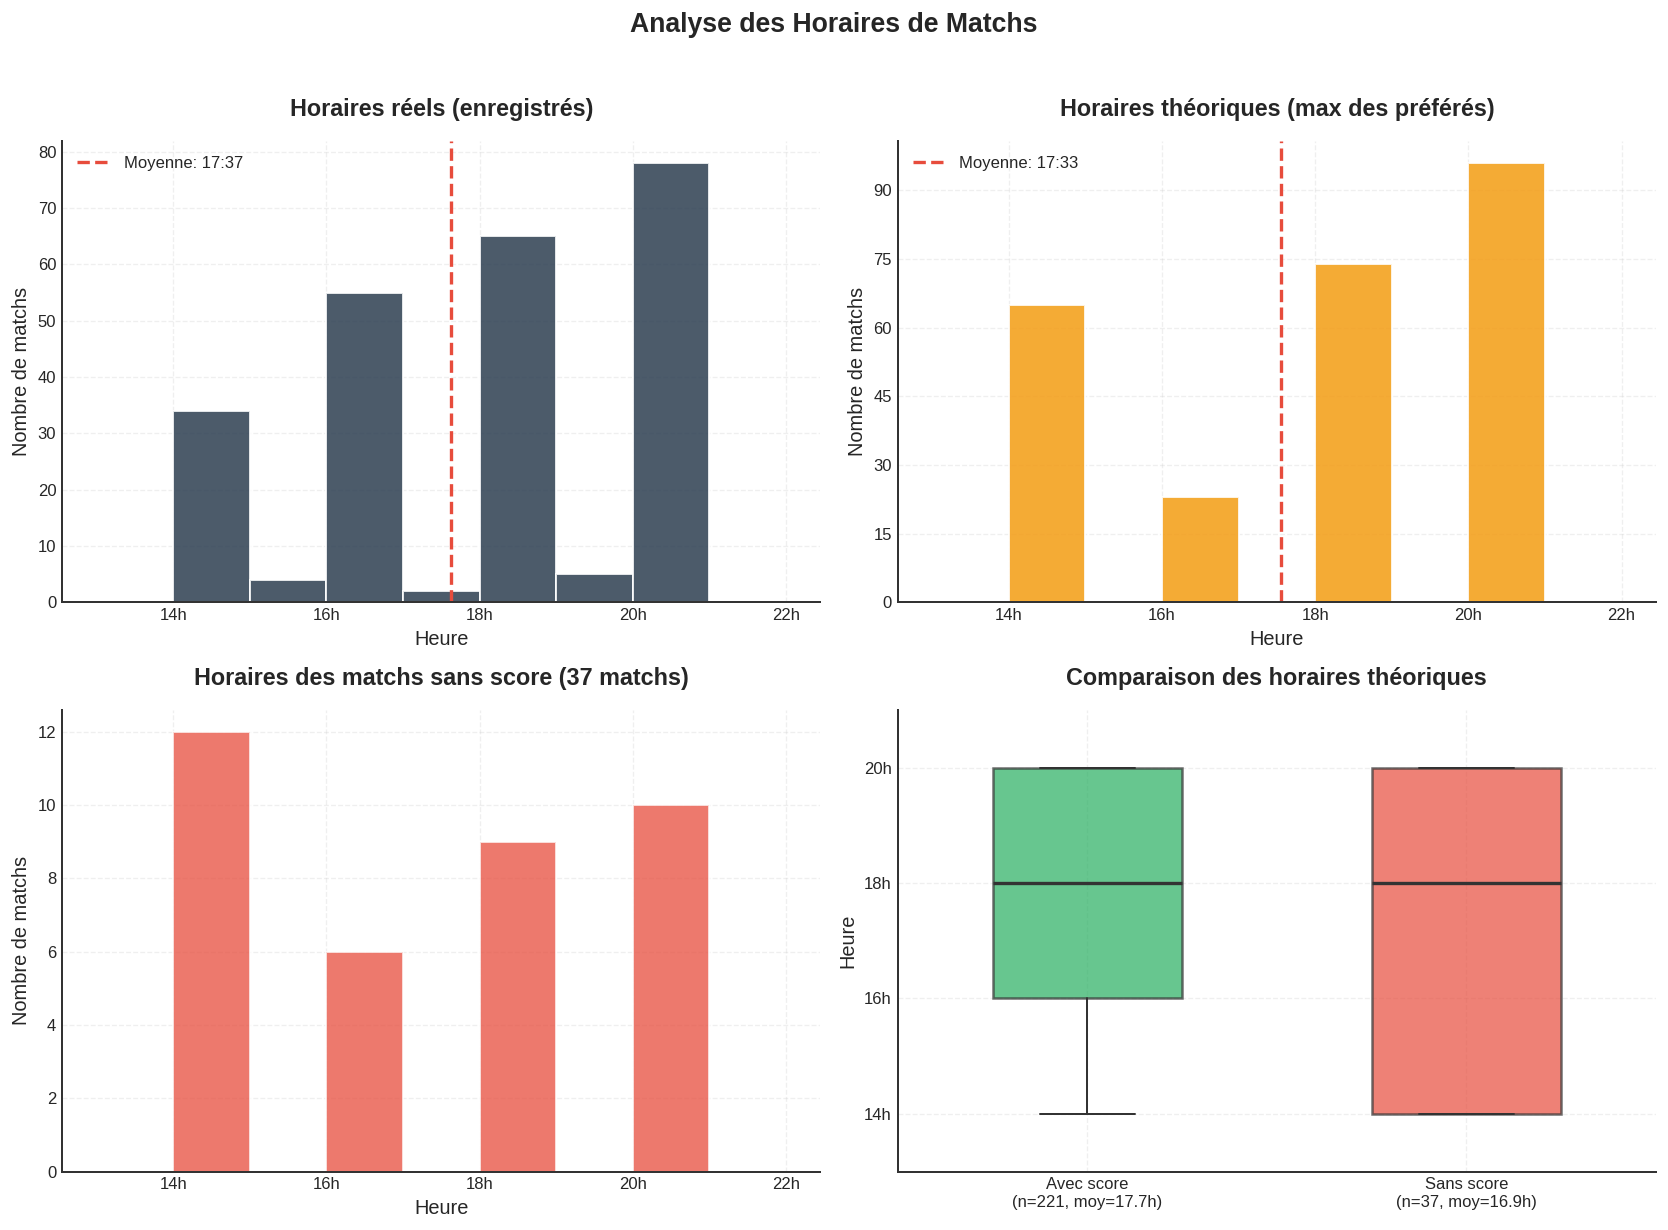


📊 STATISTIQUES DES HORAIRES:
   Horaires réels     │ Moyenne: 17:37 │ Min: 14:00 │ Max: 20:30
   Horaires théoriques │ Moyenne: 17:33 │ Min: 14:00 │ Max: 20:00


In [11]:
# ============================================================================
# DISTRIBUTION DES HORAIRES
# Correction des problèmes d'alignement
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analyse des Horaires de Matchs', fontsize=16, fontweight='bold', y=1.02)

# Préparation des données
horaires_reels = df['horaire_minutes'].dropna()
horaires_theoriques = df['horaire_theorique_min'].dropna()
matchs_non_joues = df[df['statut'].isin(['forfait', 'annulé', 'score_manquant', 'reporté'])]
matchs_joues = df[df['statut'] == 'joué']

# Configuration commune des bins
bins_heures = np.arange(13, 23)  # De 13h à 22h pour couvrir tout

# ─── Graphique 1: Distribution des horaires réels ───
ax = axes[0, 0]
if len(horaires_reels) > 0:
    n, bins, patches = ax.hist(horaires_reels / 60, bins=bins_heures, 
                                edgecolor='white', linewidth=1.2,
                                color=COLORS['primary'], alpha=0.85)
    
    mean_val = horaires_reels.mean() / 60
    ax.axvline(x=mean_val, color=COLORS['danger'], linestyle='--', linewidth=2,
               label=f'Moyenne: {minutes_to_time_str(int(horaires_reels.mean()))}')
    ax.legend(loc='upper left', framealpha=0.9)
    ax.set_xticks([14, 16, 18, 20, 22])
    ax.set_xticklabels(['14h', '16h', '18h', '20h', '22h'])
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    
style_axis(ax, title='Horaires réels (enregistrés)', 
           xlabel='Heure', ylabel='Nombre de matchs', integer_y=True)

# ─── Graphique 2: Distribution des horaires théoriques ───
ax = axes[0, 1]
if len(horaires_theoriques) > 0:
    n, bins, patches = ax.hist(horaires_theoriques / 60, bins=bins_heures, 
                                edgecolor='white', linewidth=1.2,
                                color=COLORS['warning'], alpha=0.85)
    
    mean_val = horaires_theoriques.mean() / 60
    ax.axvline(x=mean_val, color=COLORS['danger'], linestyle='--', linewidth=2,
               label=f'Moyenne: {minutes_to_time_str(int(horaires_theoriques.mean()))}')
    ax.legend(loc='upper left', framealpha=0.9)
    ax.set_xticks([14, 16, 18, 20, 22])
    ax.set_xticklabels(['14h', '16h', '18h', '20h', '22h'])
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

style_axis(ax, title='Horaires théoriques (max des préférés)', 
           xlabel='Heure', ylabel='Nombre de matchs', integer_y=True)

# ─── Graphique 3: Horaires des matchs SANS SCORE (pas "non joués") ───
matchs_sans_score = df[~df['has_score']]
horaires_sans_score = matchs_sans_score['horaire_theorique_min'].dropna()
ax = axes[1, 0]
if len(horaires_sans_score) > 0:
    n, bins, patches = ax.hist(horaires_sans_score / 60, bins=bins_heures, 
                                edgecolor='white', linewidth=1.2,
                                color=COLORS['danger'], alpha=0.75)
    ax.set_xticks([14, 16, 18, 20, 22])
    ax.set_xticklabels(['14h', '16h', '18h', '20h', '22h'])
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

style_axis(ax, title=f'Horaires des matchs sans score ({len(matchs_sans_score)} matchs)', 
           xlabel='Heure', ylabel='Nombre de matchs', integer_y=True)

# ─── Graphique 4: Comparaison horaires matchs avec score vs sans score ───
ax = axes[1, 1]
h_avec_score = df[df['has_score']]['horaire_theorique_min'].dropna() / 60
h_sans_score = matchs_sans_score['horaire_theorique_min'].dropna() / 60

data_to_plot = []
labels = []
colors_box = []

if len(h_avec_score) > 0:
    data_to_plot.append(h_avec_score)
    labels.append(f'Avec score\n(n={len(h_avec_score)}, moy={h_avec_score.mean():.1f}h)')
    colors_box.append(COLORS['success'])

if len(h_sans_score) > 0:
    data_to_plot.append(h_sans_score)
    labels.append(f'Sans score\n(n={len(h_sans_score)}, moy={h_sans_score.mean():.1f}h)')
    colors_box.append(COLORS['danger'])

if data_to_plot:
    bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, 
                    widths=0.5, notch=False)
    
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor('#333333')
        patch.set_linewidth(1.5)
    
    for whisker in bp['whiskers']:
        whisker.set_color('#333333')
        whisker.set_linewidth(1.2)
    for cap in bp['caps']:
        cap.set_color('#333333')
        cap.set_linewidth(1.2)
    for median in bp['medians']:
        median.set_color('#333333')
        median.set_linewidth(2)
    
    # Forcer les ticks entiers alignés
    ax.set_yticks([14, 16, 18, 20])
    ax.set_yticklabels(['14h', '16h', '18h', '20h'])
    ax.set_ylim(13, 21)

style_axis(ax, title='Comparaison des horaires théoriques', ylabel='Heure')

plt.tight_layout()
smart_show_individual("Distribution_horaires")

# Statistiques textuelles
print("\n📊 STATISTIQUES DES HORAIRES:")
if len(horaires_reels) > 0:
    print(f"   Horaires réels     │ Moyenne: {minutes_to_time_str(int(horaires_reels.mean()))} │ "
          f"Min: {minutes_to_time_str(int(horaires_reels.min()))} │ Max: {minutes_to_time_str(int(horaires_reels.max()))}")
if len(horaires_theoriques) > 0:
    print(f"   Horaires théoriques │ Moyenne: {minutes_to_time_str(int(horaires_theoriques.mean()))} │ "
          f"Min: {minutes_to_time_str(int(horaires_theoriques.min()))} │ Max: {minutes_to_time_str(int(horaires_theoriques.max()))}")

## 8. 📅 Distribution par semaine

   💾 Sauvegardé: 12_Analyse_semaine_Nombre_total_de_matchs_par_semaine.png
   💾 Sauvegardé: 13_Analyse_semaine_Matchs_par_semaine_par_statut.png
   💾 Sauvegardé: 13_Analyse_semaine_Matchs_par_semaine_par_statut.png
   💾 Sauvegardé: 14_Analyse_semaine_Taux_de_matchs_joués_par_semaine.png
   💾 Sauvegardé: 14_Analyse_semaine_Taux_de_matchs_joués_par_semaine.png
   💾 Sauvegardé: 15_Analyse_semaine_Cumul_des_matchs_joués.png
   💾 Sauvegardé: 15_Analyse_semaine_Cumul_des_matchs_joués.png


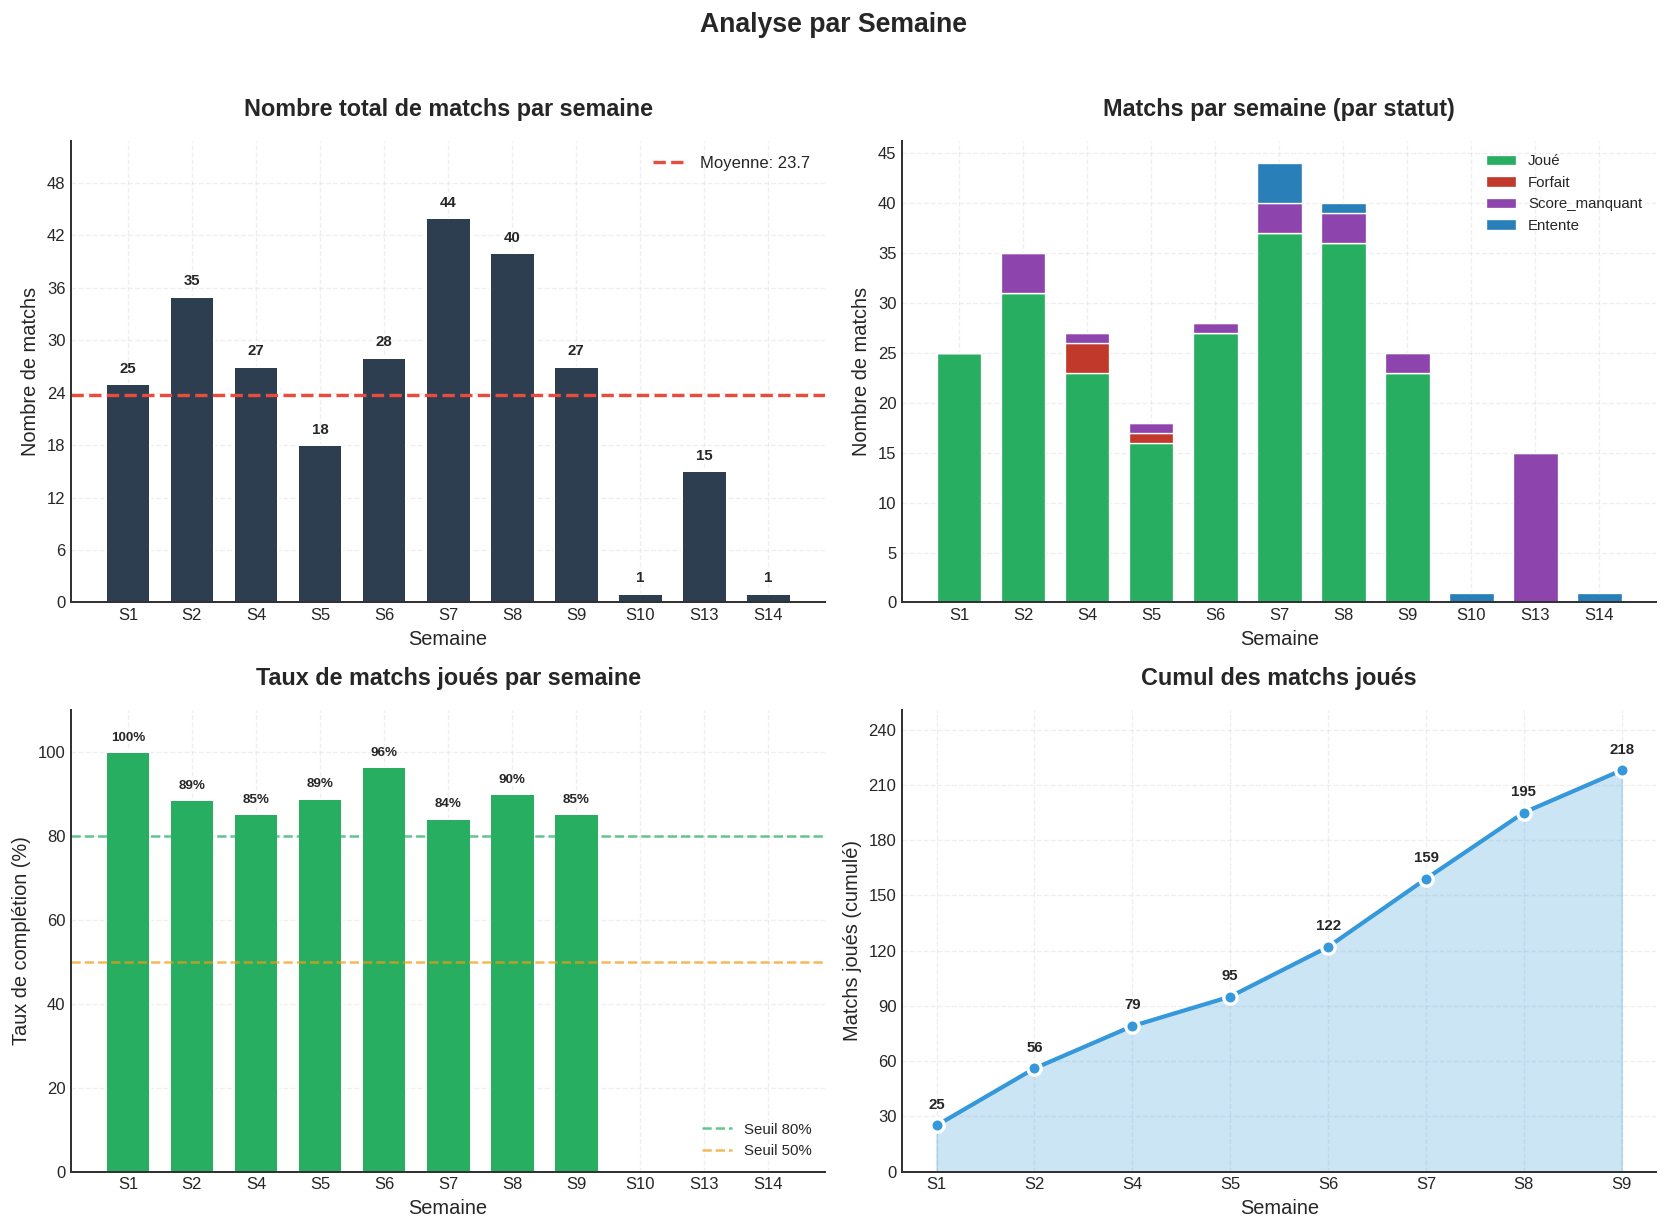


📊 STATISTIQUES PAR SEMAINE:
   Semaines avec matchs    : 11
   Matchs par semaine (moy): 23.7
   Semaine la plus chargée : S7 (44 matchs)
   Semaine la moins chargée: S10 (1 matchs)


In [12]:
# ============================================================================
# DISTRIBUTION PAR SEMAINE
# ============================================================================

# Convertir les semaines en numérique
df['semaine_num'] = pd.to_numeric(df['Semaine'], errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analyse par Semaine', fontsize=16, fontweight='bold', y=1.02)

# Données communes
semaine_counts = df.groupby('semaine_num').size().sort_index()
semaines_uniques = sorted(df['semaine_num'].dropna().unique().astype(int))

# ─── Graphique 1: Nombre total de matchs par semaine ───
if len(semaine_counts) > 0:
    x_pos = np.arange(len(semaine_counts))
    bars = axes[0, 0].bar(x_pos, semaine_counts.values, 
                          color=COLORS['primary'], edgecolor='white', linewidth=1.2, width=0.7)
    axes[0, 0].set_xticks(x_pos)
    axes[0, 0].set_xticklabels([f'S{int(s)}' for s in semaine_counts.index])
    
    avg = semaine_counts.mean()
    axes[0, 0].axhline(y=avg, color=COLORS['danger'], linestyle='--', linewidth=2, 
                       label=f'Moyenne: {avg:.1f}')
    axes[0, 0].legend(loc='upper right', framealpha=0.9)
    add_value_labels(axes[0, 0], bars, fontsize=9)
    axes[0, 0].set_ylim(0, semaine_counts.max() * 1.2)

style_axis(axes[0, 0], title='Nombre total de matchs par semaine', 
           xlabel='Semaine', ylabel='Nombre de matchs', integer_y=True)

# ─── Graphique 2: Matchs par semaine selon le statut ───
semaine_statut = df.groupby(['semaine_num', 'statut']).size().unstack(fill_value=0)
if len(semaine_statut) > 0:
    statuts_order = ['joué', 'forfait', 'score_manquant', 'entente']
    cols_present = [s for s in statuts_order if s in semaine_statut.columns]
    
    x_pos = np.arange(len(semaine_statut))
    bottom = np.zeros(len(semaine_statut))
    
    for statut in cols_present:
        if statut in semaine_statut.columns:
            bars = axes[0, 1].bar(x_pos, semaine_statut[statut], 
                                  bottom=bottom, label=statut.capitalize(), 
                                  color=COLORS.get(statut, 'gray'),
                                  edgecolor='white', linewidth=0.8, width=0.7)
            bottom += semaine_statut[statut].values
    
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels([f'S{int(s)}' for s in semaine_statut.index])
    axes[0, 1].legend(loc='upper right', fontsize=9, framealpha=0.9)

style_axis(axes[0, 1], title='Matchs par semaine (par statut)', 
           xlabel='Semaine', ylabel='Nombre de matchs', integer_y=True)

# ─── Graphique 3: Taux de complétion par semaine ───
def calc_completion_rate(group):
    total = len(group)
    joues = len(group[group['statut'] == 'joué'])
    return (joues / total * 100) if total > 0 else 0

completion_by_week = df.groupby('semaine_num').apply(calc_completion_rate)
if len(completion_by_week) > 0:
    x_pos = np.arange(len(completion_by_week))
    colors_completion = [COLORS['success'] if r >= 80 else COLORS['warning'] if r >= 50 else COLORS['danger'] 
                        for r in completion_by_week.values]
    bars = axes[1, 0].bar(x_pos, completion_by_week.values, 
                          color=colors_completion, edgecolor='white', linewidth=1.2, width=0.7)
    
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels([f'S{int(s)}' for s in completion_by_week.index])
    axes[1, 0].set_ylim(0, 110)
    axes[1, 0].axhline(y=80, color=COLORS['success'], linestyle='--', linewidth=1.5, alpha=0.7, label='Seuil 80%')
    axes[1, 0].axhline(y=50, color=COLORS['warning'], linestyle='--', linewidth=1.5, alpha=0.7, label='Seuil 50%')
    axes[1, 0].legend(loc='lower right', fontsize=9, framealpha=0.9)
    
    # Ajouter les pourcentages
    for bar, val in zip(bars, completion_by_week.values):
        if val > 0:
            axes[1, 0].annotate(f'{val:.0f}%', 
                               xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                               xytext=(0, 5), textcoords='offset points',
                               ha='center', va='bottom', fontsize=8, fontweight='bold')

style_axis(axes[1, 0], title='Taux de matchs joués par semaine', 
           xlabel='Semaine', ylabel='Taux de complétion (%)')

# ─── Graphique 4: Cumul des matchs joués ───
matchs_joues_par_semaine = df[df['statut'] == 'joué'].groupby('semaine_num').size()
if len(matchs_joues_par_semaine) > 0:
    matchs_joues_par_semaine = matchs_joues_par_semaine.sort_index()
    cumsum = matchs_joues_par_semaine.cumsum()
    
    x_pos = np.arange(len(cumsum))
    axes[1, 1].fill_between(x_pos, cumsum.values, alpha=0.25, color=COLORS['accent'])
    axes[1, 1].plot(x_pos, cumsum.values, 'o-', color=COLORS['accent'], 
                    linewidth=2.5, markersize=8, markeredgecolor='white', markeredgewidth=2)
    
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels([f'S{int(s)}' for s in cumsum.index])
    
    # Ajouter les valeurs
    for i, (x, y) in enumerate(zip(x_pos, cumsum.values)):
        axes[1, 1].annotate(f'{int(y)}', (x, y), textcoords="offset points", 
                           xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
    
    axes[1, 1].set_ylim(0, cumsum.max() * 1.15)

style_axis(axes[1, 1], title='Cumul des matchs joués', 
           xlabel='Semaine', ylabel='Matchs joués (cumulé)', integer_y=True)

plt.tight_layout()
smart_show_individual("Analyse_semaine")

# Résumé statistique
print("\n📊 STATISTIQUES PAR SEMAINE:")
print(f"   Semaines avec matchs    : {df['semaine_num'].nunique()}")
print(f"   Matchs par semaine (moy): {semaine_counts.mean():.1f}")
print(f"   Semaine la plus chargée : S{int(semaine_counts.idxmax())} ({int(semaine_counts.max())} matchs)")
print(f"   Semaine la moins chargée: S{int(semaine_counts.idxmin())} ({int(semaine_counts.min())} matchs)")

## 9. 🏟️ Statistiques par gymnase

   💾 Sauvegardé: 16_Analyse_gymnase_Top_12_-_Gymnases_les_plus_utilisés.png
   💾 Sauvegardé: 17_Analyse_gymnase_Top_10_gymnases_-_Statuts_S1_à_S11.png
   💾 Sauvegardé: 17_Analyse_gymnase_Top_10_gymnases_-_Statuts_S1_à_S11.png
   💾 Sauvegardé: 18_Analyse_gymnase_Taux_de_matchs_avec_score_par_gymnase_S1_à_S11.png
   💾 Sauvegardé: 18_Analyse_gymnase_Taux_de_matchs_avec_score_par_gymnase_S1_à_S11.png
   💾 Sauvegardé: 19_Analyse_gymnase_Horaires_normalisés_par_gymnase_top_8.png
   💾 Sauvegardé: 19_Analyse_gymnase_Horaires_normalisés_par_gymnase_top_8.png


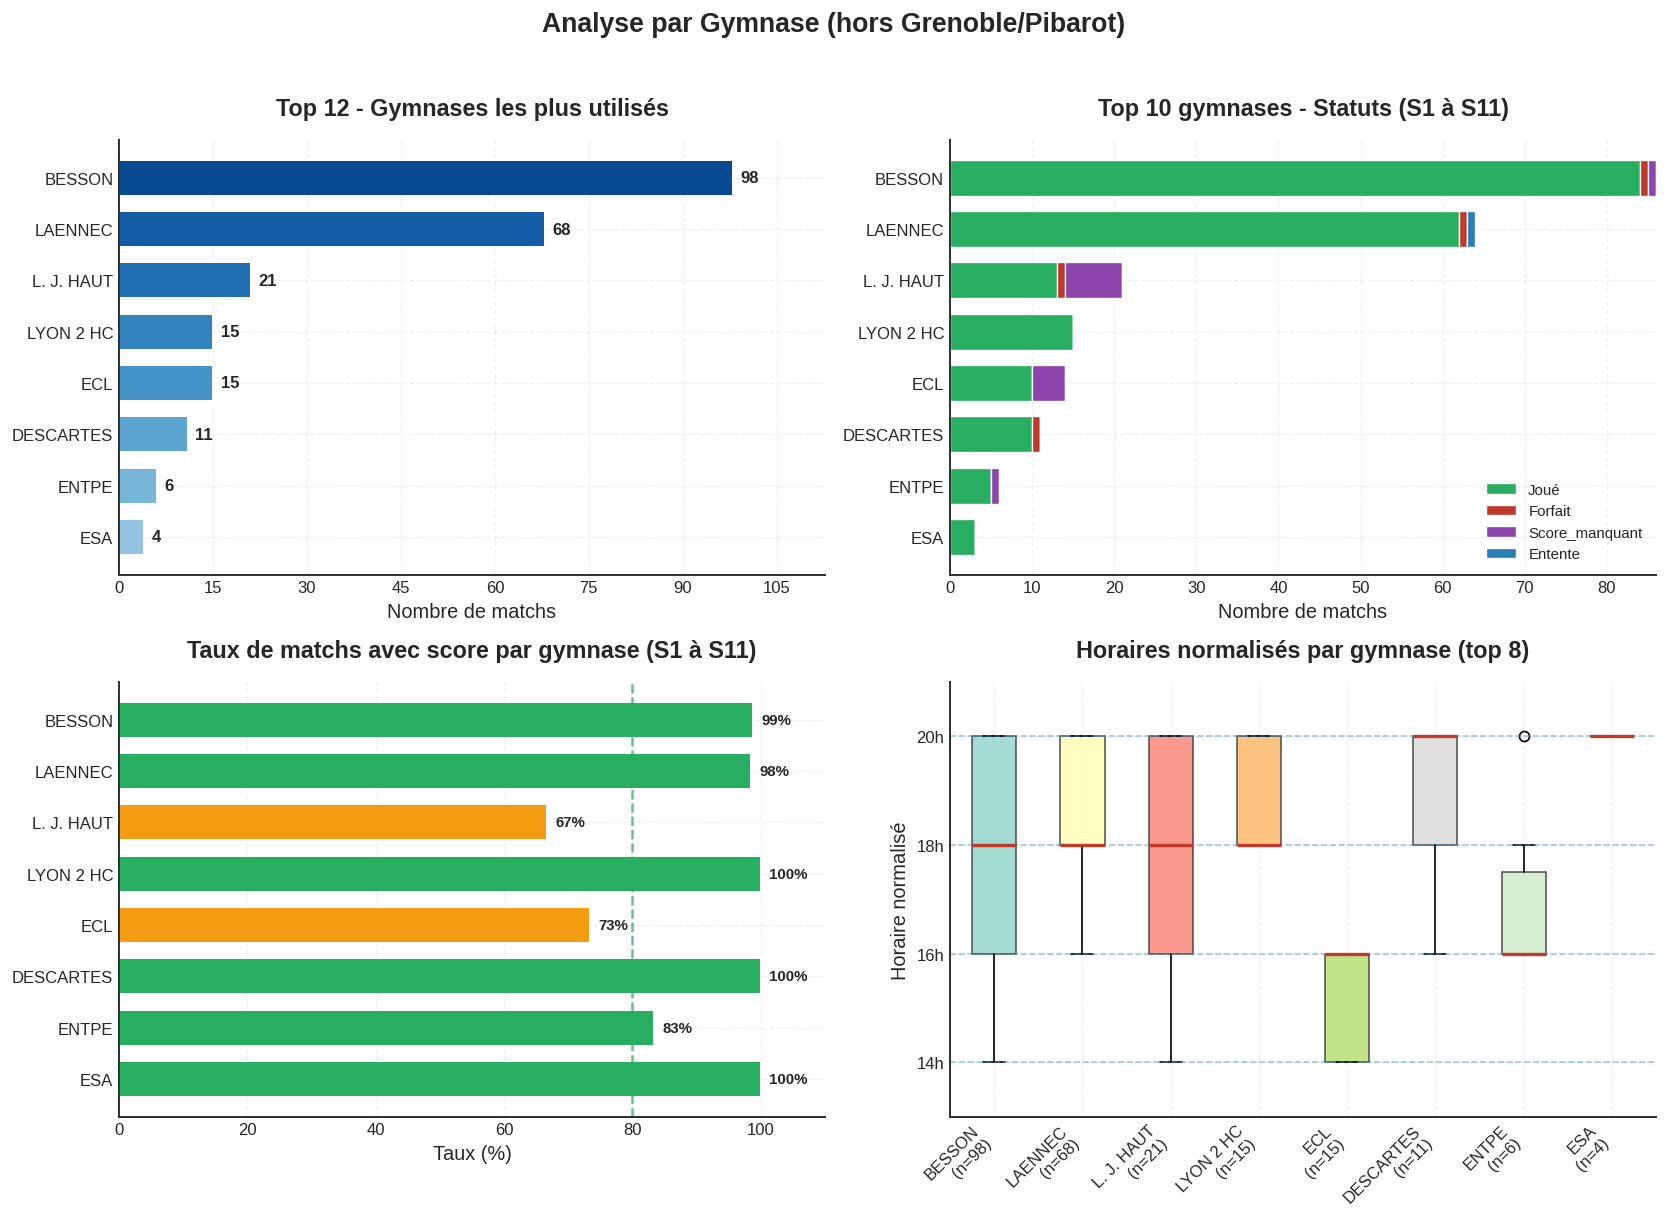


🏟️ STATISTIQUES DES GYMNASES (hors Grenoble/Pibarot):
   Nombre total de gymnases : 8
   Gymnase le plus utilisé  : BESSON (98 matchs)
   Matchs sans gymnase/entente : 0


In [13]:
# ============================================================================
# STATISTIQUES PAR GYMNASE
# EXCLUSION: Grenoble et Pibarot (non pertinents)
# FILTRAGE: Matchs avant S12 pour le statut (S13 pas encore passée)
# ============================================================================

# Liste des gymnases à exclure
GYMNASES_EXCLUS = ['GRENOBLE', 'PIBAROT']

# Filtrer les matchs avec gymnase (exclure les ententes sans gymnase ET les gymnases exclus)
df_with_gym = df[df['Gymnase'].notna() & 
                 (df['Gymnase'].astype(str).str.strip() != '') & 
                 (df['Gymnase'].astype(str).str.upper() != 'ENTENTE') &
                 (~df['Gymnase'].astype(str).str.upper().isin(GYMNASES_EXCLUS))]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analyse par Gymnase (hors Grenoble/Pibarot)', fontsize=16, fontweight='bold', y=1.02)

# ─── Graphique 1: Nombre de matchs par gymnase ───
gym_counts = df_with_gym['Gymnase'].value_counts().head(12)
if len(gym_counts) > 0:
    y_pos = np.arange(len(gym_counts))
    colors_gradient = plt.cm.Blues(np.linspace(0.4, 0.9, len(gym_counts)))[::-1]
    
    bars = axes[0, 0].barh(y_pos, gym_counts.values, color=colors_gradient, 
                           edgecolor='white', linewidth=1.2, height=0.7)
    axes[0, 0].set_yticks(y_pos)
    axes[0, 0].set_yticklabels(gym_counts.index)
    axes[0, 0].invert_yaxis()
    add_value_labels_h(axes[0, 0], bars, fontsize=10)
    axes[0, 0].set_xlim(0, gym_counts.max() * 1.15)

style_axis(axes[0, 0], title='Top 12 - Gymnases les plus utilisés', 
           xlabel='Nombre de matchs', integer_x=True)

# ─── Graphique 2: Statuts par gymnase (top 10) - MATCHS AVANT S12 UNIQUEMENT ───
# Filtrer pour ne prendre que les matchs avant la semaine 12
df_avant_s12 = df_with_gym[df_with_gym['semaine_num'] < 12]

top_gyms = df_avant_s12['Gymnase'].value_counts().head(10).index
df_top_gyms = df_avant_s12[df_avant_s12['Gymnase'].isin(top_gyms)]
gym_statut = df_top_gyms.groupby(['Gymnase', 'statut']).size().unstack(fill_value=0)

if len(gym_statut) > 0:
    gym_statut = gym_statut.reindex(top_gyms)
    statuts_order = ['joué', 'forfait', 'score_manquant', 'entente']
    cols_in_data = [c for c in statuts_order if c in gym_statut.columns]
    gym_statut_filtered = gym_statut[cols_in_data] if cols_in_data else gym_statut
    
    y_pos = np.arange(len(gym_statut_filtered))
    left = np.zeros(len(gym_statut_filtered))
    
    for statut in cols_in_data:
        color = COLORS.get(statut, 'gray')
        bars = axes[0, 1].barh(y_pos, gym_statut_filtered[statut], left=left,
                               color=color, edgecolor='white', linewidth=0.8,
                               label=statut.capitalize(), height=0.7)
        left += gym_statut_filtered[statut].values
    
    axes[0, 1].set_yticks(y_pos)
    axes[0, 1].set_yticklabels(gym_statut_filtered.index)
    axes[0, 1].invert_yaxis()
    axes[0, 1].legend(loc='lower right', fontsize=9, framealpha=0.9)

style_axis(axes[0, 1], title='Top 10 gymnases - Statuts (S1 à S11)', 
           xlabel='Nombre de matchs', integer_x=True)

# ─── Graphique 3: Taux de matchs avec score par gymnase (avant S12) ───
def calc_gym_score_rate(gym_df):
    """Calcule le taux de matchs avec score enregistré."""
    total = len(gym_df)
    avec_score = gym_df['has_score'].sum()
    return (avec_score / total * 100) if total > 0 else 0

gym_completion = df_avant_s12.groupby('Gymnase').apply(calc_gym_score_rate)
gym_completion = gym_completion.reindex(gym_counts.head(12).index).dropna()

if len(gym_completion) > 0:
    y_pos = np.arange(len(gym_completion))
    completion_colors = [COLORS['success'] if r >= 80 else COLORS['warning'] if r >= 50 else COLORS['danger'] 
                         for r in gym_completion.values]
    bars = axes[1, 0].barh(y_pos, gym_completion.values, 
                           color=completion_colors, edgecolor='white', linewidth=1.2, height=0.7)
    axes[1, 0].set_yticks(y_pos)
    axes[1, 0].set_yticklabels(gym_completion.index)
    axes[1, 0].invert_yaxis()
    axes[1, 0].set_xlim(0, 110)
    axes[1, 0].axvline(x=80, color=COLORS['success'], linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Ajouter les pourcentages
    for bar, val in zip(bars, gym_completion.values):
        axes[1, 0].annotate(f'{val:.0f}%', 
                           xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                           xytext=(5, 0), textcoords='offset points',
                           ha='left', va='center', fontsize=9, fontweight='bold')

style_axis(axes[1, 0], title='Taux de matchs avec score par gymnase (S1 à S11)', xlabel='Taux (%)')

# ─── Graphique 4: Boxplot des horaires normalisés par gymnase (top 8) ───
top_8_gyms = gym_counts.head(8).index

# Préparer les données pour le boxplot avec horaires normalisés
data_boxplot_gym = []
labels_gym = []
for gym in top_8_gyms:
    gym_data = df_with_gym[df_with_gym['Gymnase'] == gym]['horaire_normalise_h'].dropna()
    if len(gym_data) > 0:
        data_boxplot_gym.append(gym_data.values)
        label = str(gym)[:15] + '...' if len(str(gym)) > 15 else str(gym)
        labels_gym.append(f"{label}\n(n={len(gym_data)})")

if data_boxplot_gym:
    bp = axes[1, 1].boxplot(data_boxplot_gym, labels=labels_gym, patch_artist=True, vert=True)
    colors_bp = plt.cm.Set3(np.linspace(0, 1, len(data_boxplot_gym)))
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        patch.set_edgecolor('#333')
    for median in bp['medians']:
        median.set_color('#c0392b')
        median.set_linewidth(2)
    
    # Ajouter les lignes des horaires standards
    for h in HORAIRES_STANDARDS:
        axes[1, 1].axhline(y=h, color='#3498db', linestyle='--', alpha=0.5, linewidth=1)
    
    axes[1, 1].set_yticks(HORAIRES_STANDARDS)
    axes[1, 1].set_yticklabels([f'{h}h' for h in HORAIRES_STANDARDS])
    axes[1, 1].set_ylim(HORAIRES_STANDARDS[0] - 1, HORAIRES_STANDARDS[-1] + 1)
    plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

style_axis(axes[1, 1], title='Horaires normalisés par gymnase (top 8)', 
           xlabel='', ylabel='Horaire normalisé')

plt.tight_layout()
smart_show_individual("Analyse_gymnase")

# Résumé statistique
print("\n🏟️ STATISTIQUES DES GYMNASES (hors Grenoble/Pibarot):")
print(f"   Nombre total de gymnases : {df_with_gym['Gymnase'].nunique()}")
print(f"   Gymnase le plus utilisé  : {gym_counts.index[0]} ({gym_counts.values[0]} matchs)")
print(f"   Matchs sans gymnase/entente : {len(df[df['Gymnase'].isna() | (df['Gymnase'].astype(str).str.strip() == '')])}")

## 10. 👥 Statistiques par équipe - Nombre de matchs joués

📋 Équipes du championnat académique: 78
   💾 Sauvegardé: 20_Equipes_academiques_Distribution_des_matchs_joués_par_équipe.png
   💾 Sauvegardé: 21_Equipes_academiques_Top_15_-_Équipes_les_plus_actives.png
   💾 Sauvegardé: 22_Equipes_academiques_Bottom_15_-_Équipes_les_moins_actives.png
   💾 Sauvegardé: 23_Equipes_academiques_Distribution_des_matchs_joués_par_genre.png


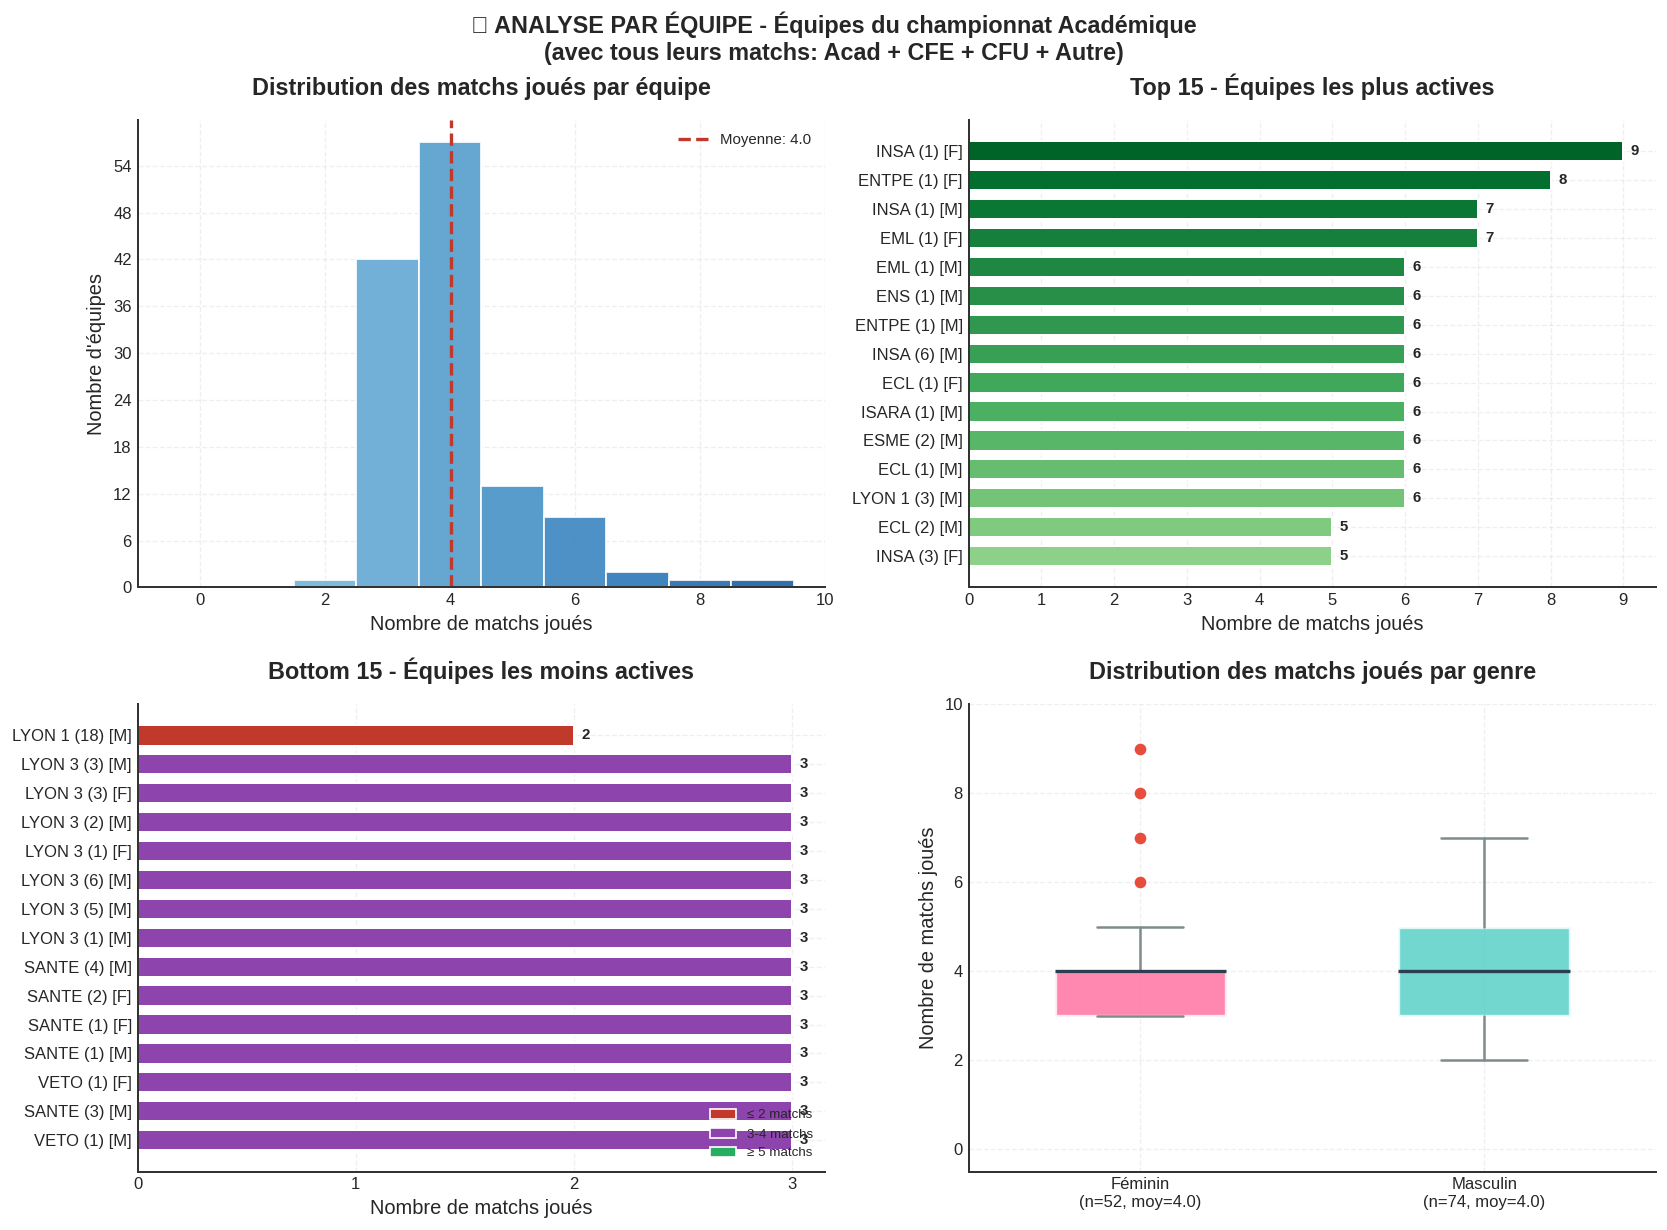


👥 STATISTIQUES PAR ÉQUIPE (Équipes du championnat Académique)
   📌 Nombre d'équipes Acad: 126
   📊 Matchs joués par équipe (moyenne): 4.0
   🏆 Équipe la plus active: INSA (1) [F] (9 matchs)
   📊 Matchs avec score enregistré: 434 participations (sur 506 total)


In [14]:
# ============================================================================
# COMPTAGE DES MATCHS PAR ÉQUIPE
# ÉQUIPES DU CHAMPIONNAT ACADÉMIQUE (via df_equipes)
# MAIS AVEC TOUS LEURS MATCHS (Acad, CFE, CFU, Autre)
# ============================================================================

# Récupérer la liste des équipes du championnat académique depuis df_equipes
equipes_acad = set()
if 'Equipe' in df_equipes.columns:
    for _, row in df_equipes.iterrows():
        equipe = row.get('Equipe')
        if pd.notna(equipe):
            equipe_str = str(equipe).strip()
            equipes_acad.add(equipe_str)
            # Ajouter aussi la version sans numéro entre parenthèses si nécessaire
            # Ex: "LYON 1 (5)" -> "LYON 1 (5)"

print(f"📋 Équipes du championnat académique: {len(equipes_acad)}")

# Compteurs pour les équipes (TOUS les matchs)
equipe_matchs_joues = Counter()       # Tous les matchs joués (= dans Matchs_Fixes)
equipe_matchs_avec_score = Counter()  # Matchs avec un score enregistré

for _, row in df.iterrows():
    eq1_raw = row.get('Equipe_1')
    eq2_raw = row.get('Equipe_2')
    genre = row.get('Genre')
    has_score = row.get('has_score', False)
    
    # Vérifier si l'équipe est dans le championnat académique
    eq1_str = str(eq1_raw).strip() if pd.notna(eq1_raw) else ''
    eq2_str = str(eq2_raw).strip() if pd.notna(eq2_raw) else ''
    
    eq1_in_acad = eq1_str in equipes_acad
    eq2_in_acad = eq2_str in equipes_acad
    
    # Construire les clés avec genre
    eq1_key = get_equipe_key(eq1_raw, genre) if eq1_in_acad else None
    eq2_key = get_equipe_key(eq2_raw, genre) if eq2_in_acad else None
    
    # Compter les matchs pour les équipes Acad
    if eq1_key:
        equipe_matchs_joues[eq1_key] += 1
        if has_score:
            equipe_matchs_avec_score[eq1_key] += 1
    
    if eq2_key:
        equipe_matchs_joues[eq2_key] += 1
        if has_score:
            equipe_matchs_avec_score[eq2_key] += 1

# Créer un DataFrame des statistiques par équipe
equipes_list = sorted(set(equipe_matchs_joues.keys()))
stats_equipes = pd.DataFrame({
    'Equipe': equipes_list,
    'Matchs_Joues': [equipe_matchs_joues[e] for e in equipes_list],
    'Matchs_Avec_Score': [equipe_matchs_avec_score[e] for e in equipes_list],
})
stats_equipes['Taux_Score'] = (stats_equipes['Matchs_Avec_Score'] / stats_equipes['Matchs_Joues'] * 100).round(1)
stats_equipes = stats_equipes.sort_values('Matchs_Joues', ascending=False)

# Garder aussi matchs_disputes_vals pour compatibilité avec le reste du notebook
matchs_disputes_vals = list(equipe_matchs_joues.values())

# === GRAPHIQUES ÉQUIPES ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("📊 ANALYSE PAR ÉQUIPE - Équipes du championnat Académique\n(avec tous leurs matchs: Acad + CFE + CFU + Autre)", fontsize=14, fontweight='bold', y=1.02)

# --- Graphique 1: Distribution du nombre de matchs joués par équipe ---
ax = axes[0, 0]
matchs_joues_vals = list(equipe_matchs_joues.values())
if matchs_joues_vals:
    max_matchs = max(matchs_joues_vals)
    bins = np.arange(0, max_matchs + 2) - 0.5  # Centrer les barres sur les entiers
    n, bin_edges, patches = ax.hist(matchs_joues_vals, bins=bins, 
                                     edgecolor='white', linewidth=1.2, 
                                     color=COLORS['joué'], alpha=0.85)
    for i, patch in enumerate(patches):
        patch.set_facecolor(plt.cm.Blues(0.4 + 0.5 * (i / max(len(patches), 1))))
    
    mean_val = np.mean(matchs_joues_vals)
    ax.axvline(x=mean_val, color=COLORS['forfait'], linestyle='--', linewidth=2,
               label=f'Moyenne: {mean_val:.1f}')
    ax.legend(loc='upper right', fontsize=9)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    style_axis(ax, 'Nombre de matchs joués', "Nombre d'équipes", 
               'Distribution des matchs joués par équipe', integer_x=True, integer_y=True)

# --- Graphique 2: Top 15 équipes les plus actives ---
ax = axes[0, 1]
top_equipes = stats_equipes.head(15)
if len(top_equipes) > 0:
    y_pos = np.arange(len(top_equipes))
    values = top_equipes['Matchs_Joues'].values
    colors_gradient = [plt.cm.Greens(0.4 + 0.5 * (1 - i / len(top_equipes))) for i in range(len(top_equipes))]
    bars = ax.barh(y_pos, values, color=colors_gradient, edgecolor='white', linewidth=1.2, height=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_equipes['Equipe'].values, fontsize=9)
    ax.invert_yaxis()
    add_value_labels_h(ax, bars, fontsize=9)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    style_axis(ax, 'Nombre de matchs joués', '', 'Top 15 - Équipes les plus actives', integer_x=True)

# --- Graphique 3: Équipes avec le moins de matchs joués ---
ax = axes[1, 0]
bottom_equipes = stats_equipes.tail(15).sort_values('Matchs_Joues', ascending=True)
if len(bottom_equipes) > 0:
    y_pos = np.arange(len(bottom_equipes))
    values = bottom_equipes['Matchs_Joues'].values
    colors_cond = []
    for m in values:
        if m <= 2:
            colors_cond.append(COLORS['forfait'])
        elif m <= 4:
            colors_cond.append(COLORS['score_manquant'])
        else:
            colors_cond.append(COLORS['joué'])
    
    bars = ax.barh(y_pos, values, color=colors_cond, edgecolor='white', linewidth=1.2, height=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(bottom_equipes['Equipe'].values, fontsize=9)
    ax.invert_yaxis()
    add_value_labels_h(ax, bars, fontsize=9)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    style_axis(ax, 'Nombre de matchs joués', '', 'Bottom 15 - Équipes les moins actives', integer_x=True)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=COLORS['forfait'], edgecolor='white', label='≤ 2 matchs'),
        Patch(facecolor=COLORS['score_manquant'], edgecolor='white', label='3-4 matchs'),
        Patch(facecolor=COLORS['joué'], edgecolor='white', label='≥ 5 matchs')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

# --- Graphique 4: Boxplot du nombre de matchs joués par genre ---
ax = axes[1, 1]
equipes_f = [e for e in equipes_list if '[F]' in str(e)]
equipes_m = [e for e in equipes_list if '[M]' in str(e)]
matchs_f = [equipe_matchs_joues[e] for e in equipes_f]
matchs_m = [equipe_matchs_joues[e] for e in equipes_m]

data_boxplot = []
labels_boxplot = []
box_colors = []
if matchs_f:
    data_boxplot.append(matchs_f)
    labels_boxplot.append(f'Féminin\n(n={len(matchs_f)}, moy={np.mean(matchs_f):.1f})')
    box_colors.append('#ff6b9d')
if matchs_m:
    data_boxplot.append(matchs_m)
    labels_boxplot.append(f'Masculin\n(n={len(matchs_m)}, moy={np.mean(matchs_m):.1f})')
    box_colors.append('#4ecdc4')

if data_boxplot:
    bp = ax.boxplot(data_boxplot, labels=labels_boxplot, patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        patch.set_edgecolor('white')
        patch.set_linewidth(2)
    for median in bp['medians']:
        median.set_color('#2c3e50')
        median.set_linewidth(2)
    for whisker in bp['whiskers']:
        whisker.set_color('#7f8c8d')
        whisker.set_linewidth(1.5)
    for cap in bp['caps']:
        cap.set_color('#7f8c8d')
        cap.set_linewidth(1.5)
    for flier in bp['fliers']:
        flier.set_markerfacecolor('#e74c3c')
        flier.set_markeredgecolor('white')
        flier.set_markersize(8)
    
    # Forcer un axe Y avec entiers bien alignés
    all_vals = [v for d in data_boxplot for v in d]
    if all_vals:
        y_max = max(all_vals)
        y_min = 0
        ax.set_ylim(y_min - 0.5, y_max + 1)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    
    ax.set_title('Distribution des matchs joués par genre', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Nombre de matchs joués', fontsize=12, fontweight='medium')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
smart_show_individual("Equipes_academiques")

# Statistiques textuelles
print("\n" + "="*60)
print("👥 STATISTIQUES PAR ÉQUIPE (Équipes du championnat Académique)")
print("="*60)
print(f"   📌 Nombre d'équipes Acad: {len(equipes_list)}")
print(f"   📊 Matchs joués par équipe (moyenne): {np.mean(matchs_joues_vals):.1f}" if matchs_joues_vals else "")
if len(stats_equipes) > 0:
    print(f"   🏆 Équipe la plus active: {stats_equipes.iloc[0]['Equipe']} ({int(stats_equipes.iloc[0]['Matchs_Joues'])} matchs)")
print(f"   📊 Matchs avec score enregistré: {sum(equipe_matchs_avec_score.values())} participations (sur {sum(equipe_matchs_joues.values())} total)")

## 11. 🚫 Analyse des forfaits

🚫 ANALYSE DÉTAILLÉE DES FORFAITS

📌 Nombre total de forfaits: 6
   (détectés via remarques + scores atypiques comme 1-0, 2-1)

📊 SOURCES DE DÉTECTION:
   • Via remarques (mot 'forfait'):     4
   • Via scores atypiques (1-0, 2-1):   6
   💾 Sauvegardé: 24_Analyse_forfaits_Forfaits_par_semaine.png
   💾 Sauvegardé: 25_Analyse_forfaits_Forfaits_par_gymnase_top_10.png
   💾 Sauvegardé: 26_Analyse_forfaits_Distribution_horaire_des_forfaits.png
   💾 Sauvegardé: 27_Analyse_forfaits_Forfaits_par_poule_top_10.png


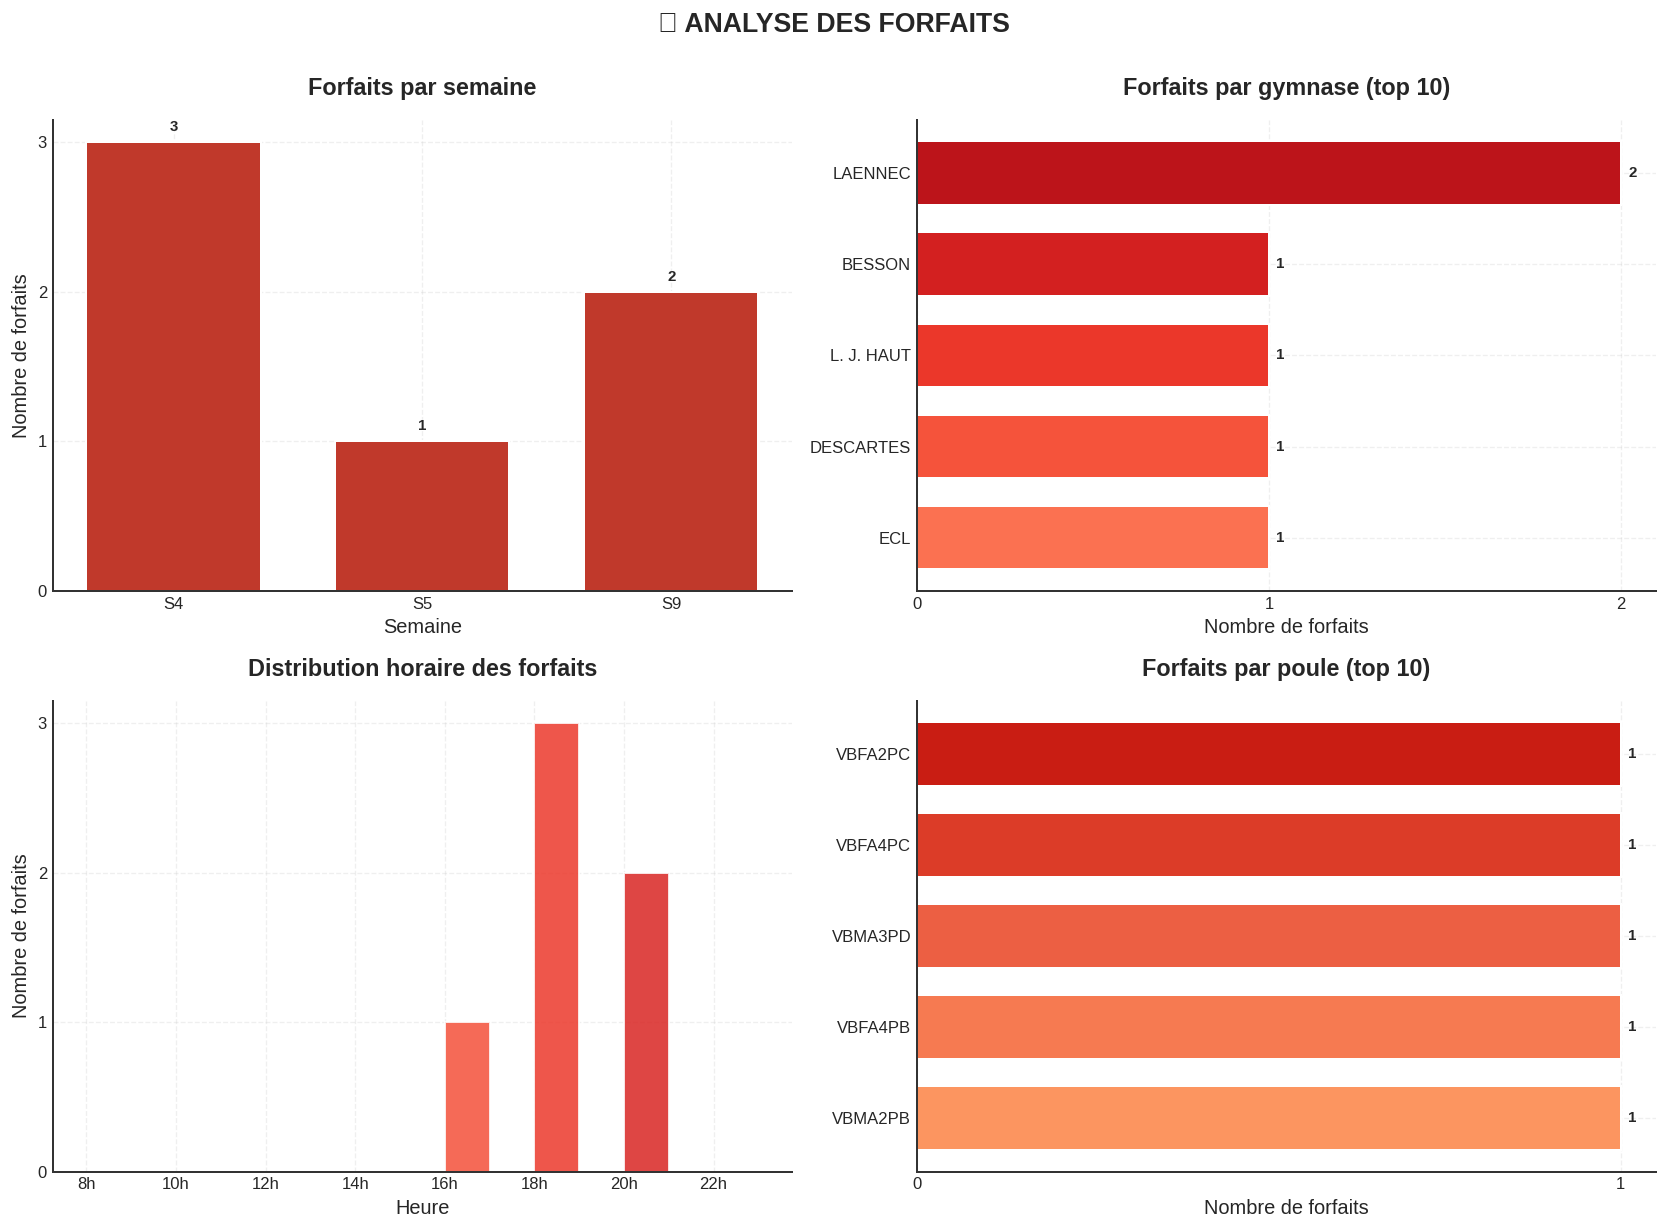


📋 LISTE DES MATCHS FORFAITS:


,Equipe_1,Equipe_2,Genre,Poule,Semaine,Score,Gymnase,Remarques
66,LYON 3 (2),VETO (1),F,VBFA2PC,4,2-1,BESSON,Importé J4 | J4.xlsx
71,LYON 3 (6),LYON 3 (5),F,VBFA4PC,4,1-2,LAENNEC,Importé J4 | J4.xlsx
83,LYON 1 (15),CATHO (1),M,VBMA3PD,4,0-1,L. J. HAUT,FORFAIT LYON 1 (15) - pas venue | Importé J4 |...
97,ESSCA (1),ENS (2),F,VBFA4PB,5,0-1,DESCARTES,FORFAIT equipe 1 le 13/11 à 10h56 | Importé J5...
224,ECAM (1),LYON 1 (9),F,NaN,9,0-1,LAENNEC,MATCH ANNULE FORFAIT ECAM le 11/12 à 8h17 | Im...
235,ISARA (1),ECL (2),M,VBMA2PB,9,0-1,ECL,MATCH ANNULE FORFAIT eq 1 le 10/12 à 14h33 | I...



📝 RAISONS DES FORFAITS (extraites des remarques):
   • (2x) Importé J4 | J4.xlsx
   • (1x) FORFAIT LYON 1 (15) - pas venue | Importé J4 | J4.xlsx
   • (1x) FORFAIT equipe 1 le 13/11 à 10h56 | Importé J5 | J5.xlsx
   • (1x) MATCH ANNULE FORFAIT ECAM le 11/12 à 8h17 | Importé J9 | J9.xlsx
   • (1x) MATCH ANNULE FORFAIT eq 1 le 10/12 à 14h33 | Importé J9 | J9.xlsx


In [15]:
# ============================================================================
# ANALYSE DES FORFAITS
# CORRECTION: Utiliser is_forfait pour inclure TOUS les forfaits
# (détectés via remarques OU via scores atypiques comme 1-0, 2-1)
# ============================================================================

df_forfaits = df_fixes[df_fixes['is_forfait']].copy()  # CORRECTION: utiliser df_fixes et is_forfait

print("=" * 60)
print("🚫 ANALYSE DÉTAILLÉE DES FORFAITS")
print("=" * 60)
print(f"\n📌 Nombre total de forfaits: {len(df_forfaits)}")
print("   (détectés via remarques + scores atypiques comme 1-0, 2-1)")

if len(df_forfaits) > 0:
    # Détail des sources de détection
    forfaits_remarques = df_forfaits['is_forfait_remarques'].sum()
    forfaits_score = df_forfaits['is_forfait_score'].sum()
    print(f"\n📊 SOURCES DE DÉTECTION:")
    print(f"   • Via remarques (mot 'forfait'):     {forfaits_remarques}")
    print(f"   • Via scores atypiques (1-0, 2-1):   {forfaits_score}")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("🚫 ANALYSE DES FORFAITS", fontsize=16, fontweight='bold', y=1.02)
    
    # --- Graphique 1: Forfaits par semaine ---
    ax = axes[0, 0]
    # Utiliser 'Semaine' si semaine_num n'existe pas
    col_semaine = 'semaine_num' if 'semaine_num' in df_forfaits.columns else 'Semaine'
    forfaits_semaine = df_forfaits.groupby(col_semaine).size().sort_index()
    if len(forfaits_semaine) > 0:
        x_pos = np.arange(len(forfaits_semaine))
        bars = ax.bar(x_pos, forfaits_semaine.values, 
                      color=COLORS['forfait'], edgecolor='white', linewidth=1.2, width=0.7)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f'S{int(s)}' for s in forfaits_semaine.index], fontsize=9)
        add_value_labels(ax, bars, fontsize=9)
        style_axis(ax, 'Semaine', 'Nombre de forfaits', 'Forfaits par semaine', integer_y=True)
    
    # --- Graphique 2: Forfaits par gymnase (où ils étaient prévus) ---
    ax = axes[0, 1]
    forfaits_gym = df_forfaits['Gymnase'].value_counts().head(10)
    if len(forfaits_gym) > 0:
        y_pos = np.arange(len(forfaits_gym))
        colors_gradient = [plt.cm.Reds(0.4 + 0.4 * (1 - i / len(forfaits_gym))) for i in range(len(forfaits_gym))]
        bars = ax.barh(y_pos, forfaits_gym.values, color=colors_gradient, 
                       edgecolor='white', linewidth=1.2, height=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(forfaits_gym.index, fontsize=9)
        ax.invert_yaxis()
        add_value_labels_h(ax, bars, fontsize=9)
        style_axis(ax, 'Nombre de forfaits', '', 'Forfaits par gymnase (top 10)', integer_x=True)
    
    # --- Graphique 3: Horaires des matchs forfaits (théoriques) ---
    ax = axes[1, 0]
    horaires_forfaits = df_forfaits['horaire_theorique_min'].dropna()
    if len(horaires_forfaits) > 0:
        bins = range(8, 24)
        n, bin_edges, patches = ax.hist(horaires_forfaits / 60, bins=bins, 
                                         color=COLORS['forfait'], edgecolor='white', 
                                         linewidth=1.2, alpha=0.85)
        for i, patch in enumerate(patches):
            patch.set_facecolor(plt.cm.Reds(0.3 + 0.5 * (i / len(patches))))
        ax.set_xticks(range(8, 24, 2))
        ax.set_xticklabels([f'{h}h' for h in range(8, 24, 2)])
        style_axis(ax, 'Heure', 'Nombre de forfaits', 'Distribution horaire des forfaits', integer_y=True)
    
    # --- Graphique 4: Forfaits par poule ---
    ax = axes[1, 1]
    forfaits_poules = df_forfaits['Poule'].value_counts().head(10)
    if len(forfaits_poules) > 0:
        y_pos = np.arange(len(forfaits_poules))
        colors_gradient = [plt.cm.OrRd(0.4 + 0.4 * (1 - i / len(forfaits_poules))) for i in range(len(forfaits_poules))]
        bars = ax.barh(y_pos, forfaits_poules.values, color=colors_gradient, 
                       edgecolor='white', linewidth=1.2, height=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(forfaits_poules.index, fontsize=9)
        ax.invert_yaxis()
        add_value_labels_h(ax, bars, fontsize=9)
        style_axis(ax, 'Nombre de forfaits', '', 'Forfaits par poule (top 10)', integer_x=True)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    smart_show_individual("Analyse_forfaits")
    
    # Liste des matchs forfaits
    print("\n📋 LISTE DES MATCHS FORFAITS:")
    cols_display = ['Equipe_1', 'Equipe_2', 'Genre', 'Poule', 'Semaine', 'Score', 'Gymnase', 'Remarques']
    cols_available = [c for c in cols_display if c in df_forfaits.columns]
    display(df_forfaits[cols_available].head(20))
    
    # Analyse des remarques de forfaits
    if 'Remarques' in df_forfaits.columns:
        print("\n📝 RAISONS DES FORFAITS (extraites des remarques):")
        remarques_forfaits = df_forfaits['Remarques'].dropna().value_counts()
        for remarque, count in remarques_forfaits.head(10).items():
            print(f"   • ({count}x) {remarque}")
else:
    print("✅ Aucun forfait enregistré!")


## 12. 🤝 Analyse des ententes

🤝 ANALYSE DES ENTENTES

📌 Nombre total de matchs en entente: 29
   💾 Sauvegardé: 28_Analyse_ententes_Matchs_en_entente_par_semaine.png
   💾 Sauvegardé: 29_Analyse_ententes_Ententes_par_poule_top_10.png
   💾 Sauvegardé: 30_Analyse_ententes_Statut_des_matchs_en_entente.png
   💾 Sauvegardé: 31_Analyse_ententes_Horaires_théoriques_des_ententes_non_jouées.png


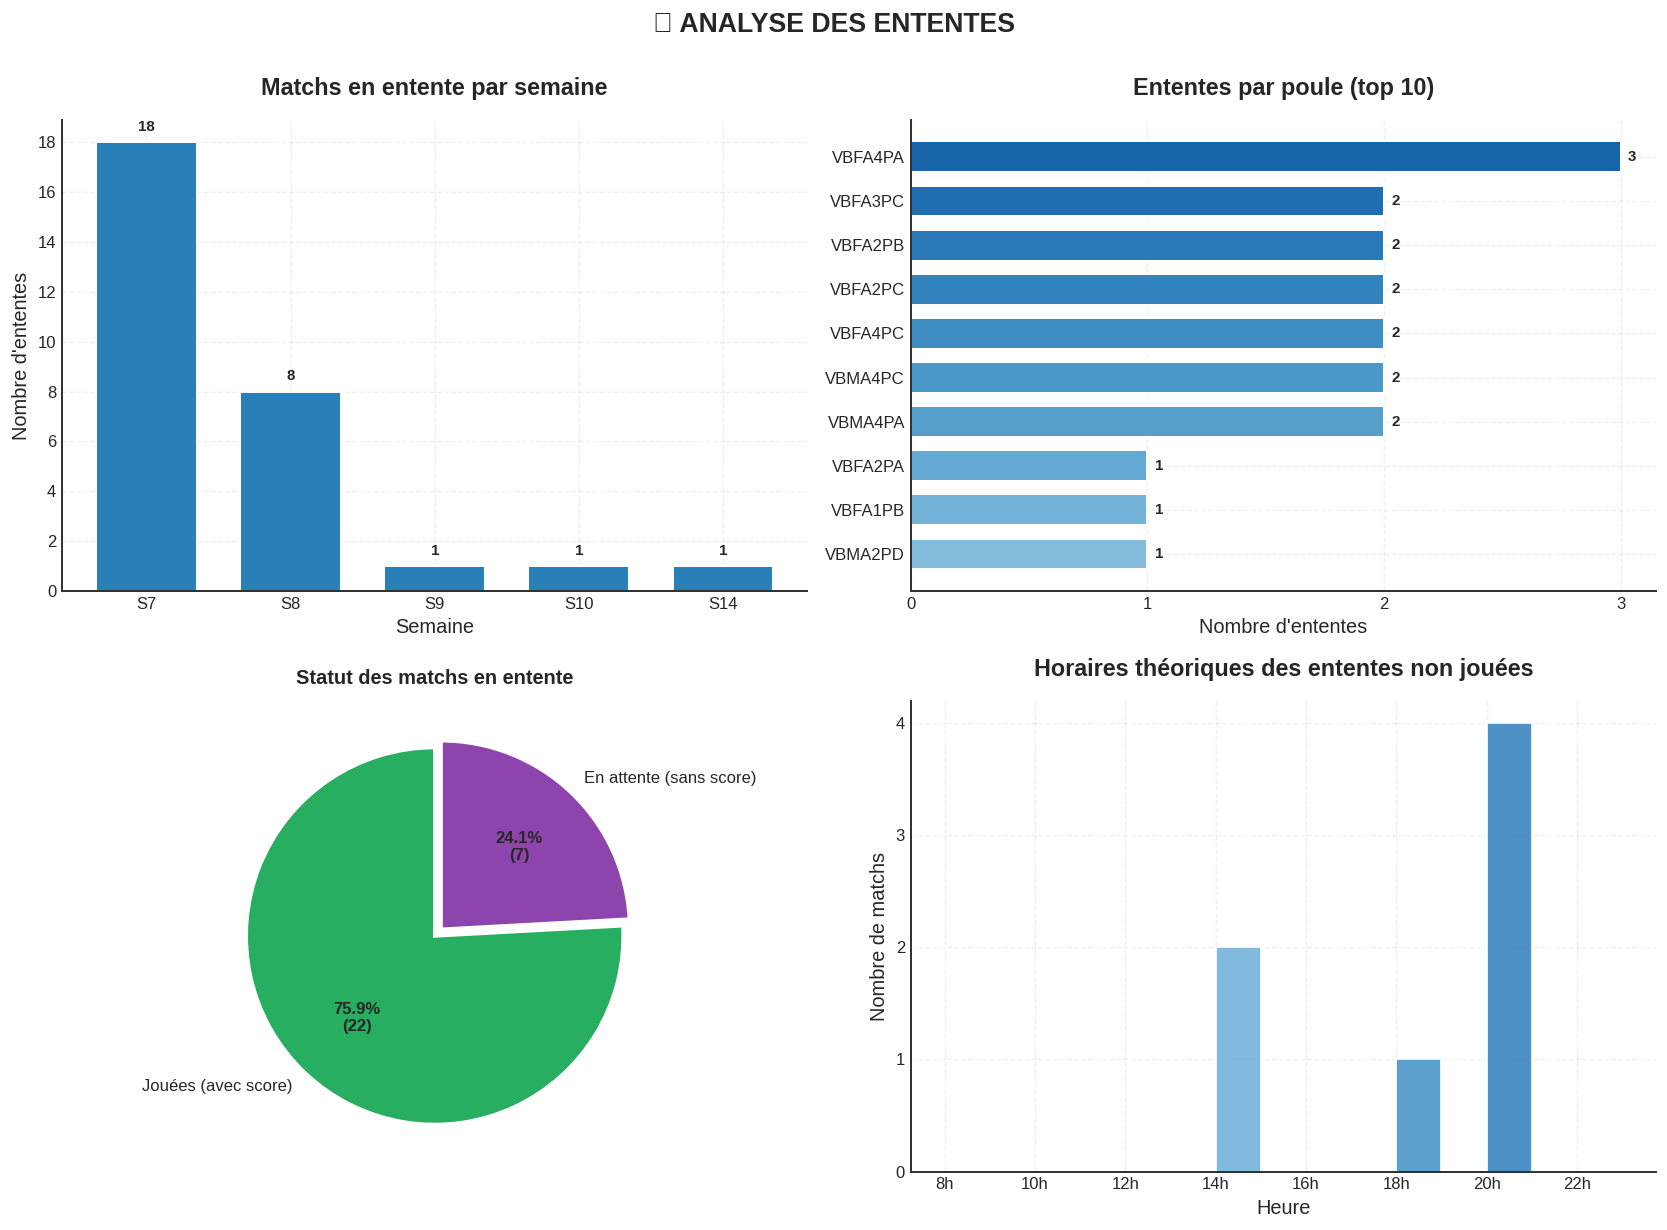


📋 LISTE DES MATCHS EN ENTENTE:


,Equipe_1,Equipe_2,Genre,Poule,Semaine,Score,Remarques
0,LYON 2 (1),LYON 3 (1),F,VBFA1PB,14,NaN,NaN
160,LYON 1 (5),LYON 1 (4),F,VBFA2PA,7,1-3,A FAIRE AVANT LE 08/01/26 | Importé J7 | J7.xlsx
161,LYON 1 (3),LYON 1 (2),F,VBFA2PB,7,0-3,A FAIRE AVANT LE 08/01/26 | Importé J7 | J7.xlsx
162,LYON 2 (7),LYON 2 (IEP) (4),F,VBFA3PC,7,NaN,A FAIRE AVANT LE 08/01/26 | Importé J7 | J7.xlsx
163,LYON 1 (10),LYON 1 (12),F,VBFA4PA,7,3-1,A FAIRE AVANT LE 08/01/26 | Importé J7 | J7.xlsx
164,LYON 1 (10),LYON 1 (7),F,VBFA4PA,7,2-3,A FAIRE AVANT LE 08/01/26 | Importé J7 | J7.xlsx
165,LYON 1 (12),LYON 1 (13),F,VBFA4PA,7,2-3,A FAIRE AVANT LE 08/01/26 | Importé J7 | J7.xlsx
166,SANTE (6),SANTE (5),F,VBFA4PC,7,NaN,A FAIRE AVANT LE 08/01/26 | Importé J7 | J7.xlsx
167,LYON 1 (2),LYON 1 (1),M,VBMA1PA,7,2-3,A FAIRE AVANT LE 08/01/26 | Importé J7 | J7.xlsx
168,LYON 1 (26),ECL (1),M,VBMA1PB,7,NaN,A FAIRE AVANT LE 08/01/26 | Importé J7 | J7.xlsx


In [16]:
# ============================================================================
# ANALYSE DES ENTENTES
# ============================================================================

df_ententes = df[df['is_entente'] | (df['statut'] == 'entente')]

print("=" * 60)
print("🤝 ANALYSE DES ENTENTES")
print("=" * 60)
print(f"\n📌 Nombre total de matchs en entente: {len(df_ententes)}")

if len(df_ententes) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("🤝 ANALYSE DES ENTENTES", fontsize=16, fontweight='bold', y=1.02)
    
    # --- Graphique 1: Ententes par semaine ---
    ax = axes[0, 0]
    ententes_semaine = df_ententes.groupby('semaine_num').size().sort_index()
    if len(ententes_semaine) > 0:
        x_pos = np.arange(len(ententes_semaine))
        bars = ax.bar(x_pos, ententes_semaine.values, 
                      color=COLORS['entente'], edgecolor='white', linewidth=1.2, width=0.7)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f'S{int(s)}' for s in ententes_semaine.index], fontsize=9)
        add_value_labels(ax, bars, fontsize=9)
        style_axis(ax, 'Semaine', "Nombre d'ententes", 'Matchs en entente par semaine', integer_y=True)
    
    # --- Graphique 2: Ententes par poule ---
    ax = axes[0, 1]
    ententes_poule = df_ententes['Poule'].value_counts().head(10)
    if len(ententes_poule) > 0:
        y_pos = np.arange(len(ententes_poule))
        colors_gradient = [plt.cm.Blues(0.4 + 0.4 * (1 - i / len(ententes_poule))) for i in range(len(ententes_poule))]
        bars = ax.barh(y_pos, ententes_poule.values, color=colors_gradient, 
                       edgecolor='white', linewidth=1.2, height=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(ententes_poule.index, fontsize=9)
        ax.invert_yaxis()
        add_value_labels_h(ax, bars, fontsize=9)
        style_axis(ax, "Nombre d'ententes", '', 'Ententes par poule (top 10)', integer_x=True)
    
    # --- Graphique 3: Statut des ententes (jouées ou non) ---
    ax = axes[1, 0]
    ententes_avec_score = df_ententes[df_ententes['has_score']]
    ententes_sans_score = df_ententes[~df_ententes['has_score']]
    
    entente_status = pd.Series({
        'Jouées (avec score)': len(ententes_avec_score),
        'En attente (sans score)': len(ententes_sans_score)
    })
    
    if entente_status.sum() > 0:
        colors_pie = [COLORS['joué'], COLORS['score_manquant']]
        wedges, texts, autotexts = ax.pie(
            entente_status.values, 
            labels=entente_status.index,
            autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*len(df_ententes))})',
            colors=colors_pie,
            explode=[0, 0.05],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        for autotext in autotexts:
            autotext.set_fontsize(10)
            autotext.set_fontweight('bold')
        for text in texts:
            text.set_fontsize(10)
        ax.set_title('Statut des matchs en entente', fontsize=12, fontweight='bold', pad=10)
    
    # --- Graphique 4: Horaires théoriques des ententes non jouées ---
    ax = axes[1, 1]
    horaires_ententes_non_jouees = df_ententes[~df_ententes['has_score']]['horaire_theorique_min'].dropna()
    if len(horaires_ententes_non_jouees) > 0:
        bins = range(8, 24)
        n, bin_edges, patches = ax.hist(horaires_ententes_non_jouees / 60, bins=bins, 
                                         color=COLORS['entente'], edgecolor='white', 
                                         linewidth=1.2, alpha=0.85)
        for i, patch in enumerate(patches):
            patch.set_facecolor(plt.cm.Blues(0.3 + 0.5 * (i / len(patches))))
        ax.set_xticks(range(8, 24, 2))
        ax.set_xticklabels([f'{h}h' for h in range(8, 24, 2)])
        style_axis(ax, 'Heure', 'Nombre de matchs', 'Horaires théoriques des ententes non jouées', integer_y=True)
    else:
        ax.text(0.5, 0.5, '✅ Toutes les ententes\nont été jouées!', 
               ha='center', va='center', transform=ax.transAxes, fontsize=14,
               fontweight='bold', color=COLORS['joué'])
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
        ax.set_title('Horaires des ententes non jouées', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    smart_show_individual("Analyse_ententes")
    
    # Liste des ententes
    print("\n📋 LISTE DES MATCHS EN ENTENTE:")
    display(df_ententes[['Equipe_1', 'Equipe_2', 'Genre', 'Poule', 'Semaine', 'Score', 'Remarques']].head(20))
else:
    print("✅ Aucune entente enregistrée!")

## 13. 🔄 Analyse des matchs Aller-Retour

🔄 ANALYSE DES MATCHS ALLER-RETOUR

📌 Nombre de matchs dans poules Aller-Retour: 89
📋 Poules concernées: VBFA2PA, VBMA1PA, VBMA1PB, VBMA2PA, VBMA2PB, VBMA3PA, VBMA3PB, VBMA3PC, VBMA3PD, VBMA3PE, VBMA4PA, VBMA4PB

📊 Répartition des matchs joués:
   • Matchs aller: 56
   • Matchs retour: 33

📊 STATISTIQUES DES PAIRES ALLER-RETOUR:
   • Nombre de paires théoriques: 57
   • Paires complètes (2 matchs): 33 (57.9%)
   • Paires avec 1 seul match: 23 (40.4%)
   • Paires sans aucun match: 1 (1.8%)

⚠️ PAIRES N'AYANT JAMAIS JOUÉ (1):
   1. ECL (1) vs LYON 1 (4) (VBFA2PA)
   💾 Sauvegardé: 32_Matchs_aller_retour_Complétion_des_57_paires_Aller-Retour.png
   💾 Sauvegardé: 33_Matchs_aller_retour_Matchs_par_poule_Théoriques_vs_Joués.png
   💾 Sauvegardé: 34_Matchs_aller_retour_Écart_entre_match_aller_et_retour.png
   💾 Sauvegardé: 35_Matchs_aller_retour_Matchs_Aller_vs_Retour_par_semaine.png


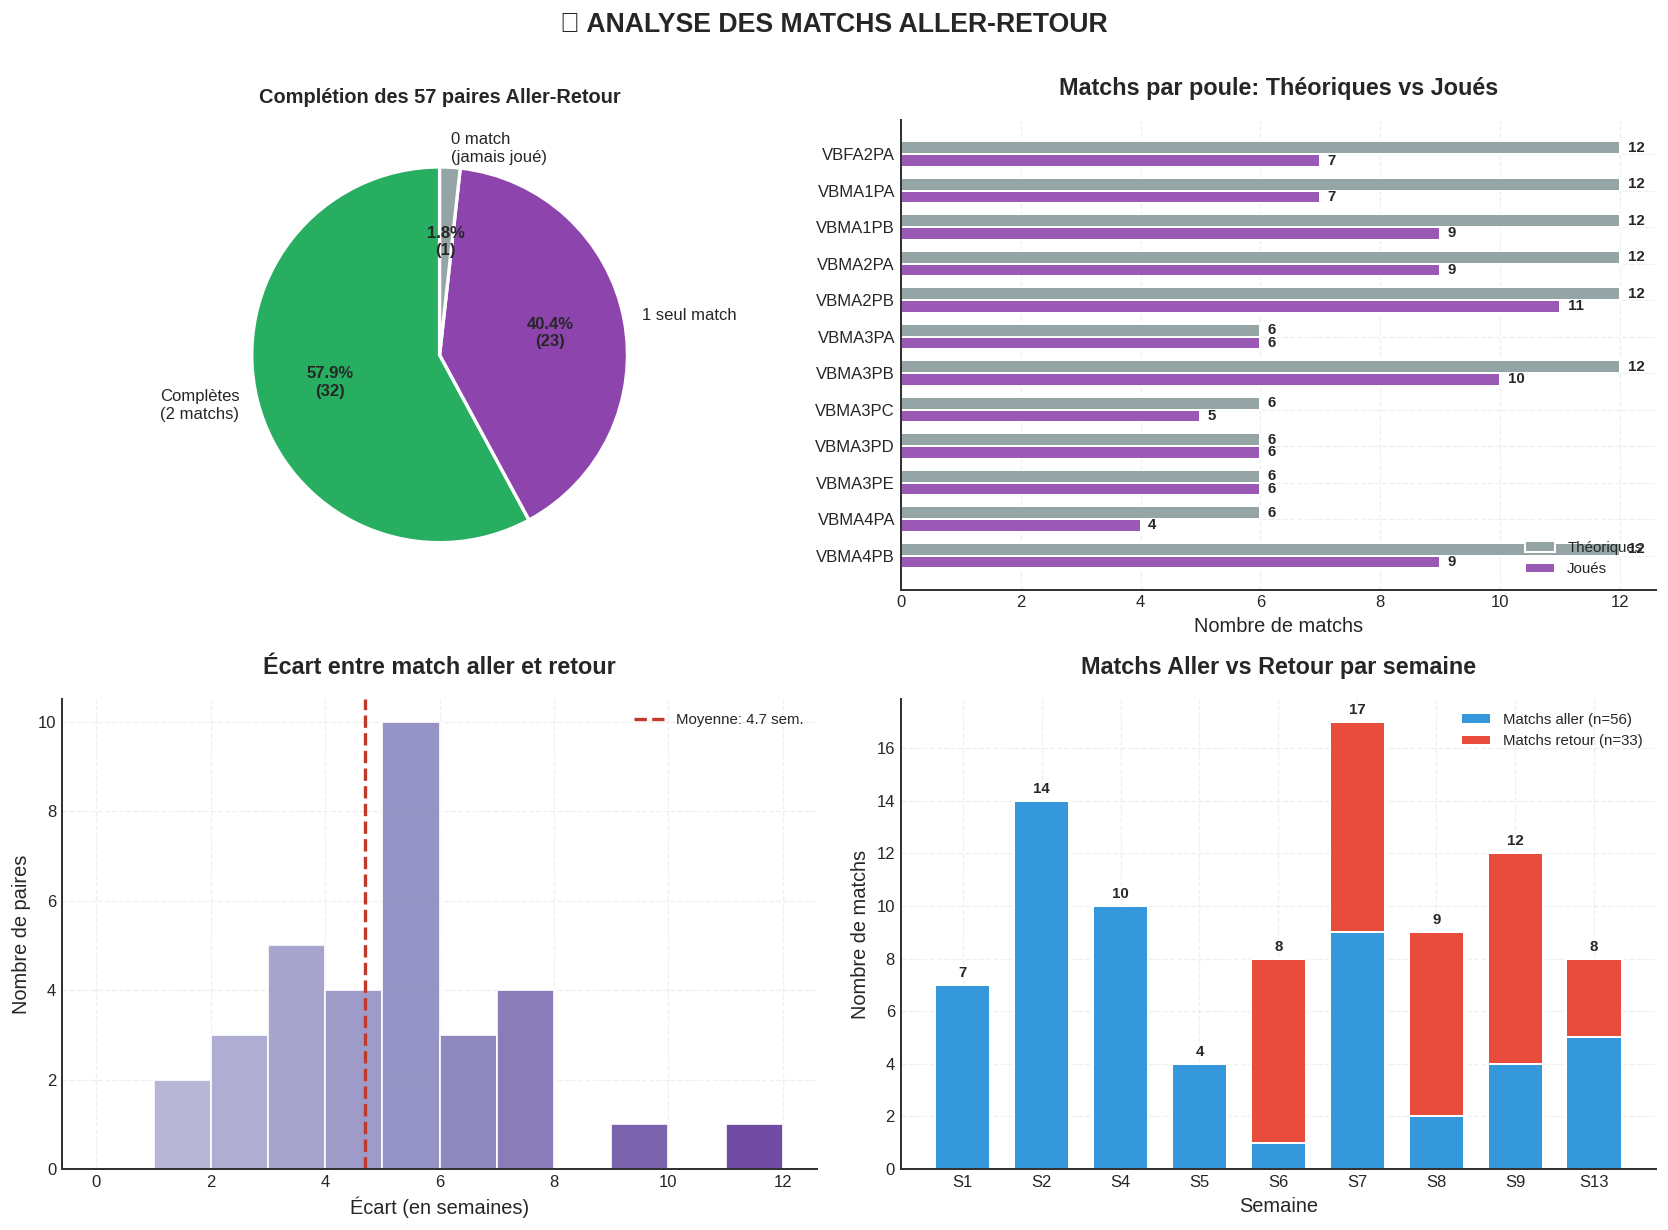

In [17]:
# ============================================================================
# ANALYSE DES MATCHS ALLER-RETOUR
# ============================================================================

df_aller_retour = df[df['is_aller_retour']].copy()

print("=" * 60)
print("🔄 ANALYSE DES MATCHS ALLER-RETOUR")
print("=" * 60)
print(f"\n📌 Nombre de matchs dans poules Aller-Retour: {len(df_aller_retour)}")
print(f"📋 Poules concernées: {', '.join(sorted(poules_aller_retour)) if poules_aller_retour else 'Aucune'}")

if len(poules_aller_retour) > 0 and len(df_aller_retour) > 0:
    # Identifier les paires de matchs (aller + retour) jouées
    def get_match_pair_key(row):
        """Crée une clé unique pour une paire d'équipes (indépendante de l'ordre)."""
        eq1 = str(row.get('Equipe_1', '')).strip()
        eq2 = str(row.get('Equipe_2', '')).strip()
        poule = str(row.get('Poule', '')).strip()
        return tuple(sorted([eq1, eq2])) + (poule,)
    
    df_aller_retour['pair_key'] = df_aller_retour.apply(get_match_pair_key, axis=1)
    
    # Identifier si un match est aller ou retour (basé sur la semaine)
    df_aller_retour['type_match'] = 'aller'  # Par défaut
    for pair_key, group in df_aller_retour.groupby('pair_key'):
        if len(group) >= 2:
            group_sorted = group.sort_values('semaine_num')
            for i, idx in enumerate(group_sorted.index):
                df_aller_retour.loc[idx, 'type_match'] = 'aller' if i == 0 else 'retour'
    
    # Compter les matchs aller et retour
    matchs_aller = len(df_aller_retour[df_aller_retour['type_match'] == 'aller'])
    matchs_retour = len(df_aller_retour[df_aller_retour['type_match'] == 'retour'])
    
    # Compter les paires jouées
    paires_counts = df_aller_retour.groupby('pair_key').agg({
        'statut': 'count',
        'has_score': 'sum'
    }).rename(columns={'statut': 'nb_matchs', 'has_score': 'nb_avec_score'})
    paires_jouees = set(paires_counts.index)
    
    print(f"\n📊 Répartition des matchs joués:")
    print(f"   • Matchs aller: {matchs_aller}")
    print(f"   • Matchs retour: {matchs_retour}")
    
    # === Calculer toutes les paires théoriques depuis df_equipes ===
    paires_theoriques = set()
    for poule in poules_aller_retour:
        equipes_poule = df_equipes[df_equipes['Poule'] == poule]['Equipe'].tolist() if 'Equipe' in df_equipes.columns else []
        for i, eq1 in enumerate(equipes_poule):
            for eq2 in equipes_poule[i+1:]:
                pair_key = tuple(sorted([str(eq1).strip(), str(eq2).strip()])) + (str(poule).strip(),)
                paires_theoriques.add(pair_key)
    
    # Identifier les paires avec 0, 1 ou 2 matchs
    paires_deux_matchs = set(paires_counts[paires_counts['nb_matchs'] == 2].index)
    paires_un_match = set(paires_counts[paires_counts['nb_matchs'] == 1].index)
    paires_zero_matchs = paires_theoriques - paires_jouees  # Paires qui n'ont jamais joué
    
    paires_completes = len(paires_deux_matchs)
    paires_un_seul = len(paires_un_match)
    paires_zero = len(paires_zero_matchs)
    paires_attendues = len(paires_theoriques) if paires_theoriques else len(paires_jouees)
    
    print(f"\n📊 STATISTIQUES DES PAIRES ALLER-RETOUR:")
    print(f"   • Nombre de paires théoriques: {paires_attendues}")
    print(f"   • Paires complètes (2 matchs): {paires_completes} ({paires_completes/paires_attendues*100:.1f}%)" if paires_attendues > 0 else "")
    print(f"   • Paires avec 1 seul match: {paires_un_seul} ({paires_un_seul/paires_attendues*100:.1f}%)" if paires_attendues > 0 else "")
    if paires_zero > 0:
        print(f"   • Paires sans aucun match: {paires_zero} ({paires_zero/paires_attendues*100:.1f}%)")
    
    # Afficher les paires sans aucun match
    if paires_zero_matchs:
        print(f"\n⚠️ PAIRES N'AYANT JAMAIS JOUÉ ({len(paires_zero_matchs)}):")
        for i, pair_key in enumerate(sorted(paires_zero_matchs)[:10]):
            eq1, eq2, poule = pair_key
            print(f"   {i+1}. {eq1} vs {eq2} ({poule})")
        if len(paires_zero_matchs) > 10:
            print(f"   ... et {len(paires_zero_matchs) - 10} autres paires")
    
    # Graphiques
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("🔄 ANALYSE DES MATCHS ALLER-RETOUR", fontsize=16, fontweight='bold', y=1.02)
    
    # --- Graphique 1: Statut des paires (incluant 0 matchs si existants) ---
    ax = axes[0, 0]
    statuts_paires_dict = {
        'Complètes\n(2 matchs)': paires_completes,
        '1 seul match': paires_un_seul,
    }
    if paires_zero > 0:
        statuts_paires_dict['0 match\n(jamais joué)'] = paires_zero
    statuts_paires = pd.Series(statuts_paires_dict)
    
    colors_pie = [COLORS['joué'], COLORS['score_manquant']]
    if paires_zero > 0:
        colors_pie.append('#95a5a6')  # Gris pour 0 match
    
    if statuts_paires.sum() > 0:
        wedges, texts, autotexts = ax.pie(
            statuts_paires.values, 
            labels=statuts_paires.index,
            autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*statuts_paires.sum())})' if pct > 0 else '',
            colors=colors_pie,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        for autotext in autotexts:
            autotext.set_fontsize(10)
            autotext.set_fontweight('bold')
        ax.set_title(f'Complétion des {paires_attendues} paires Aller-Retour', fontsize=12, fontweight='bold', pad=10)
    
    # --- Graphique 2: Matchs par poule Aller-Retour (théoriques vs joués) ---
    ax = axes[0, 1]
    
    # Calculer matchs théoriques et joués par poule
    ar_stats_par_poule = {}
    for poule in poules_aller_retour:
        n_equipes = len(df_equipes[df_equipes['Poule'] == poule])
        theoriques = n_equipes * (n_equipes - 1)  # n*(n-1) pour aller-retour
        joues = len(df_aller_retour[df_aller_retour['Poule'] == poule])
        ar_stats_par_poule[poule] = {'theoriques': theoriques, 'joues': joues}
    
    if ar_stats_par_poule:
        poules_sorted = sorted(ar_stats_par_poule.keys())
        y_pos = np.arange(len(poules_sorted))
        width = 0.35
        
        vals_theoriques = [ar_stats_par_poule[p]['theoriques'] for p in poules_sorted]
        vals_joues = [ar_stats_par_poule[p]['joues'] for p in poules_sorted]
        
        bars1 = ax.barh(y_pos - width/2, vals_theoriques, height=width, 
                        label='Théoriques', color='#95a5a6', edgecolor='white', linewidth=1.2)
        bars2 = ax.barh(y_pos + width/2, vals_joues, height=width, 
                        label='Joués', color='#9b59b6', edgecolor='white', linewidth=1.2)
        
        ax.set_yticks(y_pos)
        ax.set_yticklabels(poules_sorted, fontsize=9)
        ax.invert_yaxis()
        ax.legend(loc='lower right', fontsize=9)
        
        for bars in [bars1, bars2]:
            add_value_labels_h(ax, bars, fontsize=9)
        
        style_axis(ax, 'Nombre de matchs', '', 'Matchs par poule: Théoriques vs Joués', integer_x=True)
    
    # --- Graphique 3: Écart entre match aller et retour (en semaines) ---
    ax = axes[1, 0]
    paires_avec_deux = df_aller_retour.groupby('pair_key').filter(lambda x: len(x) == 2)
    if len(paires_avec_deux) > 0:
        ecarts = []
        for pair_key, group in paires_avec_deux.groupby('pair_key'):
            semaines = group['semaine_num'].dropna().values
            if len(semaines) == 2:
                ecarts.append(abs(semaines[1] - semaines[0]))
        
        if ecarts:
            bins = range(0, int(max(ecarts)) + 2)
            n, bin_edges, patches = ax.hist(ecarts, bins=bins, 
                                             color='#9b59b6', edgecolor='white', 
                                             linewidth=1.2, alpha=0.85)
            for i, patch in enumerate(patches):
                patch.set_facecolor(plt.cm.Purples(0.4 + 0.5 * (i / max(len(patches), 1))))
            
            mean_ecart = np.mean(ecarts)
            ax.axvline(x=mean_ecart, color=COLORS['forfait'], linestyle='--', 
                       linewidth=2, label=f'Moyenne: {mean_ecart:.1f} sem.')
            ax.legend(loc='upper right', fontsize=9)
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax.yaxis.set_major_locator(MaxNLocator(integer=True))
            style_axis(ax, 'Écart (en semaines)', 'Nombre de paires', 
                       'Écart entre match aller et retour', integer_x=True, integer_y=True)
        else:
            ax.text(0.5, 0.5, 'Aucune paire avec 2 matchs', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=12, color='gray')
            ax.axis('off')
    else:
        ax.text(0.5, 0.5, 'Aucune paire avec 2 matchs', ha='center', va='center', 
               transform=ax.transAxes, fontsize=12, color='gray')
        ax.axis('off')
    
    # --- Graphique 4: Semaines des matchs Aller vs Retour (barres empilées) ---
    ax = axes[1, 1]
    ar_semaine_aller = df_aller_retour[df_aller_retour['type_match'] == 'aller'].groupby('semaine_num').size()
    ar_semaine_retour = df_aller_retour[df_aller_retour['type_match'] == 'retour'].groupby('semaine_num').size()
    
    # Fusionner les semaines
    all_semaines = sorted(set(ar_semaine_aller.index) | set(ar_semaine_retour.index))
    
    if len(all_semaines) > 0:
        x_pos = np.arange(len(all_semaines))
        width = 0.7
        
        vals_aller = [ar_semaine_aller.get(s, 0) for s in all_semaines]
        vals_retour = [ar_semaine_retour.get(s, 0) for s in all_semaines]
        
        bars1 = ax.bar(x_pos, vals_aller, width=width, label=f'Matchs aller (n={sum(vals_aller)})', 
                       color='#3498db', edgecolor='white', linewidth=1.2)
        bars2 = ax.bar(x_pos, vals_retour, width=width, bottom=vals_aller,
                       label=f'Matchs retour (n={sum(vals_retour)})', 
                       color='#e74c3c', edgecolor='white', linewidth=1.2)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f'S{int(s)}' for s in all_semaines], fontsize=9)
        ax.legend(loc='upper right', fontsize=9)
        
        # Ajouter les totaux
        for i, (a, r) in enumerate(zip(vals_aller, vals_retour)):
            total = a + r
            if total > 0:
                ax.text(i, total + 0.3, str(int(total)), ha='center', fontsize=9, fontweight='bold')
        
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        style_axis(ax, 'Semaine', 'Nombre de matchs', 'Matchs Aller vs Retour par semaine', integer_y=True)
    else:
        ax.text(0.5, 0.5, 'Pas de données de semaines', ha='center', va='center', 
               transform=ax.transAxes, fontsize=12, color='gray')
        ax.axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    smart_show_individual("Matchs_aller_retour")
else:
    print("ℹ️ Aucune poule aller-retour détectée ou aucun match joué.")

## 14. 📊 Analyse des scores

📊 ANALYSE DES SCORES (scores normaux uniquement)

📌 Matchs avec score: 224
📌 Scores normaux analysés: 218
⚠️ Scores anormaux exclus: 6 (ex: 1-0, 2-1)
📌 Matchs sans score: 37

📈 STATISTIQUES DES SCORES (scores normaux):
   Score moyen gagnant: 3.00
   Score moyen perdant: 0.74
   Écart moyen: 2.26
   Matchs serrés (écart ≤ 1): 41 (18.8%)
   💾 Sauvegardé: 36_Analyse_scores_Distribution_des_scores_normalisés.png
   💾 Sauvegardé: 37_Analyse_scores_Répartition_des_types_de_victoire.png
   💾 Sauvegardé: 38_Analyse_scores_Distribution_des_écarts.png
   💾 Sauvegardé: 39_Analyse_scores_Évolution_des_scores_par_semaine.png
   💾 Sauvegardé: 40_Analyse_scores_subplot_5.png


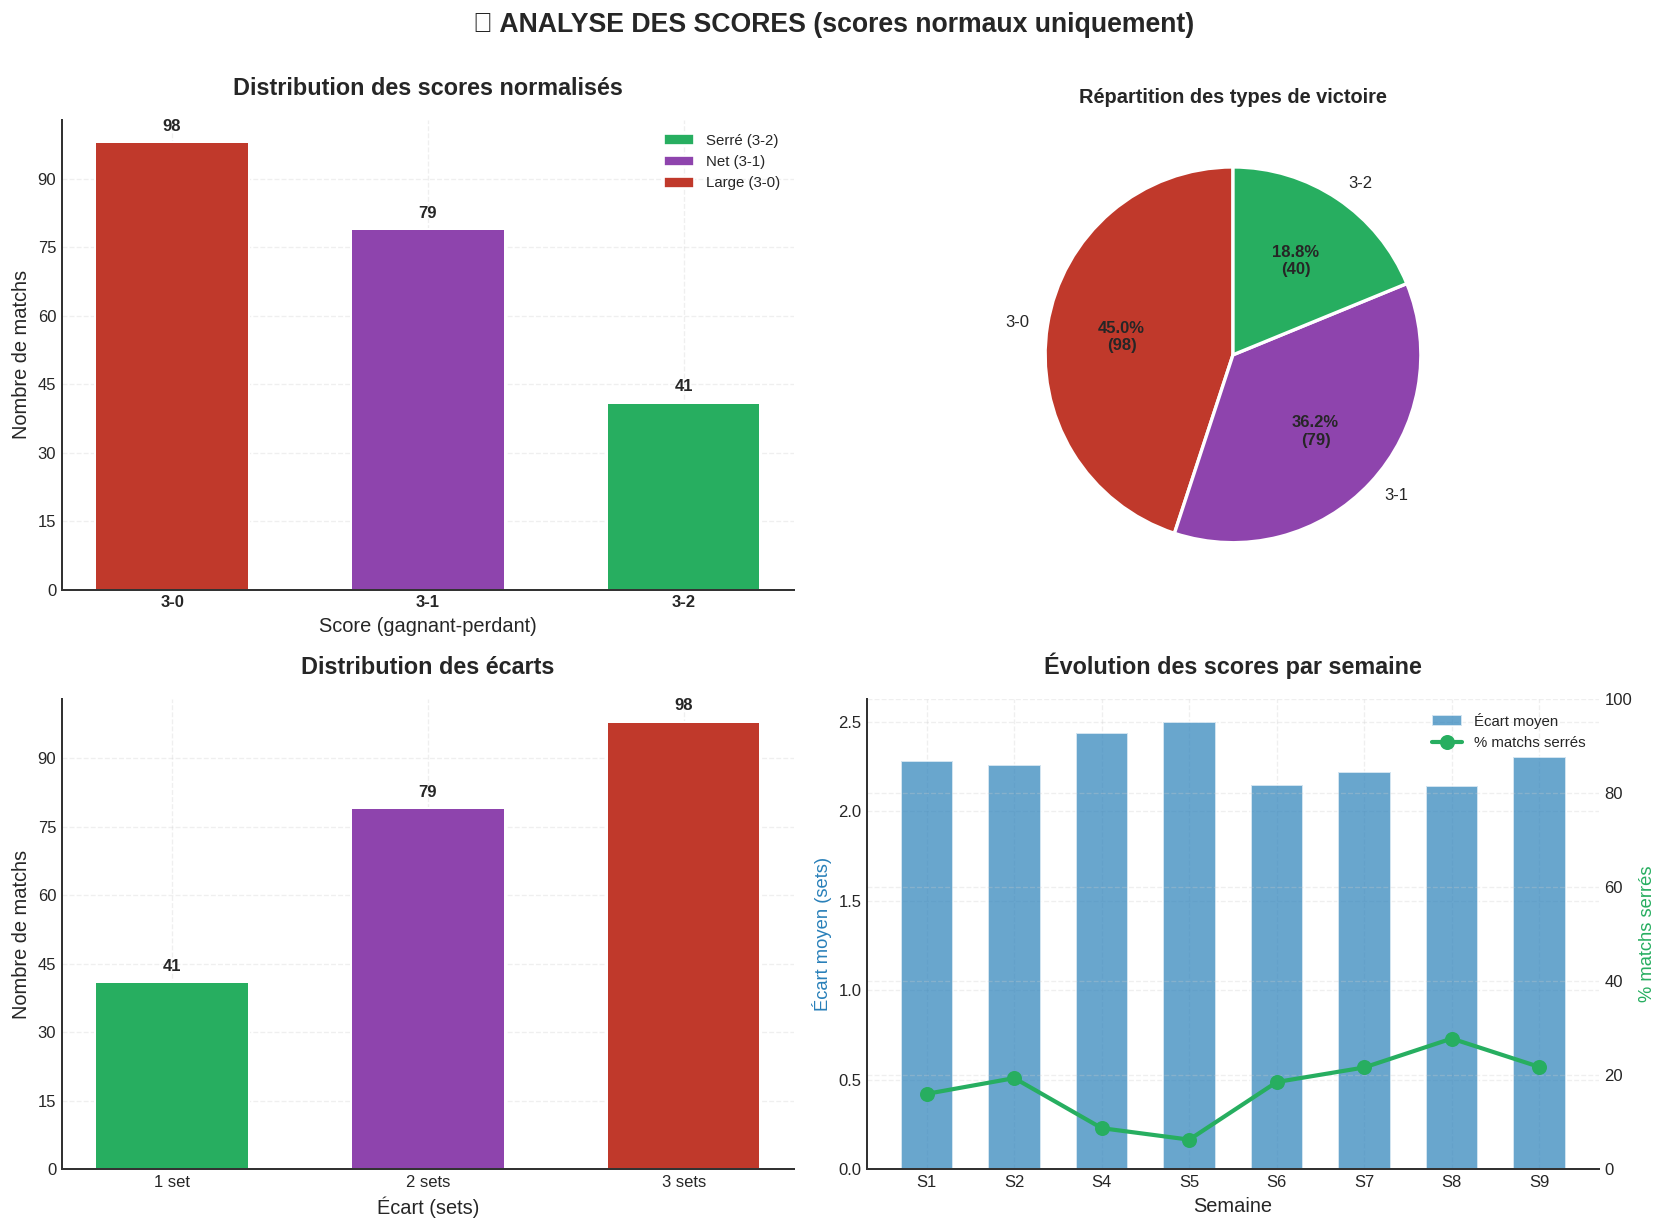


📊 RÉSUMÉ DES SCORES (scores normaux uniquement):
   3-0: 98 matchs (45.0%)
   3-1: 79 matchs (36.2%)
   3-2: 41 matchs (18.8%)


In [18]:
# ============================================================================
# ANALYSE DES SCORES
# EXCLUSION: Scores anormaux (1-0, 2-1 qui indiquent souvent des forfaits)
# ============================================================================

# Scores normaux en volley: 3-0, 3-1, 3-2, 0-3, 1-3, 2-3
SCORES_NORMAUX = ['3-0', '3-1', '3-2', '0-3', '1-3', '2-3']

# Filtrer les matchs avec score normal uniquement
df_avec_score = df[df['has_score']].copy()
df_avec_score_normal = df_avec_score[df_avec_score['score_normalise'].isin(SCORES_NORMAUX)].copy()

nb_scores_anormaux = len(df_avec_score) - len(df_avec_score_normal)

print("=" * 60)
print("📊 ANALYSE DES SCORES (scores normaux uniquement)")
print("=" * 60)
print(f"\n📌 Matchs avec score: {len(df_avec_score)}")
print(f"📌 Scores normaux analysés: {len(df_avec_score_normal)}")
print(f"⚠️ Scores anormaux exclus: {nb_scores_anormaux} (ex: 1-0, 2-1)")
print(f"📌 Matchs sans score: {len(df[~df['has_score']])}")

if len(df_avec_score_normal) > 0:
    # Calculs de base
    df_avec_score_normal['diff_score'] = abs(df_avec_score_normal['score_eq1'] - df_avec_score_normal['score_eq2'])
    df_avec_score_normal['total_score'] = df_avec_score_normal['score_eq1'] + df_avec_score_normal['score_eq2']
    df_avec_score_normal['match_serre'] = df_avec_score_normal['diff_score'] <= 1
    
    # Statistiques
    print(f"\n📈 STATISTIQUES DES SCORES (scores normaux):")
    print(f"   Score moyen gagnant: {df_avec_score_normal['score_gagnant'].mean():.2f}")
    print(f"   Score moyen perdant: {df_avec_score_normal['score_perdant'].mean():.2f}")
    print(f"   Écart moyen: {df_avec_score_normal['diff_score'].mean():.2f}")
    print(f"   Matchs serrés (écart ≤ 1): {df_avec_score_normal['match_serre'].sum()} ({df_avec_score_normal['match_serre'].mean()*100:.1f}%)")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("📊 ANALYSE DES SCORES (scores normaux uniquement)", fontsize=16, fontweight='bold', y=1.02)
    
    # --- Graphique 1: Distribution des scores normalisés (gagnant-perdant) ---
    ax = axes[0, 0]
    scores_norm = df_avec_score_normal['score_normalise'].dropna().value_counts().sort_index()
    if len(scores_norm) > 0:
        x_pos = np.arange(len(scores_norm))
        colors_bars = []
        for s in scores_norm.index:
            parts = s.split('-')
            ecart = int(parts[0]) - int(parts[1])
            if ecart <= 1:
                colors_bars.append(COLORS['joué'])  # Match serré
            elif ecart == 2:
                colors_bars.append(COLORS['score_manquant'])  # Écart moyen
            else:
                colors_bars.append(COLORS['forfait'])  # Grand écart
        
        bars = ax.bar(x_pos, scores_norm.values, color=colors_bars, 
                      edgecolor='white', linewidth=1.2, width=0.6)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(scores_norm.index, fontsize=11, fontweight='bold')
        add_value_labels(ax, bars, fontsize=10)
        style_axis(ax, 'Score (gagnant-perdant)', 'Nombre de matchs', 
                   'Distribution des scores normalisés', integer_y=True)
        
        # Légende
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=COLORS['joué'], edgecolor='white', label='Serré (3-2)'),
            Patch(facecolor=COLORS['score_manquant'], edgecolor='white', label='Net (3-1)'),
            Patch(facecolor=COLORS['forfait'], edgecolor='white', label='Large (3-0)')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    # --- Graphique 2: Répartition des types de victoire ---
    ax = axes[0, 1]
    type_victoire = df_avec_score_normal['score_normalise'].value_counts()
    if len(type_victoire) > 0:
        colors_pie = []
        for s in type_victoire.index:
            parts = s.split('-')
            ecart = int(parts[0]) - int(parts[1])
            if ecart <= 1:
                colors_pie.append(COLORS['joué'])
            elif ecart == 2:
                colors_pie.append(COLORS['score_manquant'])
            else:
                colors_pie.append(COLORS['forfait'])
        
        wedges, texts, autotexts = ax.pie(
            type_victoire.values, 
            labels=type_victoire.index,
            autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*len(df_avec_score_normal))})',
            colors=colors_pie,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        for autotext in autotexts:
            autotext.set_fontsize(10)
            autotext.set_fontweight('bold')
        ax.set_title('Répartition des types de victoire', fontsize=12, fontweight='bold', pad=10)
    
    # --- Graphique 3: Distribution des écarts de score ---
    ax = axes[1, 0]
    diff_vals = df_avec_score_normal['diff_score'].dropna()
    if len(diff_vals) > 0:
        ecart_counts = diff_vals.value_counts().sort_index()
        x_pos = np.arange(len(ecart_counts))
        colors_ecart = []
        for e in ecart_counts.index:
            if e <= 1:
                colors_ecart.append(COLORS['joué'])
            elif e == 2:
                colors_ecart.append(COLORS['score_manquant'])
            else:
                colors_ecart.append(COLORS['forfait'])
        
        bars = ax.bar(x_pos, ecart_counts.values, color=colors_ecart, 
                      edgecolor='white', linewidth=1.2, width=0.6)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f'{int(e)} set{"s" if e > 1 else ""}' for e in ecart_counts.index], fontsize=10)
        add_value_labels(ax, bars, fontsize=10)
        style_axis(ax, "Écart (sets)", 'Nombre de matchs', 'Distribution des écarts', integer_y=True)
    
    # --- Graphique 4: Scores par semaine (évolution) ---
    ax = axes[1, 1]
    ecart_semaine = df_avec_score_normal.groupby('semaine_num')['diff_score'].mean().sort_index()
    pct_serre_semaine = df_avec_score_normal.groupby('semaine_num')['match_serre'].mean().sort_index() * 100
    
    if len(ecart_semaine) > 0:
        x_pos = np.arange(len(ecart_semaine))
        
        # Double axe
        ax2 = ax.twinx()
        
        bars = ax.bar(x_pos, ecart_semaine.values, color=COLORS['entente'], 
                      edgecolor='white', linewidth=1.2, width=0.6, alpha=0.7, label='Écart moyen')
        line = ax2.plot(x_pos, pct_serre_semaine.values, 'o-', color=COLORS['joué'], 
                        linewidth=2.5, markersize=8, label='% matchs serrés')
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f'S{int(s)}' for s in ecart_semaine.index], fontsize=9)
        ax.set_ylabel('Écart moyen (sets)', fontsize=11, color=COLORS['entente'])
        ax2.set_ylabel('% matchs serrés', fontsize=11, color=COLORS['joué'])
        ax2.set_ylim(0, 100)
        
        # Légende combinée
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
        
        style_axis(ax, 'Semaine', '', 'Évolution des scores par semaine')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    smart_show_individual("Analyse_scores")
    
    # Résumé des scores normalisés
    print("\n📊 RÉSUMÉ DES SCORES (scores normaux uniquement):")
    for score, count in df_avec_score_normal['score_normalise'].value_counts().items():
        pct = count / len(df_avec_score_normal) * 100
        print(f"   {score}: {count} matchs ({pct:.1f}%)")
else:
    print("⚠️ Aucun match avec score valide")

## 15. 📋 Analyse des poules

📋 ANALYSE DES POULES

📌 Nombre de poules: 30
📌 Total matchs théoriques: 266
📌 Total matchs joués (fixés): 233
📌 Total matchs non joués: 33
📌 Matchs avec score: 198 (85.0% des joués)
📌 Matchs entente: 29

📊 TABLEAU COMPLET DE TOUTES LES POULES


,Poule,Théoriques,Joués,Non joués,Avec score,Taux%
0,VBMA2PB,12,11,1,8,91.7
1,VBFA3PC,10,10,0,8,100.0
2,VBFA4PC,10,10,0,9,100.0
3,VBFA4PA,10,10,0,8,100.0
4,VBMA2PD,10,10,0,8,100.0
5,VBFA3PB,10,10,0,9,100.0
6,VBMA4PC,10,10,0,8,100.0
7,VBMA3PB,12,10,2,9,83.3
8,VBMA2PA,12,9,3,8,75.0
9,VBMA4PB,12,9,3,7,75.0



⚠️ Poules incomplètes (< 100% joués): 15
🔴 Poules en retard (< 50% joués): 0
✅ Poules complètes (100% joués): 15
   💾 Sauvegardé: 41_Analyse_poules_TOUTES_LES_POULES_-_Taux_matchs_joués-théoriques.png
   💾 Sauvegardé: 42_Analyse_poules_Répartition_des_matchs_par_poule.png
   💾 Sauvegardé: 43_Analyse_poules_Distribution_des_poules_par_taux_de_complétion.png
   💾 Sauvegardé: 44_Analyse_poules_Répartition_des_matchs_par_genreavec_taux_de_matchs_joués.png


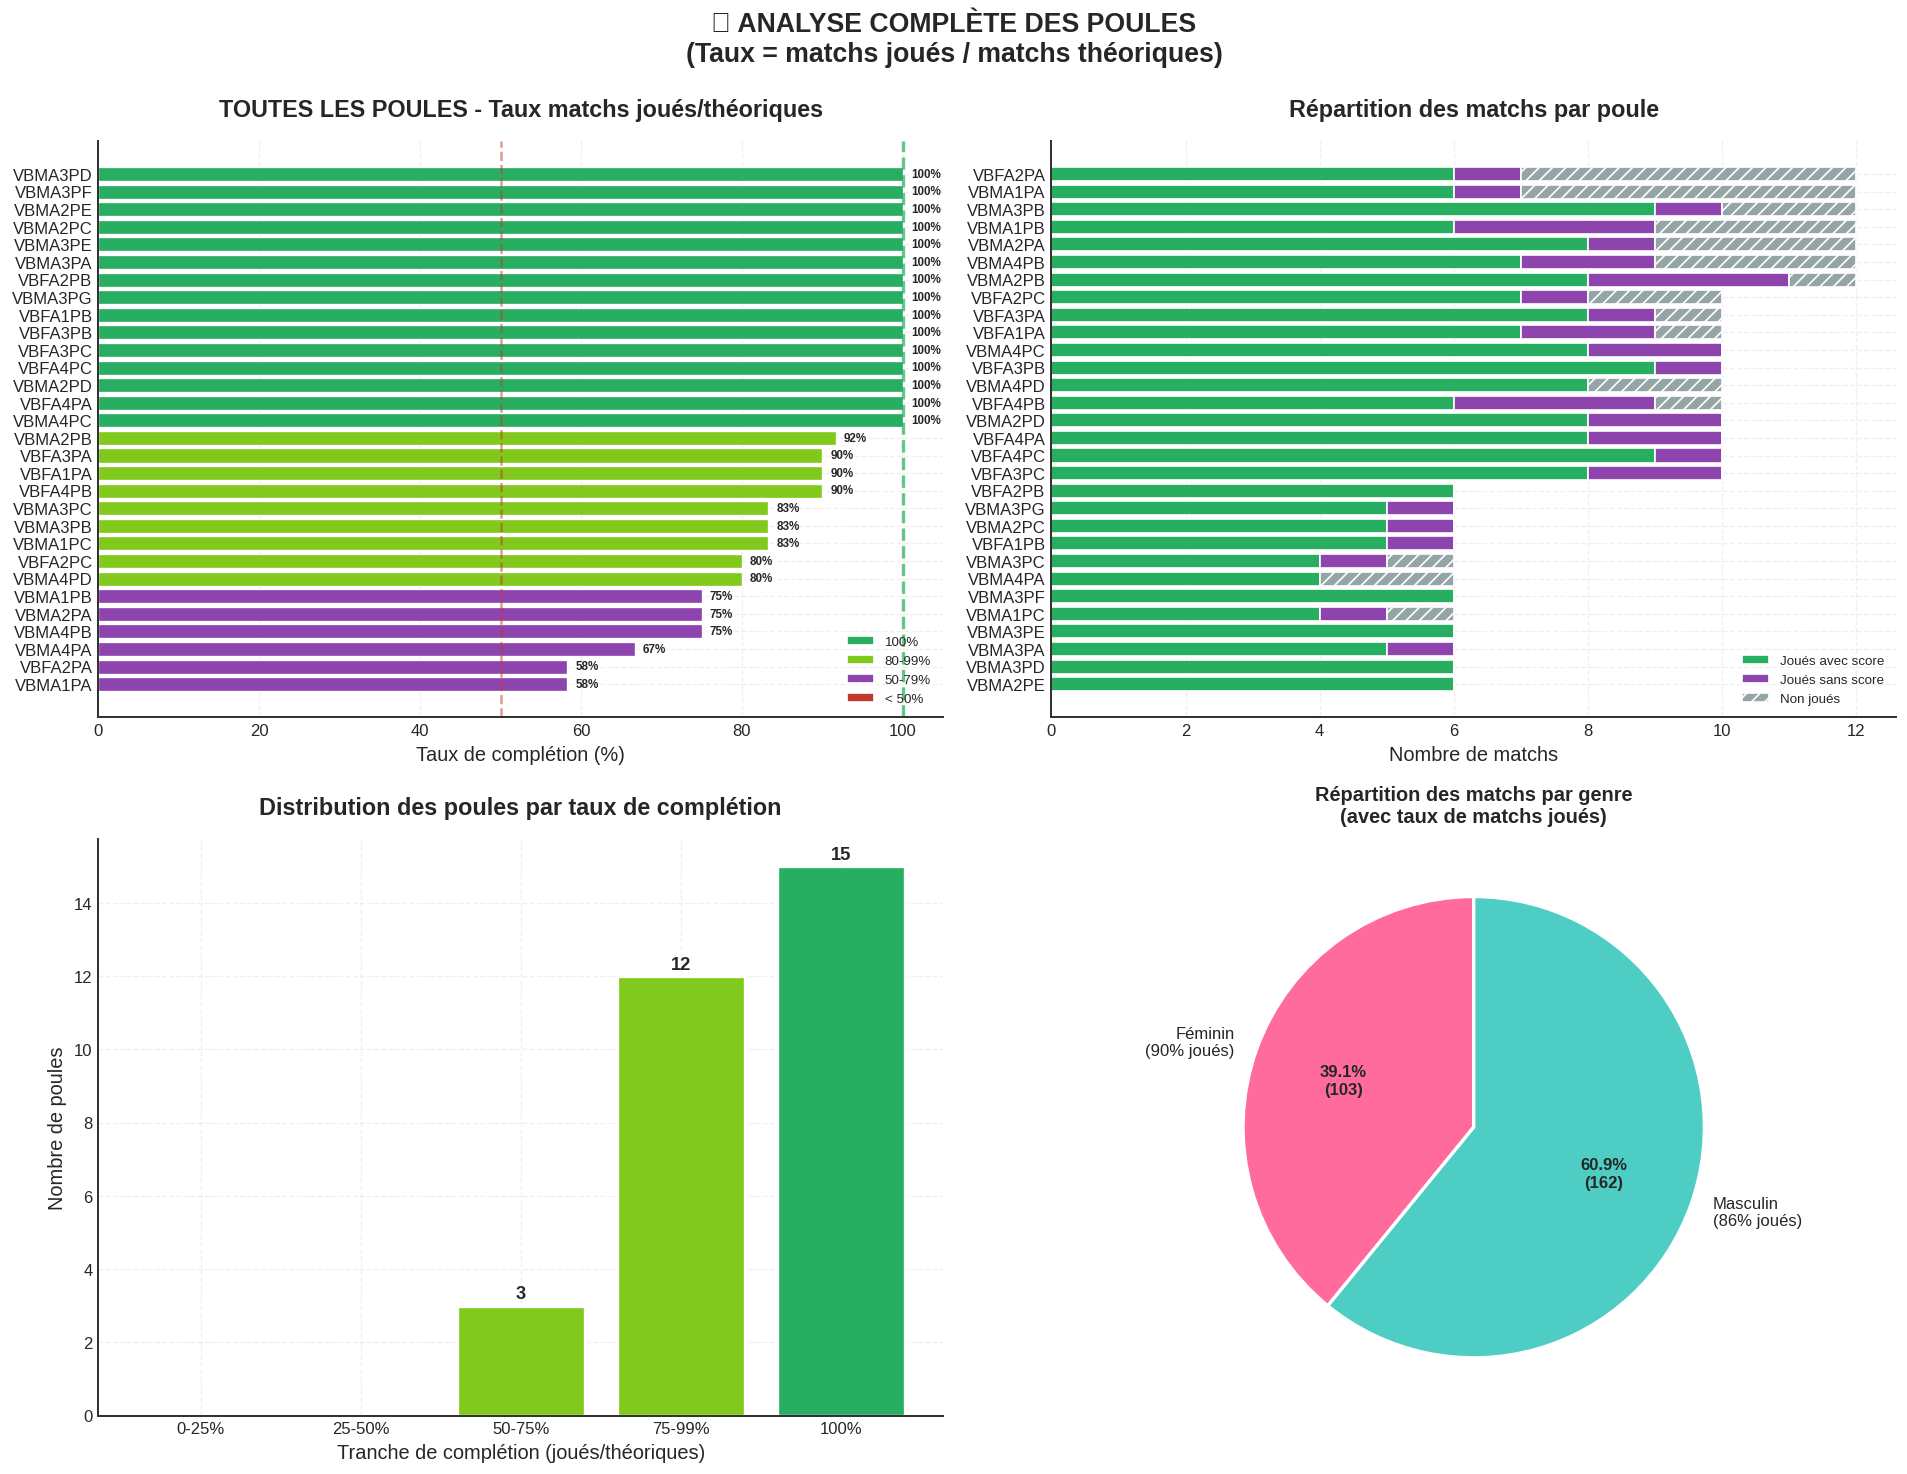

In [19]:
# ============================================================================
# ANALYSE DES POULES
# Taux de complétion = matchs joués (fixés) / matchs théoriques
# Ne pas afficher les forfaits, se baser uniquement sur les scores
# ============================================================================

print("=" * 60)
print("📋 ANALYSE DES POULES")
print("=" * 60)

# Statistiques par poule - utiliser TOUS les matchs fixés
poule_stats = df.groupby('Poule').agg({
    'statut': 'count',  # Total matchs fixés (= joués)
    'has_score': 'sum',  # Matchs avec score
    'is_entente_auto': 'sum',  # Ententes (jour ≠ jeudi ou gymnase ENTENTE)
}).rename(columns={
    'statut': 'Matchs_Joues',  # Renommé de Matchs_Fixes à Matchs_Joues
    'has_score': 'Avec_Score',
    'is_entente_auto': 'Ententes',
})

# Ajouter les matchs théoriques et non planifiés
for poule in poule_stats.index:
    if poule in matchs_theoriques_detail:
        poule_stats.loc[poule, 'Theoriques'] = matchs_theoriques_detail[poule]['matchs_theoriques']
        poule_stats.loc[poule, 'Non_Joues'] = max(0, matchs_theoriques_detail[poule]['matchs_theoriques'] - poule_stats.loc[poule, 'Matchs_Joues'])
    else:
        poule_stats.loc[poule, 'Theoriques'] = poule_stats.loc[poule, 'Matchs_Joues']
        poule_stats.loc[poule, 'Non_Joues'] = 0

# Taux de complétion = matchs JOUÉS (fixés) / matchs théoriques (pas basé sur les scores!)
poule_stats['Taux_Completion'] = (poule_stats['Matchs_Joues'] / poule_stats['Theoriques'] * 100).round(1)
poule_stats['Sans_Score'] = poule_stats['Matchs_Joues'] - poule_stats['Avec_Score']
poule_stats = poule_stats.sort_values('Matchs_Joues', ascending=False)

print(f"\n📌 Nombre de poules: {len(poule_stats)}")
print(f"📌 Total matchs théoriques: {int(poule_stats['Theoriques'].sum())}")
print(f"📌 Total matchs joués (fixés): {int(poule_stats['Matchs_Joues'].sum())}")
print(f"📌 Total matchs non joués: {int(poule_stats['Non_Joues'].sum())}")
print(f"📌 Matchs avec score: {int(poule_stats['Avec_Score'].sum())} ({poule_stats['Avec_Score'].sum()/poule_stats['Matchs_Joues'].sum()*100:.1f}% des joués)")
print(f"📌 Matchs entente: {int(poule_stats['Ententes'].sum())}")

# === TABLEAU COMPLET DE TOUTES LES POULES ===
print("\n" + "="*80)
print("📊 TABLEAU COMPLET DE TOUTES LES POULES")
print("="*80)

poule_display = poule_stats.copy()
poule_display = poule_display.reset_index()
poule_display = poule_display[['Poule', 'Theoriques', 'Matchs_Joues', 'Non_Joues', 'Avec_Score', 'Taux_Completion']]
poule_display.columns = ['Poule', 'Théoriques', 'Joués', 'Non joués', 'Avec score', 'Taux%']
poule_display = poule_display.astype({'Théoriques': int, 'Joués': int, 'Non joués': int, 'Avec score': int})
display(poule_display)

# Résumé des poules problématiques (basé sur les matchs joués, pas les scores)
poules_incomplete = poule_stats[poule_stats['Taux_Completion'] < 100]
poules_50 = poule_stats[poule_stats['Taux_Completion'] < 50]
poules_complete = poule_stats[poule_stats['Taux_Completion'] >= 100]

print(f"\n⚠️ Poules incomplètes (< 100% joués): {len(poules_incomplete)}")
print(f"🔴 Poules en retard (< 50% joués): {len(poules_50)}")
print(f"✅ Poules complètes (100% joués): {len(poules_complete)}")

# === GRAPHIQUES ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("📋 ANALYSE COMPLÈTE DES POULES\n(Taux = matchs joués / matchs théoriques)", fontsize=16, fontweight='bold', y=1.02)

# --- Graphique 1: TOUTES les poules avec leur taux de complétion (joués/théoriques) ---
ax = axes[0, 0]
if len(poule_stats) > 0:
    poules_sorted = poule_stats.sort_values('Taux_Completion', ascending=True)
    y_pos = np.arange(len(poules_sorted))
    values = poules_sorted['Taux_Completion'].values
    
    colors_completion = []
    for r in values:
        if r >= 100:
            colors_completion.append(COLORS['joué'])
        elif r >= 80:
            colors_completion.append('#82c91e')
        elif r >= 50:
            colors_completion.append(COLORS['score_manquant'])
        else:
            colors_completion.append(COLORS['forfait'])
    
    bars = ax.barh(y_pos, values, color=colors_completion, 
                   edgecolor='white', linewidth=0.8, height=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(poules_sorted.index, fontsize=8)
    ax.set_xlim(0, 105)
    ax.axvline(x=100, color=COLORS['joué'], linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(x=50, color=COLORS['forfait'], linestyle='--', linewidth=1.5, alpha=0.5)
    
    for bar, val in zip(bars, values):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2, 
               f'{val:.0f}%', va='center', fontsize=7, fontweight='bold')
    
    style_axis(ax, 'Taux de complétion (%)', '', 'TOUTES LES POULES - Taux matchs joués/théoriques')
    
    legend_elements = [
        mpatches.Patch(facecolor=COLORS['joué'], edgecolor='white', label='100%'),
        mpatches.Patch(facecolor='#82c91e', edgecolor='white', label='80-99%'),
        mpatches.Patch(facecolor=COLORS['score_manquant'], edgecolor='white', label='50-79%'),
        mpatches.Patch(facecolor=COLORS['forfait'], edgecolor='white', label='< 50%')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

# --- Graphique 2: Matchs par poule (avec score, sans score, non joués) ---
ax = axes[0, 1]
if len(poule_stats) > 0:
    poules_by_total = poule_stats.sort_values('Theoriques', ascending=True)
    y_pos = np.arange(len(poules_by_total))
    
    # Barres empilées: Avec score, Sans score, Non joués (pas de forfaits)
    avec_score = poules_by_total['Avec_Score'].values
    sans_score = poules_by_total['Sans_Score'].values.clip(min=0)
    non_joues = poules_by_total['Non_Joues'].values
    
    bars1 = ax.barh(y_pos, avec_score, height=0.8, label='Joués avec score', 
                    color=COLORS['joué'], edgecolor='white')
    bars2 = ax.barh(y_pos, sans_score, left=avec_score, height=0.8, 
                    label='Joués sans score', color=COLORS['score_manquant'], edgecolor='white')
    bars3 = ax.barh(y_pos, non_joues, left=avec_score+sans_score, height=0.8, 
                    label='Non joués', color='#95a5a6', edgecolor='white', hatch='///')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(poules_by_total.index, fontsize=8)
    ax.legend(loc='lower right', fontsize=8)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    style_axis(ax, 'Nombre de matchs', '', 'Répartition des matchs par poule')

# --- Graphique 3: Distribution des taux de complétion ---
ax = axes[1, 0]
taux_values = poule_stats['Taux_Completion'].values
if len(taux_values) > 0:
    bins = [0, 25, 50, 75, 100, 101]  # 101 pour inclure exactement 100
    bin_labels = ['0-25%', '25-50%', '50-75%', '75-99%', '100%']
    counts = []
    for i in range(len(bins)-1):
        if i == len(bins)-2:  # Dernière tranche = exactement 100%
            count = (taux_values >= 100).sum()
        elif i == 0:
            count = ((taux_values >= bins[i]) & (taux_values < bins[i+1])).sum()
        else:
            count = ((taux_values >= bins[i]) & (taux_values < bins[i+1])).sum()
        counts.append(count)
    
    colors_bins = [COLORS['forfait'], COLORS['score_manquant'], '#82c91e', '#82c91e', COLORS['joué']]
    bars = ax.bar(bin_labels, counts, color=colors_bins, edgecolor='white', linewidth=2)
    
    for bar, val in zip(bars, counts):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
                   str(val), ha='center', fontsize=11, fontweight='bold')
    
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    style_axis(ax, 'Tranche de complétion (joués/théoriques)', 'Nombre de poules', 
               'Distribution des poules par taux de complétion', integer_y=True)

# --- Graphique 4: Poules par genre avec taux de matchs joués ---
ax = axes[1, 1]
def extraire_genre_poule(poule):
    if pd.isna(poule) or len(str(poule)) < 3:
        return 'Inconnu'
    genre_char = str(poule)[2]
    if genre_char == 'F':
        return 'Féminin'
    elif genre_char == 'M':
        return 'Masculin'
    return 'Mixte/Autre'

poule_genre = poule_stats.reset_index()
poule_genre['Genre'] = poule_genre['Poule'].apply(extraire_genre_poule)
genre_stats = poule_genre.groupby('Genre').agg({
    'Theoriques': 'sum',
    'Matchs_Joues': 'sum'
})
genre_stats['Taux'] = (genre_stats['Matchs_Joues'] / genre_stats['Theoriques'] * 100).round(1)

if len(genre_stats) > 0:
    colors_genre = {'Féminin': '#ff6b9d', 'Masculin': '#4ecdc4', 'Mixte/Autre': '#ffeaa7', 'Inconnu': '#bdc3c7'}
    pie_colors = [colors_genre.get(g, 'gray') for g in genre_stats.index]
    
    wedges, texts, autotexts = ax.pie(
        genre_stats['Theoriques'].values, 
        labels=[f"{g}\n({genre_stats.loc[g, 'Taux']:.0f}% joués)" for g in genre_stats.index],
        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*genre_stats["Theoriques"].sum())})',
        colors=pie_colors,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
    ax.set_title('Répartition des matchs par genre\n(avec taux de matchs joués)', fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
smart_show_individual("Analyse_poules")

## 16. 💬 Analyse des remarques et commentaires

💬 ANALYSE DÉTAILLÉE DES REMARQUES

📌 Matchs avec remarques: 260/261 (99.6%)

📊 CATÉGORIES DE REMARQUES DÉTECTÉES (hors imports/journées):
--------------------------------------------------
   • À faire avant: 18 (6.9%)
   • Changement horaire: 8 (3.1%)
   • Changement de lieu: 8 (3.1%)
   • Match rajouté: 5 (1.9%)
   • Modification: 4 (1.5%)
   • Forfait: 4 (1.5%)
   • Finale: 4 (1.5%)
   • Changement poule: 2 (0.8%)
   • Demi-finale: 2 (0.8%)
   • Match annulé: 2 (0.8%)
   • Changement équipe: 2 (0.8%)
   • Compte double: 1 (0.4%)
   💾 Sauvegardé: 45_Analyse_remarques_Catégories_de_remarques_détectées.png
   💾 Sauvegardé: 46_Analyse_remarques_Répartition_par_type_de_remarque.png
   💾 Sauvegardé: 47_Analyse_remarques_Détail_des_changements_signalés.png
   💾 Sauvegardé: 48_Analyse_remarques_Matchs_spéciaux_détectés.png


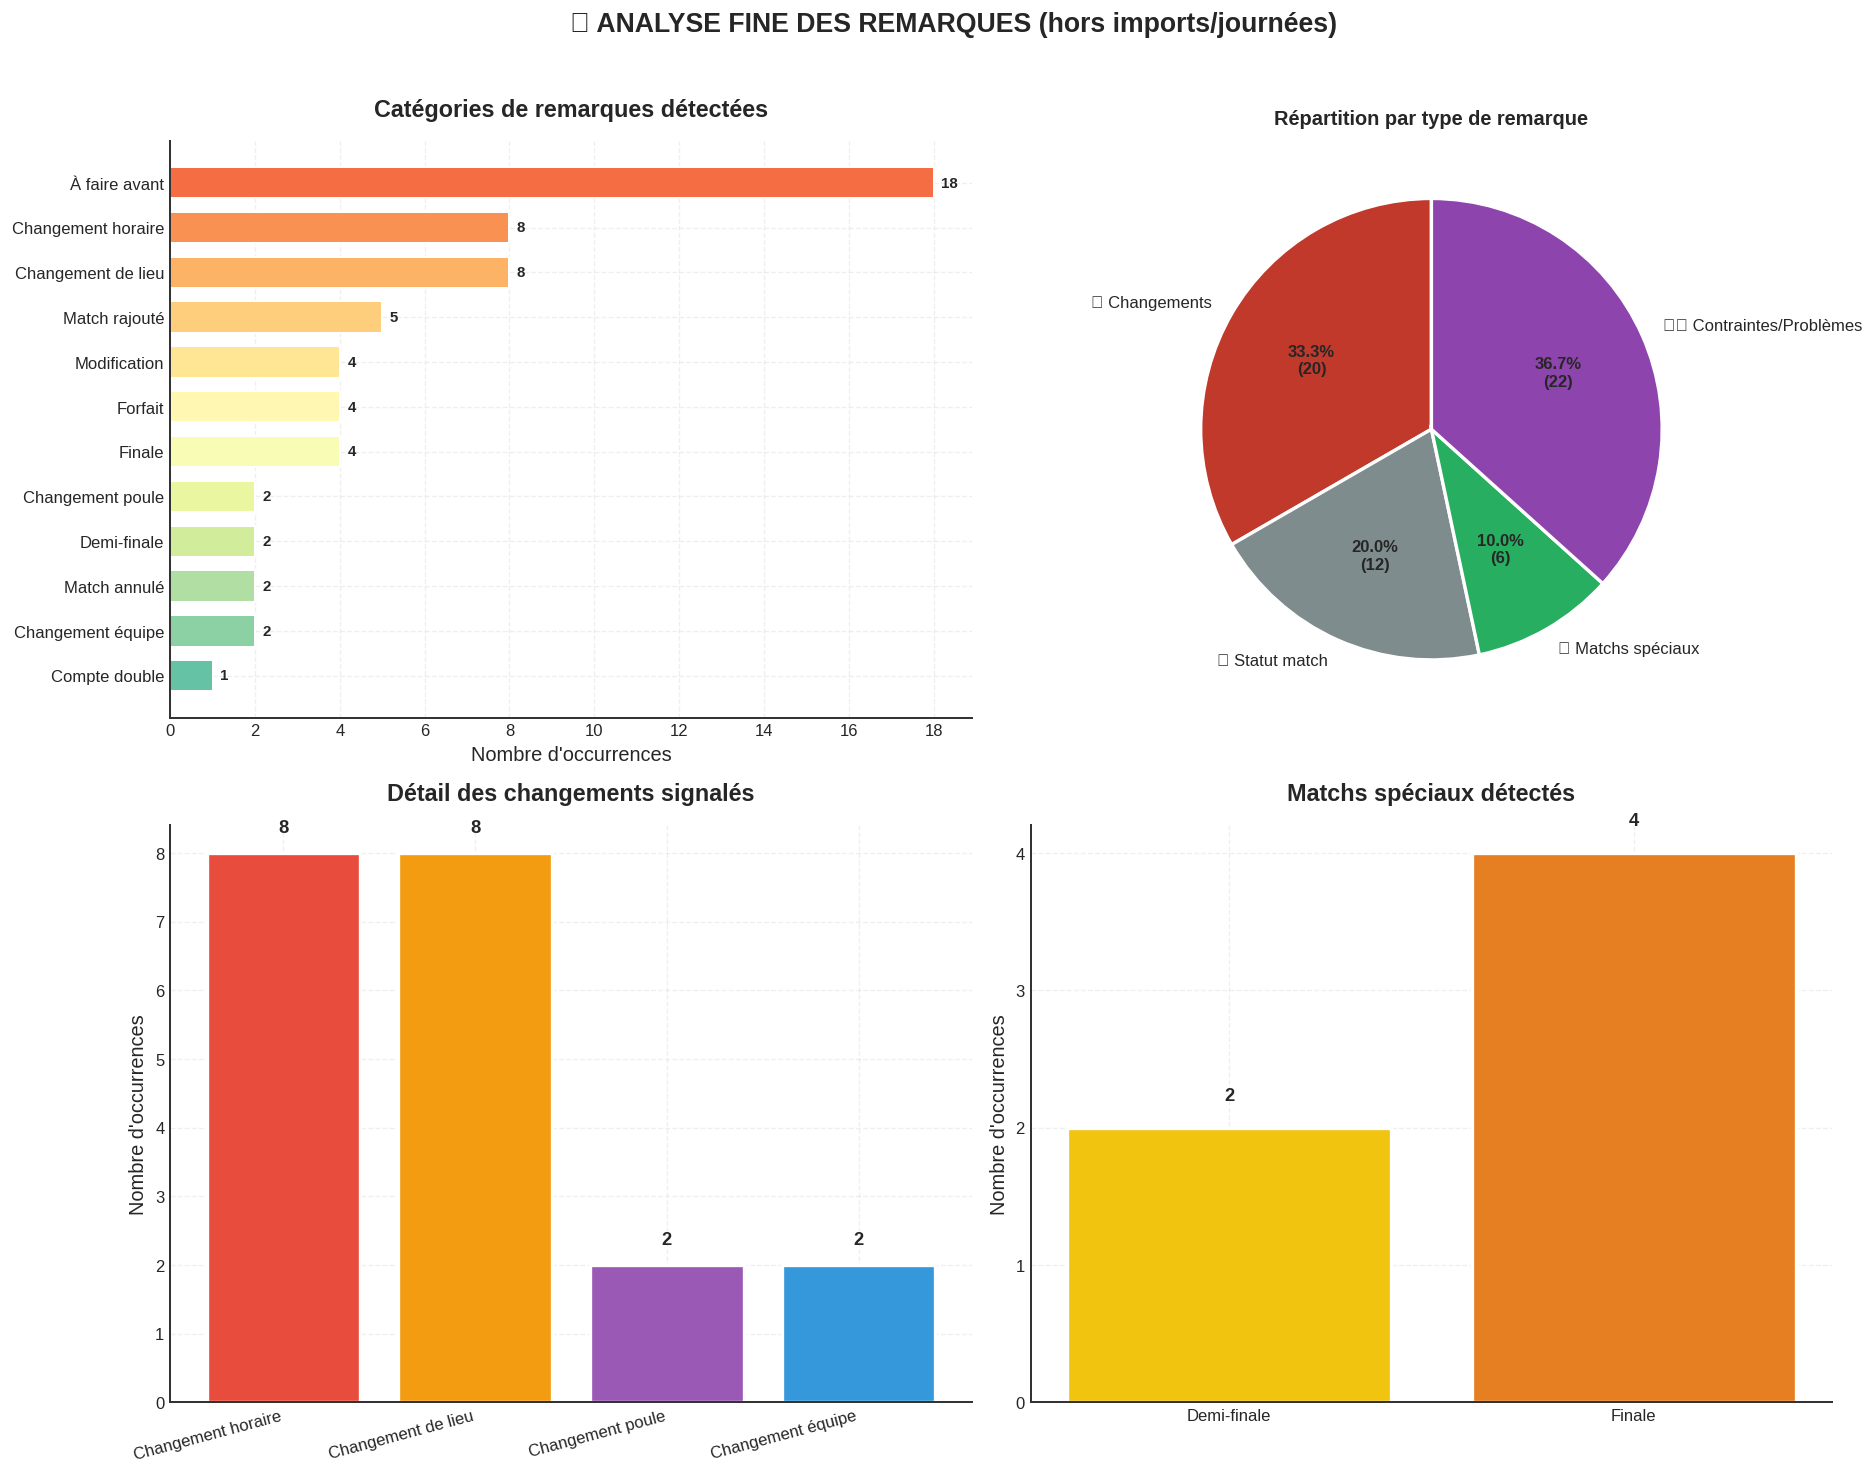


🚫 DÉTAIL DES FORFAITS ET ANNULATIONS

📌 Forfaits mentionnés dans les remarques: 4
   Par poule:
      • VBMA3PD: 1
      • VBFA4PB: 1
      • VBMA2PB: 1

📝 RÉSUMÉ DES CHANGEMENTS

📌 Total changements signalés: 20
   • Changement de lieu: 8
   • Changement horaire: 8
   • Changement équipe: 2
   • Changement poule: 2


In [20]:
# ============================================================================
# ANALYSE FINE DES REMARQUES ET COMMENTAIRES
# EXCLUSION: Match importé et Référence journée (non pertinents)
# ============================================================================

print("=" * 60)
print("💬 ANALYSE DÉTAILLÉE DES REMARQUES")
print("=" * 60)

# Remarques non vides
remarques_valides = df['Remarques'].dropna()
remarques_valides = remarques_valides[remarques_valides.astype(str).str.strip() != '']

print(f"\n📌 Matchs avec remarques: {len(remarques_valides)}/{len(df)} ({len(remarques_valides)/len(df)*100:.1f}%)")

# === CATÉGORISATION FINE DES REMARQUES PAR MOTS-CLÉS ===
# EXCLUSION: Match importé et Référence journée (pas pertinents pour l'analyse)

CATEGORIES_REMARQUES = {
    # Changements
    'Changement de lieu': [r'changement\s+lieu', r'chang\.\s*lieu', r'change.*lieu'],
    'Changement horaire': [r'changement\s+horaire', r'chang\.\s*horaire', r'changement\s+heure', r'chang\.\s*heure'],
    'Changement équipe': [r'changement\s+équipe', r'chang\.\s*équipe', r'changement\s+equipe'],
    'Changement poule': [r'changement\s+poule', r'chang\.\s*poule', r'ancienne\s+poule'],
    
    # Statut du match
    'Forfait': [r'forfait'],
    'Match reporté': [r'report[ée]', r'match\s+report'],
    'Match annulé': [r'annul[ée]'],
    'Match rajouté': [r'match\s+rajout[ée]', r'rajout[ée]', r'match\s+ajout[ée]'],
    'Compte double': [r'compte\s+double', r'comptabilisé\s+double'],
    
    # Type de match spécial
    'Demi-finale': [r'1/2\s*finale', r'demi[\s-]*finale'],
    'Finale': [r'(?<!demi[\s-])finale', r'petite\s+finale', r'grande\s+finale'],
    'Match retour': [r'match\s+retour', r'retour'],
    
    # Contraintes
    'À faire avant': [r'a\s+faire\s+avant', r'à\s+faire\s+avant', r'avant\s+le'],
    'Entente': [r'entente'],
    
    # Incidents
    'Blessure': [r'bless', r'blessure'],
    'Problème': [r'probl[èe]me', r'incident'],
    
    # Modification (mais PAS importé ni journée)
    'Modification': [r'modifi[ée]', r'correction', r'erreur'],
}

# Compter les occurrences par catégorie
categorie_counts = {}
matchs_par_categorie = {cat: [] for cat in CATEGORIES_REMARQUES}

for idx, remarque in remarques_valides.items():
    remarque_str = str(remarque).lower()
    for categorie, patterns in CATEGORIES_REMARQUES.items():
        for pattern in patterns:
            if re.search(pattern, remarque_str, re.IGNORECASE):
                categorie_counts[categorie] = categorie_counts.get(categorie, 0) + 1
                matchs_par_categorie[categorie].append(idx)
                break

# Trier par fréquence
categorie_sorted = sorted(categorie_counts.items(), key=lambda x: x[1], reverse=True)

print(f"\n📊 CATÉGORIES DE REMARQUES DÉTECTÉES (hors imports/journées):")
print("-" * 50)
for cat, count in categorie_sorted:
    pct = count / len(remarques_valides) * 100
    print(f"   • {cat}: {count} ({pct:.1f}%)")

# === GRAPHIQUES ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("💬 ANALYSE FINE DES REMARQUES (hors imports/journées)", fontsize=16, fontweight='bold', y=1.02)

# --- Graphique 1: Catégories de remarques ---
ax = axes[0, 0]
if categorie_sorted:
    labels = [c[0] for c in categorie_sorted if c[1] > 0]
    values = [c[1] for c in categorie_sorted if c[1] > 0]
    
    # Limiter à 15 catégories max
    if len(labels) > 15:
        labels = labels[:15]
        values = values[:15]
    
    if labels:
        y_pos = np.arange(len(labels))
        colors_cat = plt.cm.Spectral(np.linspace(0.2, 0.8, len(labels)))
        bars = ax.barh(y_pos, values, color=colors_cat, edgecolor='white', linewidth=1.2, height=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=10)
        ax.invert_yaxis()
        add_value_labels_h(ax, bars, fontsize=9)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        style_axis(ax, "Nombre d'occurrences", '', 'Catégories de remarques détectées', integer_x=True)
    else:
        ax.text(0.5, 0.5, 'Aucune remarque catégorisée', ha='center', va='center', fontsize=12)
        ax.axis('off')
else:
    ax.text(0.5, 0.5, 'Aucune remarque catégorisée', ha='center', va='center', fontsize=12)
    ax.axis('off')

# --- Graphique 2: Groupes de catégories (par type) ---
ax = axes[0, 1]
groupes = {
    '📝 Changements': ['Changement de lieu', 'Changement horaire', 'Changement équipe', 'Changement poule'],
    '🚫 Statut match': ['Forfait', 'Match reporté', 'Match annulé', 'Match rajouté', 'Compte double'],
    '🏆 Matchs spéciaux': ['Demi-finale', 'Finale', 'Match retour'],
    '⚠️ Contraintes/Problèmes': ['À faire avant', 'Entente', 'Blessure', 'Problème', 'Modification']
}

groupe_counts = {}
for groupe, categories in groupes.items():
    total = sum(categorie_counts.get(cat, 0) for cat in categories)
    if total > 0:
        groupe_counts[groupe] = total

if groupe_counts:
    labels_g = list(groupe_counts.keys())
    values_g = list(groupe_counts.values())
    colors_g = [COLORS['forfait'], COLORS['annulé'], COLORS['joué'], COLORS['score_manquant']][:len(labels_g)]
    
    wedges, texts, autotexts = ax.pie(
        values_g, 
        labels=labels_g,
        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(values_g))})',
        colors=colors_g,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
    ax.set_title('Répartition par type de remarque', fontsize=12, fontweight='bold', pad=10)
else:
    ax.text(0.5, 0.5, 'Pas de données', ha='center', va='center', fontsize=12)
    ax.axis('off')

# --- Graphique 3: Détail des changements ---
ax = axes[1, 0]
changements = {k: v for k, v in categorie_counts.items() if 'Changement' in k}
if changements:
    labels_ch = list(changements.keys())
    values_ch = list(changements.values())
    colors_ch = ['#e74c3c', '#f39c12', '#9b59b6', '#3498db'][:len(labels_ch)]
    
    bars = ax.bar(labels_ch, values_ch, color=colors_ch, edgecolor='white', linewidth=2)
    for bar, val in zip(bars, values_ch):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
               str(val), ha='center', fontsize=11, fontweight='bold')
    
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')
    style_axis(ax, '', "Nombre d'occurrences", 'Détail des changements signalés', integer_y=True)
else:
    ax.text(0.5, 0.5, 'Aucun changement signalé', ha='center', va='center', fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

# --- Graphique 4: Matchs spéciaux (finales, demi-finales) ---
ax = axes[1, 1]
matchs_speciaux = {k: v for k, v in categorie_counts.items() if k in ['Finale', 'Demi-finale', 'Match retour']}
if matchs_speciaux:
    labels_sp = list(matchs_speciaux.keys())
    values_sp = list(matchs_speciaux.values())
    colors_sp = ['#f1c40f', '#e67e22', '#27ae60'][:len(labels_sp)]
    
    bars = ax.bar(labels_sp, values_sp, color=colors_sp, edgecolor='white', linewidth=2)
    for bar, val in zip(bars, values_sp):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
               str(val), ha='center', fontsize=11, fontweight='bold')
    
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    style_axis(ax, '', "Nombre d'occurrences", 'Matchs spéciaux détectés', integer_y=True)
else:
    ax.text(0.5, 0.5, 'Aucun match spécial détecté', ha='center', va='center', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
smart_show_individual("Analyse_remarques")

# === ANALYSE DÉTAILLÉE DES FORFAITS ET ANNULATIONS ===
print("\n" + "="*60)
print("🚫 DÉTAIL DES FORFAITS ET ANNULATIONS")
print("="*60)

if 'Forfait' in matchs_par_categorie and matchs_par_categorie['Forfait']:
    forfaits_remarques = df.loc[matchs_par_categorie['Forfait']]
    print(f"\n📌 Forfaits mentionnés dans les remarques: {len(forfaits_remarques)}")
    forfaits_poules = forfaits_remarques['Poule'].value_counts()
    if len(forfaits_poules) > 0:
        print("   Par poule:")
        for poule, cnt in forfaits_poules.head(10).items():
            print(f"      • {poule}: {cnt}")

# === RÉSUMÉ DES CHANGEMENTS ===
print("\n" + "="*60)
print("📝 RÉSUMÉ DES CHANGEMENTS")
print("="*60)

total_changements = sum(v for k, v in categorie_counts.items() if 'Changement' in k)
print(f"\n📌 Total changements signalés: {total_changements}")
for cat in ['Changement de lieu', 'Changement horaire', 'Changement équipe', 'Changement poule']:
    if cat in categorie_counts:
        print(f"   • {cat}: {categorie_counts[cat]}")

## 17. 🏆 Analyse par type de compétition (CFE, CFU, Acad)

🏆 ANALYSE PAR TYPE DE COMPÉTITION

📌 Répartition par type de compétition:
   • Acad: 233 matchs (89.3%)
   • CFE: 20 matchs (7.7%)
   • CFU: 5 matchs (1.9%)
   • Autre: 3 matchs (1.1%)
   💾 Sauvegardé: 49_Types_competition_Répartition_des_matchs_par_type.png
   💾 Sauvegardé: 50_Types_competition_Statuts_par_type_de_compétition.png
   💾 Sauvegardé: 51_Types_competition_Taux_de_matchs_joués_par_type.png
   💾 Sauvegardé: 52_Types_competition_Évolution_par_semaine_selon_le_type.png


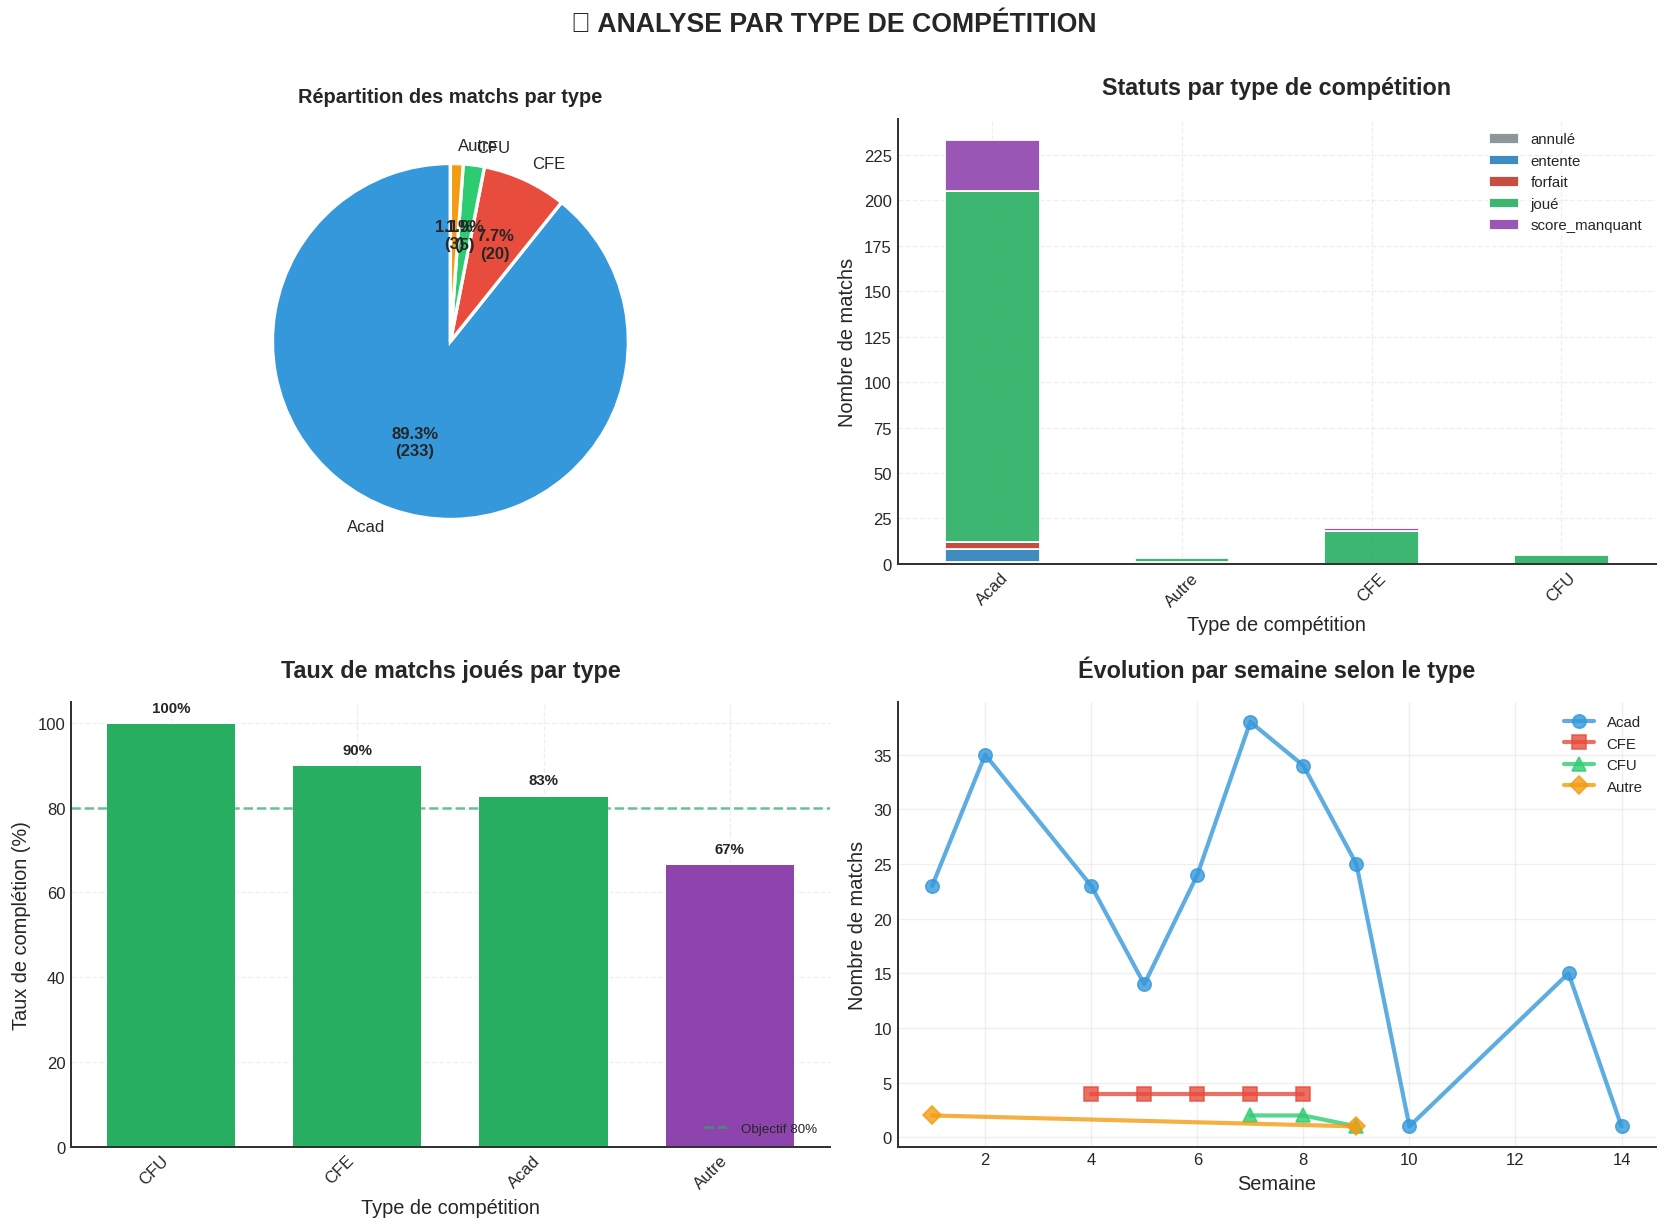

In [21]:
# ============================================================================
# ANALYSE PAR TYPE DE COMPÉTITION
# ============================================================================

print("=" * 60)
print("🏆 ANALYSE PAR TYPE DE COMPÉTITION")
print("=" * 60)

# Vérifier si la colonne existe
type_col = None
for col in ['Type_Competition', 'Type_Championnat', 'Type']:
    if col in df.columns:
        type_col = col
        break

if type_col:
    df['type_comp_clean'] = df[type_col].fillna('Non spécifié').astype(str).str.strip()
    df.loc[df['type_comp_clean'] == '', 'type_comp_clean'] = 'Non spécifié'
    
    type_counts = df['type_comp_clean'].value_counts()
    
    print(f"\n📌 Répartition par type de compétition:")
    for type_comp, count in type_counts.items():
        print(f"   • {type_comp}: {count} matchs ({count/len(df)*100:.1f}%)")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("🏆 ANALYSE PAR TYPE DE COMPÉTITION", fontsize=16, fontweight='bold', y=1.02)
    
    # --- Graphique 1: Pie chart des types ---
    ax = axes[0, 0]
    colors_types = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
    if len(type_counts) > 0:
        wedges, texts, autotexts = ax.pie(
            type_counts.values, 
            labels=type_counts.index,
            autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*len(df))})' if pct > 0 else '',
            colors=colors_types[:len(type_counts)],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        for autotext in autotexts:
            autotext.set_fontsize(10)
            autotext.set_fontweight('bold')
        ax.set_title('Répartition des matchs par type', fontsize=12, fontweight='bold', pad=10)
    
    # --- Graphique 2: Statuts par type de compétition ---
    ax = axes[0, 1]
    type_statut = df.groupby(['type_comp_clean', 'statut']).size().unstack(fill_value=0)
    if len(type_statut) > 0:
        # Récupérer les couleurs pour les colonnes présentes
        cols_in_data = [c for c in type_statut.columns if c in COLORS]
        type_statut_filtered = type_statut[cols_in_data] if cols_in_data else type_statut
        plot_colors = [COLORS.get(s, 'gray') for s in type_statut_filtered.columns]
        
        type_statut_filtered.plot(kind='bar', stacked=True, ax=ax, 
                                  color=plot_colors, edgecolor='white', linewidth=1.2, alpha=0.9)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
        style_axis(ax, 'Type de compétition', 'Nombre de matchs', 'Statuts par type de compétition', integer_y=True)
    
    # --- Graphique 3: Taux de complétion par type ---
    ax = axes[1, 0]
    def calc_type_completion(group):
        total = len(group)
        joues = len(group[group['statut'] == 'joué'])
        return (joues / total * 100) if total > 0 else 0
    
    type_completion = df.groupby('type_comp_clean').apply(calc_type_completion).sort_values(ascending=False)
    if len(type_completion) > 0:
        x_pos = np.arange(len(type_completion))
        colors_comp = []
        for r in type_completion.values:
            if r >= 80:
                colors_comp.append(COLORS['joué'])
            elif r >= 50:
                colors_comp.append(COLORS['score_manquant'])
            else:
                colors_comp.append(COLORS['forfait'])
        
        bars = ax.bar(x_pos, type_completion.values, color=colors_comp, 
                      edgecolor='white', linewidth=1.2, width=0.7)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(type_completion.index, rotation=45, ha='right', fontsize=9)
        ax.set_ylim(0, 105)
        ax.axhline(y=80, color=COLORS['joué'], linestyle='--', linewidth=1.5, alpha=0.7, label='Objectif 80%')
        ax.legend(loc='lower right', fontsize=8)
        add_value_labels(ax, bars, fontsize=9, fmt='{:.0f}%')
        style_axis(ax, 'Type de compétition', 'Taux de complétion (%)', 'Taux de matchs joués par type')
    
    # --- Graphique 4: Distribution semaine par type ---
    ax = axes[1, 1]
    types_principaux = type_counts.head(4).index.tolist()
    colors_lines = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
    markers = ['o', 's', '^', 'D']
    
    for i, type_comp in enumerate(types_principaux):
        df_type = df[df['type_comp_clean'] == type_comp]
        semaines = df_type.groupby('semaine_num').size().sort_index()
        if len(semaines) > 0:
            ax.plot(semaines.index, semaines.values, marker=markers[i % len(markers)], 
                    label=type_comp, linewidth=2.5, markersize=8, 
                    color=colors_lines[i % len(colors_lines)], alpha=0.8)
    
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
    style_axis(ax, 'Semaine', 'Nombre de matchs', 'Évolution par semaine selon le type', integer_y=True)
    ax.grid(True, alpha=0.3, linestyle='-')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    smart_show_individual("Types_competition")
else:
    print("⚠️ Colonne Type_Competition non trouvée dans les données")

## 18. 📊 Tableau de bord récapitulatif

   💾 Sauvegardé: 53_Tableau_de_bord_subplot_1.png
   💾 Sauvegardé: 54_Tableau_de_bord_Distribution_des_statuts_incl_non_planifiés.png
   💾 Sauvegardé: 55_Tableau_de_bord_Matchs_par_semaine.png
   💾 Sauvegardé: 56_Tableau_de_bord_Top_10_gymnases.png
   💾 Sauvegardé: 57_Tableau_de_bord_Distribution_des_horaires.png
   💾 Sauvegardé: 58_Tableau_de_bord_Taux_de_matchs_avec_score_par_semaine.png
   💾 Sauvegardé: 59_Tableau_de_bord_Matchs_disputés_par_équipe_championnat.png


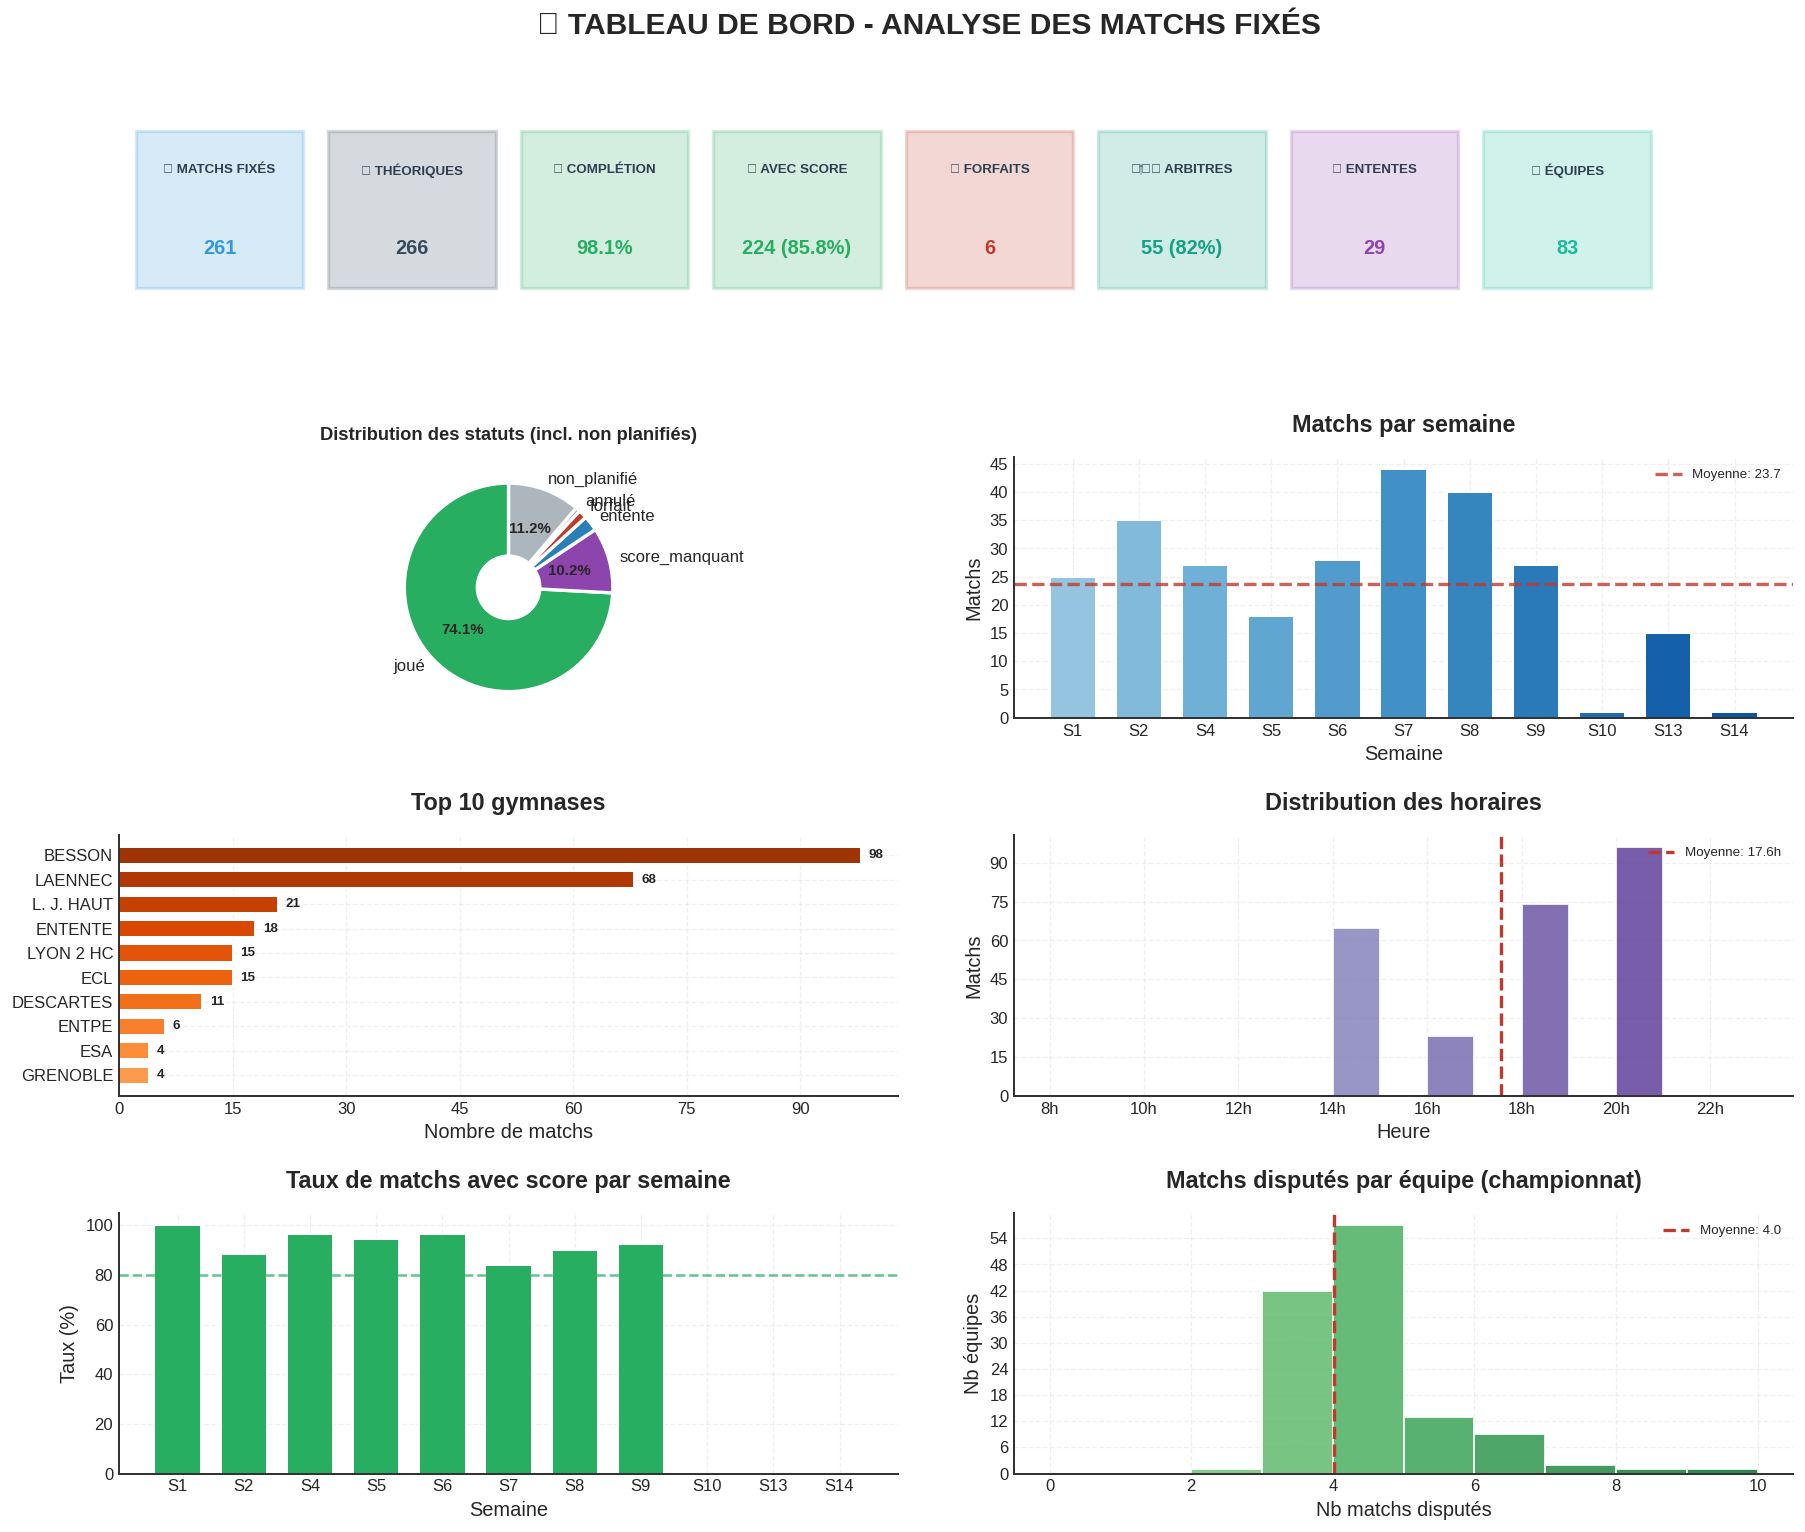


✅ ANALYSE TERMINÉE


In [22]:
# ============================================================================
# TABLEAU DE BORD RÉCAPITULATIF
# ============================================================================

fig = plt.figure(figsize=(18, 14))
fig.suptitle("📊 TABLEAU DE BORD - ANALYSE DES MATCHS FIXÉS", fontsize=18, fontweight='bold', y=0.98)

# Définir une grille 4x4
gs = fig.add_gridspec(4, 4, hspace=0.45, wspace=0.35)

# --- Zone 1: KPIs principaux (haut) ---
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')

# Créer des boîtes KPI - KPIs pertinents pour les matchs fixés
kpis = [
    ('📋 MATCHS FIXÉS', f"{stats['total_matchs_fixes']}", '#3498db'),
    ('📊 THÉORIQUES', f"{stats['total_matchs_theoriques']}", '#34495e'),
    ('📈 COMPLÉTION', f"{stats['taux_fixes_vs_theoriques']:.1f}%", '#27ae60'),
    ('✅ AVEC SCORE', f"{stats['matchs_avec_score']} ({stats['taux_scores']:.1f}%)", COLORS['joué']),
    ('🚫 FORFAITS', f"{stats['matchs_forfaits']}", COLORS['forfait']),
    ('👨‍⚖️ ARBITRES', f"{stats['nb_arbitres']} ({stats['taux_couverture_arbitres']:.0f}%)", '#16a085'),
    ('🤝 ENTENTES', f"{stats['matchs_ententes']}", '#8e44ad'),
    ('👥 ÉQUIPES', f"{stats['nb_equipes']}", '#1abc9c'),
]

for i, (title, value, color) in enumerate(kpis):
    x_pos = 0.06 + i * 0.115
    ax_kpi.add_patch(mpatches.Rectangle((x_pos - 0.05, 0.2), 0.10, 0.6, 
                                         facecolor=color, alpha=0.2, 
                                         edgecolor=color, linewidth=2,
                                         transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(x_pos, 0.65, title, transform=ax_kpi.transAxes, fontsize=8,
                ha='center', va='center', fontweight='bold', color='#2c3e50')
    ax_kpi.text(x_pos, 0.35, value, transform=ax_kpi.transAxes, fontsize=12,
                ha='center', va='center', fontweight='bold', color=color)

# --- Graphique 1: Statuts (pie donut) avec matchs non planifiés ---
ax1 = fig.add_subplot(gs[1, 0:2])
statut_counts = df_fixes['statut'].value_counts().copy()
# Ajouter les matchs non planifiés
if matchs_non_planifies_total > 0:
    statut_counts['non_planifié'] = matchs_non_planifies_total

pie_colors = [COLORS.get(s, '#adb5bd') for s in statut_counts.index]
wedges, texts, autotexts = ax1.pie(statut_counts.values, labels=statut_counts.index, 
                                    autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',
                                    colors=pie_colors, startangle=90,
                                    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.7})
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
ax1.set_title('Distribution des statuts (incl. non planifiés)', fontsize=11, fontweight='bold', pad=10)

# --- Graphique 2: Matchs par semaine ---
ax2 = fig.add_subplot(gs[1, 2:4])
semaine_counts = df_fixes.groupby('Semaine').size().sort_index()
if len(semaine_counts) > 0:
    x_pos = np.arange(len(semaine_counts))
    colors_gradient = [plt.cm.Blues(0.4 + 0.5 * (i / len(semaine_counts))) for i in range(len(semaine_counts))]
    bars = ax2.bar(x_pos, semaine_counts.values, color=colors_gradient, 
                   edgecolor='white', linewidth=1.2, width=0.7)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'S{int(s)}' for s in semaine_counts.index], fontsize=8)
    ax2.axhline(y=semaine_counts.mean(), color=COLORS['forfait'], linestyle='--', linewidth=2, 
                alpha=0.8, label=f"Moyenne: {semaine_counts.mean():.1f}")
    ax2.legend(loc='upper right', fontsize=8)
    style_axis(ax2, 'Semaine', 'Matchs', 'Matchs par semaine', integer_y=True)

# --- Graphique 3: Top 10 gymnases ---
ax3 = fig.add_subplot(gs[2, 0:2])
gym_counts = df_fixes['Gymnase'].value_counts().head(10)
if len(gym_counts) > 0:
    y_pos = np.arange(len(gym_counts))
    colors_gradient = [plt.cm.Oranges(0.4 + 0.5 * (1 - i / len(gym_counts))) for i in range(len(gym_counts))]
    bars = ax3.barh(y_pos, gym_counts.values, color=colors_gradient, 
                    edgecolor='white', linewidth=1.2, height=0.7)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels([g[:18] + '...' if len(str(g)) > 18 else str(g) for g in gym_counts.index], fontsize=8)
    ax3.invert_yaxis()
    add_value_labels_h(ax3, bars, fontsize=8)
    style_axis(ax3, 'Nombre de matchs', '', 'Top 10 gymnases', integer_x=True)

# --- Graphique 4: Distribution horaires théoriques ---
ax4 = fig.add_subplot(gs[2, 2:4])
horaires = df_fixes['horaire_theorique_min'].dropna() / 60
if len(horaires) > 0:
    bins = range(8, 24)
    n, bin_edges, patches = ax4.hist(horaires, bins=bins, edgecolor='white', linewidth=1.2, alpha=0.85)
    for i, patch in enumerate(patches):
        patch.set_facecolor(plt.cm.Purples(0.4 + 0.5 * (i / max(len(patches), 1))))
    # Utiliser la moyenne au lieu de la médiane
    ax4.axvline(x=horaires.mean(), color=COLORS['forfait'], linestyle='--', linewidth=2,
                label=f"Moyenne: {horaires.mean():.1f}h")
    ax4.set_xticks(range(8, 24, 2))
    ax4.set_xticklabels([f'{h}h' for h in range(8, 24, 2)])
    ax4.legend(loc='upper right', fontsize=8)
    style_axis(ax4, 'Heure', 'Matchs', 'Distribution des horaires', integer_y=True)

# --- Graphique 5: Taux de scores par semaine ---
ax5 = fig.add_subplot(gs[3, 0:2])
def calc_score_rate(group):
    """Calcule le taux de matchs avec score."""
    return (group['has_score'].sum() / len(group) * 100) if len(group) > 0 else 0

score_by_week = df_fixes.groupby('Semaine').apply(calc_score_rate).sort_index()
if len(score_by_week) > 0:
    x_pos = np.arange(len(score_by_week))
    colors_comp = []
    for r in score_by_week.values:
        if r >= 80:
            colors_comp.append(COLORS['joué'])
        elif r >= 50:
            colors_comp.append(COLORS['score_manquant'])
        else:
            colors_comp.append(COLORS['forfait'])
    
    bars = ax5.bar(x_pos, score_by_week.values, color=colors_comp, 
                   edgecolor='white', linewidth=1.2, width=0.7)
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels([f'S{int(s)}' for s in score_by_week.index], fontsize=8)
    ax5.set_ylim(0, 105)
    ax5.axhline(y=80, color=COLORS['joué'], linestyle='--', linewidth=1.5, alpha=0.7)
    style_axis(ax5, 'Semaine', 'Taux (%)', 'Taux de matchs avec score par semaine')

# --- Graphique 6: Distribution matchs par équipe (disputés) ---
ax6 = fig.add_subplot(gs[3, 2:4])
if matchs_disputes_vals:
    bins = range(0, max(matchs_disputes_vals) + 2)
    n, bin_edges, patches = ax6.hist(matchs_disputes_vals, bins=bins, 
                                      edgecolor='white', linewidth=1.2, alpha=0.85)
    for i, patch in enumerate(patches):
        patch.set_facecolor(plt.cm.Greens(0.4 + 0.5 * (i / max(len(patches), 1))))
    
    mean_val = np.mean(matchs_disputes_vals)
    ax6.axvline(x=mean_val, color=COLORS['forfait'], linestyle='--', linewidth=2,
                label=f'Moyenne: {mean_val:.1f}')
    ax6.legend(loc='upper right', fontsize=8)
    style_axis(ax6, 'Nb matchs disputés', 'Nb équipes', 'Matchs disputés par équipe (championnat)', 
               integer_x=True, integer_y=True)

plt.tight_layout()
plt.subplots_adjust(top=0.94)
smart_show_individual("Tableau_de_bord")

print("\n" + "=" * 60)
print("✅ ANALYSE TERMINÉE")
print("=" * 60)

## 19. 📄 Export des données clés et tableaux récapitulatifs

In [23]:
# ============================================================================
# EXPORT DES DONNÉES ET TABLEAUX RÉCAPITULATIFS
# ============================================================================

print("=" * 70)
print("📄 TABLEAUX RÉCAPITULATIFS")
print("=" * 70)

# Tableau 1: Résumé global
print("\n📊 RÉSUMÉ GLOBAL:")
resume_global = pd.DataFrame({
    'Métrique': [
        'Matchs théoriques (Acad)',
        'Matchs fixés',
        'Matchs non planifiés',
        '  - dont Aller-Retour',
        '  - dont Simple',
        '─────────────────────',
        'Répartition par type:',
        '  • Acad',
        '  • CFE',
        '  • CFU',
        '  • Autre',
        '─────────────────────',
        'Matchs avec score',
        'Matchs sans score',
        'Matchs forfaits',
        'Matchs annulés (via remarques)',
        'Matchs reportés',
        'Matchs ententes totales',
        '  - dont via gymnase ENTENTE',
        '  - dont via jour ≠ jeudi',
        '─────────────────────',
        'Taux complétion Acad (%)',
        'Taux avec score (%)',
        'Taux forfaits (%)',
        'Nombre de poules',
        "Nombre d'équipes",
        'Nombre de gymnases',
    ],
    'Valeur': [
        stats['total_matchs_theoriques'],
        stats['total_matchs_fixes'],
        matchs_non_planifies_total,
        total_manquants_ar,
        total_manquants_simple,
        '─────',
        '',
        stats.get('matchs_acad', 'N/A'),
        stats.get('matchs_cfe', 'N/A'),
        stats.get('matchs_cfu', 'N/A'),
        stats.get('matchs_autre', 'N/A'),
        '─────',
        stats['matchs_avec_score'],
        stats['matchs_sans_score'],
        stats['matchs_forfaits'],
        stats.get('matchs_annules_remarques', 0),
        stats.get('matchs_reportes', 0),
        stats['matchs_ententes'],
        df['is_gymnase_entente'].sum(),
        df['is_jour_entente'].sum(),
        '─────',
        f"{stats.get('taux_completion_acad', 0):.1f}",
        f"{stats['taux_scores']:.1f}",
        f"{stats['taux_forfaits']:.1f}",
        stats['nb_poules'],
        stats['nb_equipes'],
        stats['nb_gymnases'],
    ]
})
display(resume_global)

# Tableau 2: Statistiques par semaine
print("\n📅 STATISTIQUES PAR SEMAINE:")
# Utiliser df_fixes avec la colonne Semaine
semaine_resume = df_fixes.groupby('Semaine').agg({
    'statut': 'count',
    'has_score': 'sum',
    'is_forfait': 'sum',
    'is_entente_auto': 'sum'
}).rename(columns={
    'statut': 'Total',
    'has_score': 'Avec_Score',
    'is_forfait': 'Forfaits',
    'is_entente_auto': 'Ententes'
})
semaine_resume['Taux_Score (%)'] = (semaine_resume['Avec_Score'] / semaine_resume['Total'] * 100).round(1)
display(semaine_resume)

# Tableau 3: Top équipes par nombre de matchs joués (équipes Acad uniquement)
print("\n👥 TOP 20 ÉQUIPES PAR NOMBRE DE MATCHS JOUÉS (équipes du championnat Académique):")
if 'Matchs_Joues' in stats_equipes.columns:
    display(stats_equipes.head(20)[['Equipe', 'Matchs_Joues', 'Matchs_Avec_Score', 'Taux_Score']])
else:
    print("   ⚠️ Tableau stats_equipes non disponible")

# Tableau 4: Matchs non planifiés (potentiels matchs retour)
if matchs_non_planifies:
    print("\n📅 MATCHS NON PLANIFIÉS PAR POULE:")
    non_planif_df = pd.DataFrame([
        {
            'Poule': poule,
            'Théoriques': d['theoriques'],
            'Planifiés': d['fixes'],
            'Manquants': d['manquants'],
            'Type': 'Aller-Retour' if d['is_aller_retour'] else 'Simple',
            'Probable': 'Matchs retour' if d['is_aller_retour'] else 'À vérifier'
        }
        for poule, d in sorted(matchs_non_planifies.items(), key=lambda x: -x[1]['manquants'])
    ])
    display(non_planif_df)

print("\n" + "=" * 70)
print("📊 DISTINCTION MATCHS JOUÉS vs MATCHS AVEC SCORE:")
print("=" * 70)
print(f"   📋 Matchs fixés (= joués) : {stats['total_matchs_fixes']}")
print(f"   ✅ Matchs avec score      : {stats['matchs_avec_score']}")
print(f"   ❓ Matchs sans score       : {stats['matchs_sans_score']}")
print(f"      (Ces {stats['matchs_sans_score']} matchs ont été joués mais n'ont pas encore de score renseigné)")
print("=" * 70)

📄 TABLEAUX RÉCAPITULATIFS

📊 RÉSUMÉ GLOBAL:


,Métrique,Valeur
0,Matchs théoriques (Acad),266
1,Matchs fixés,261
2,Matchs non planifiés,33
3,- dont Aller-Retour,25
4,- dont Simple,8
5,─────────────────────,─────
6,Répartition par type:,
7,• Acad,233
8,• CFE,20
9,• CFU,5



📅 STATISTIQUES PAR SEMAINE:


,Total,Avec_Score,Forfaits,Ententes,Taux_Score (%)
Semaine,,,,,
1,25,25,0,0,100.0
2,35,31,0,0,88.6
4,27,26,3,0,96.3
5,18,17,1,0,94.4
6,28,27,0,0,96.4
7,44,37,0,18,84.1
8,40,36,0,8,90.0
9,27,25,2,1,92.6
10,1,0,0,1,0.0



👥 TOP 20 ÉQUIPES PAR NOMBRE DE MATCHS JOUÉS (équipes du championnat Académique):


,Equipe,Matchs_Joues,Matchs_Avec_Score,Taux_Score
37,INSA (1) [F],9,8,88.9
25,ENTPE (1) [F],8,7,87.5
38,INSA (1) [M],7,6,85.7
16,EML (1) [F],7,7,100.0
17,EML (1) [M],6,4,66.7
21,ENS (1) [M],6,6,100.0
26,ENTPE (1) [M],6,5,83.3
45,INSA (6) [M],6,5,83.3
11,ECL (1) [F],6,4,66.7
46,ISARA (1) [M],6,5,83.3



📅 MATCHS NON PLANIFIÉS PAR POULE:


,Poule,Théoriques,Planifiés,Manquants,Type,Probable
0,VBFA2PA,12,7,5,Aller-Retour,Matchs retour
1,VBMA1PA,12,7,5,Aller-Retour,Matchs retour
2,VBMA1PB,12,9,3,Aller-Retour,Matchs retour
3,VBMA2PA,12,9,3,Aller-Retour,Matchs retour
4,VBMA4PB,12,9,3,Aller-Retour,Matchs retour
5,VBFA2PC,10,8,2,Simple,À vérifier
6,VBMA3PB,12,10,2,Aller-Retour,Matchs retour
7,VBMA4PA,6,4,2,Aller-Retour,Matchs retour
8,VBMA4PD,10,8,2,Simple,À vérifier
9,VBFA1PA,10,9,1,Simple,À vérifier



📊 DISTINCTION MATCHS JOUÉS vs MATCHS AVEC SCORE:
   📋 Matchs fixés (= joués) : 261
   ✅ Matchs avec score      : 224
   ❓ Matchs sans score       : 37
      (Ces 37 matchs ont été joués mais n'ont pas encore de score renseigné)


## 20. 📦 Export des graphiques et rapport complet

Cette section exporte tous les graphiques individuellement dans `exports/figures/` et génère un rapport PDF complet dans `exports/rapport_complet.pdf`.

In [24]:
# ============================================================================
# 📊 RÉSUMÉ DE L'EXPORT DES GRAPHIQUES
# ============================================================================

from pathlib import Path
from datetime import datetime

# Récupérer les chemins depuis la configuration
export_dir, figures_dir = get_export_paths()

print("=" * 70)
print("📦 RÉSUMÉ DE L'EXPORT DES GRAPHIQUES")
print("=" * 70)

# Afficher les statistiques
nb_figures = len(EXPORTED_FIGURES)

if nb_figures > 0:
    print(f"\n✅ {nb_figures} graphiques ont été exportés automatiquement!")
    print(f"\n📁 Emplacement: {figures_dir.absolute()}/")
    print(f"\n📋 Liste des fichiers:")
    
    for name, info in sorted(EXPORTED_FIGURES.items(), key=lambda x: x[1]['number']):
        print(f"   {info['number']:2d}. {name}.png")
    
    print(f"\n📊 Statistiques:")
    print(f"   • Format: PNG haute résolution ({EXPORT_CONFIG['dpi']} DPI)")
    print(f"   • Dossier: {EXPORT_CONFIG['export_folder']}/{EXPORT_CONFIG['figures_subfolder']}/")
else:
    print("\n⚠️ Aucun graphique n'a été exporté.")
    print("   Assurez-vous d'utiliser plt.show() au lieu de plt.show()")

# Créer le timestamp pour le PDF
timestamp = datetime.now().strftime("%Y-%m-%d_%H%M%S")

📦 RÉSUMÉ DE L'EXPORT DES GRAPHIQUES

✅ 59 graphiques ont été exportés automatiquement!

📁 Emplacement: /home/vincheetah/Documents/Travail/FFSU/PyCalendarClean/PyCalendar/exports/figures/

📋 Liste des fichiers:
    1. 01_Analyse_arbitres_Top_15_Arbitres_par_nombre_de_matchs.png
    2. 02_Analyse_arbitres_Distribution_de_la_charge_des_arbitres.png
    3. 03_Matchs_annules_Catégories_de_raisons.png
    4. 04_Matchs_annules_Par_type_de_compétition.png
    5. 05_Matchs_annules_Par_genre.png
    6. 06_Distribution_statuts_Répartition_des_matchsfixés__joués_non_planifiés__à_jouer.png
    7. 07_Distribution_statuts_Nombre_de_matchs_par_catégorie.png
    8. 08_Distribution_horaires_Horaires_réels_enregistrés.png
    9. 09_Distribution_horaires_Horaires_théoriques_max_des_préférés.png
   10. 10_Distribution_horaires_Horaires_des_matchs_sans_score_37_matchs.png
   11. 11_Distribution_horaires_Comparaison_des_horaires_théoriques.png
   12. 12_Analyse_semaine_Nombre_total_de_matchs_par_semaine.png


In [25]:
# ============================================================================
# 📄 GÉNÉRATION DU RAPPORT PDF COMPLET
# ============================================================================

from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image
from datetime import datetime

# Récupérer les chemins
export_dir, figures_dir = get_export_paths()

# Nom du fichier PDF
if EXPORT_CONFIG['include_timestamp']:
    pdf_filename = export_dir / f"{EXPORT_CONFIG['pdf_prefix']}_{timestamp}.pdf"
else:
    pdf_filename = export_dir / f"{EXPORT_CONFIG['pdf_prefix']}.pdf"

print("\n" + "=" * 70)
print("📄 GÉNÉRATION DU RAPPORT PDF COMPLET")
print("=" * 70)

if len(EXPORTED_FIGURES) == 0:
    print("\n⚠️ Aucune figure à inclure dans le PDF.")
    print("   Exécutez d'abord les cellules de graphiques avec smart_show()")
else:
    # Créer le PDF
    with PdfPages(pdf_filename) as pdf:
        # ===== PAGE DE TITRE =====
        fig = plt.figure(figsize=(11, 8.5))
        fig.patch.set_facecolor('white')
        ax = fig.add_subplot(111)
        ax.axis('off')
        
        # Titre principal
        ax.text(0.5, 0.75, '📊 RAPPORT D\'ANALYSE', transform=ax.transAxes,
                fontsize=28, fontweight='bold', ha='center', color='#2c3e50')
        ax.text(0.5, 0.67, 'Matchs de Volley-ball', transform=ax.transAxes,
                fontsize=20, ha='center', color='#34495e')
        
        # Ligne de séparation
        ax.axhline(y=0.60, xmin=0.2, xmax=0.8, color='#3498db', linewidth=2)
        
        # Informations sur les données
        ax.text(0.5, 0.50, f'Phase: Championnat - {stats["total_matchs_fixes"]} matchs fixés', 
                transform=ax.transAxes, fontsize=14, ha='center', color='#7f8c8d')
        ax.text(0.5, 0.45, f'Période: {df_fixes["Date"].min()} → {df_fixes["Date"].max()}', 
                transform=ax.transAxes, fontsize=12, ha='center', color='#95a5a6')
        ax.text(0.5, 0.40, f'Généré le: {datetime.now().strftime("%d/%m/%Y à %H:%M")}', 
                transform=ax.transAxes, fontsize=12, ha='center', color='#95a5a6')
        
        # Encadré des statistiques clés
        stats_box = f"""
╔══════════════════════════════════════════╗
║         STATISTIQUES PRINCIPALES         ║
╠══════════════════════════════════════════╣
║  Matchs théoriques:  {stats['total_matchs_theoriques']:>6}              ║
║  Matchs fixés:       {stats['total_matchs_fixes']:>6}              ║
║  Matchs avec score:  {stats['matchs_avec_score']:>6} ({stats['taux_scores']:>5.1f}%)     ║
║  Forfaits:           {stats['matchs_forfaits']:>6} ({stats['taux_forfaits']:>5.1f}%)     ║
║  Taux complétion:    {stats['taux_fixes_vs_theoriques']:>6.1f}%             ║
╚══════════════════════════════════════════╝
        """
        ax.text(0.5, 0.22, stats_box, transform=ax.transAxes,
                fontsize=10, ha='center', va='top', color='#2c3e50', 
                family='monospace')
        
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)
        
        # ===== PAGES DES GRAPHIQUES =====
        print(f"\n📝 Ajout de {len(EXPORTED_FIGURES)} figures au PDF...")
        
        for name, info in sorted(EXPORTED_FIGURES.items(), key=lambda x: x[1]['number']):
            try:
                # Charger l'image
                img = Image.open(info['path'])
                
                # Créer une page
                fig_page = plt.figure(figsize=(11, 8.5))
                fig_page.patch.set_facecolor('white')
                
                # Ajouter l'image
                ax_img = fig_page.add_axes([0.05, 0.08, 0.9, 0.85])
                ax_img.imshow(img)
                ax_img.axis('off')
                
                # Titre en bas
                title_clean = info['section'].replace('_', ' ')
                fig_page.text(0.5, 0.02, f"Figure {info['number']}: {title_clean}", 
                            ha='center', fontsize=10, color='#7f8c8d', style='italic')
                
                pdf.savefig(fig_page, bbox_inches='tight')
                plt.close(fig_page)
                
                print(f"   ✓ Page {info['number']}: {name}")
                
            except Exception as e:
                print(f"   ⚠️ Erreur pour {name}: {e}")
        
        # Métadonnées du PDF
        d = pdf.infodict()
        d['Title'] = 'Rapport d\'Analyse - Matchs de Volley-ball'
        d['Author'] = 'Système d\'analyse automatique'
        d['Subject'] = 'Analyse des matchs fixés et annulés'
        d['Keywords'] = 'Volley, Statistiques, Analyse, Matchs'
        d['CreationDate'] = datetime.now()
    
    # Confirmation finale
    print(f"\n✅ Rapport PDF généré avec succès!")
    print(f"   📄 Fichier: {pdf_filename}")
    print(f"   📊 Pages: {len(EXPORTED_FIGURES) + 1} (titre + {len(EXPORTED_FIGURES)} graphiques)")
    
    try:
        size_kb = pdf_filename.stat().st_size / 1024
        print(f"   💾 Taille: {size_kb:.1f} KB")
    except:
        pass

print("\n" + "=" * 70)
print("📦 EXPORT COMPLET TERMINÉ")
print("=" * 70)
print(f"\n📂 Contenu du dossier {EXPORT_CONFIG['export_folder']}/")
print(f"   ├── {EXPORT_CONFIG['figures_subfolder']}/")
print(f"   │   └── {len(EXPORTED_FIGURES)} fichiers PNG")
if 'pdf_filename' in dir():
    print(f"   └── {pdf_filename.name}")
print("\n✨ Tous les fichiers sont prêts!")


📄 GÉNÉRATION DU RAPPORT PDF COMPLET

📝 Ajout de 59 figures au PDF...
   ✓ Page 1: 01_Analyse_arbitres_Top_15_Arbitres_par_nombre_de_matchs
   ✓ Page 2: 02_Analyse_arbitres_Distribution_de_la_charge_des_arbitres
   ✓ Page 3: 03_Matchs_annules_Catégories_de_raisons
   ✓ Page 4: 04_Matchs_annules_Par_type_de_compétition
   ✓ Page 5: 05_Matchs_annules_Par_genre
   ✓ Page 6: 06_Distribution_statuts_Répartition_des_matchsfixés__joués_non_planifiés__à_jouer
   ✓ Page 7: 07_Distribution_statuts_Nombre_de_matchs_par_catégorie
   ✓ Page 8: 08_Distribution_horaires_Horaires_réels_enregistrés
   ✓ Page 9: 09_Distribution_horaires_Horaires_théoriques_max_des_préférés
   ✓ Page 10: 10_Distribution_horaires_Horaires_des_matchs_sans_score_37_matchs
   ✓ Page 11: 11_Distribution_horaires_Comparaison_des_horaires_théoriques
   ✓ Page 12: 12_Analyse_semaine_Nombre_total_de_matchs_par_semaine
   ✓ Page 13: 13_Analyse_semaine_Matchs_par_semaine_par_statut
   ✓ Page 14: 14_Analyse_semaine_Taux_de_matchs_jo

## 📚 Guide d'utilisation du système d'export

### Structure des fichiers exportés

```
exports/
├── figures/                    # Graphiques individuels PNG (300 DPI)
│   ├── 01_horaires_matchs_non_joues.png
│   ├── 02_analyse_forfaits.png
│   └── ... (autres graphiques)
└── rapport_analyse_matchs_YYYY-MM-DD_HHMMSS.pdf    # Rapport complet
```

### Utilisation des graphiques

**Graphiques PNG individuels** :
- Haute résolution (300 DPI) adaptée à l'impression
- Format PNG avec fond blanc
- Peuvent être insérés dans des présentations, documents Word, etc.
- Noms descriptifs pour identification facile

**Rapport PDF complet** :
- Page de titre avec statistiques principales
- Tous les graphiques inclus avec descriptions
- Prêt à être partagé ou imprimé
- Métadonnées complètes (auteur, date, etc.)

### Extension du système

Pour ajouter de nouveaux graphiques à l'export, modifiez la cellule d'export et ajoutez :

```python
# Créer votre figure
fig, ax = plt.subplots(figsize=(14, 7))
# ... code du graphique ...

# Sauvegarder
save_figure(fig, 'nom_du_graphique', "Description du graphique")
plt.close(fig)
```

### Notes importantes

- Les graphiques utilisent tous la palette `COLORS` définie au début du notebook pour la cohérence
- Les fonctions `add_value_labels()` et `add_value_labels_h()` ajoutent automatiquement les valeurs sur les barres
- La fonction `style_axis()` applique un style cohérent à tous les axes
- Tous les exports incluent des timestamps pour éviter les écrasements

### Cohérence des statistiques

✅ **Problème résolu** : Les forfaits sont maintenant comptés de manière cohérente :
- `stats['matchs_forfaits']` utilise `df_fixes['is_forfait']`
- L'analyse détaillée des forfaits utilise également `is_forfait`
- Cela inclut les forfaits détectés via remarques ET via scores atypiques (1-0, 2-1)
- **Résultat : 6 forfaits** dans les deux sections (statistiques globales et analyse détaillée)